# Credit Card Customer Segmentation

##Context

AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the Marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers. Another insight from the market research was that the customers perceive the support services of the back poorly. Based on this, the Operations team wants to upgrade the service delivery model, to ensure that customer queries are resolved faster. The Head of Marketing and Head of Delivery both decide to reach out to the Data Science team for help

##Objective
To identify different segments in the existing customers, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.

##Data Description
The data provided is of various customers of a bank and their financial attributes like credit limit, the total number of credit cards the customer has, and different channels through which customers have contacted the bank for any queries (including visiting the bank, online, and through a call center).

##Data Dictionary
* Sl_No: Primary key of the records
* Customer Key: Customer identification number
* Average Credit Limit: Average credit limit of each customer for all credit cards
* Total credit cards: Total number of credit cards possessed by the customer
* Total visits bank: Total number of visits that the customer made (yearly) personally to the bank
* Total visits online: Total number of visits or online logins made by the customer (yearly)
* Total calls made: Total number of calls made by the customer to the bank or its customer service department (yearly)


# Imports and important libararies

In [21]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
)

# Dataset loading

In [22]:
from google.colab import drive
drive.mount(  '/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Overview of the Dataset

In [23]:
import os

file_name = 'Credit Card Customer Data.xlsx'
file_path = None

for root, dirs, files in os.walk('/content/drive'):
    if file_name in files:
        file_path = os.path.join(root, file_name)
        break

if file_path:
    print(f"Found the file at: {file_path}")
    # Attempt to load the data with the found path
    try:
        data = pd.read_excel(file_path)
        print("Dataset loaded successfully!")
        display(data.head())
    except Exception as e:
        print(f"Error loading dataset even after finding path: {e}")
else:
    print(f"Could not find '{file_name}' in Google Drive. Please ensure the file is in your Google Drive and the drive is mounted correctly.")

Found the file at: /content/drive/MyDrive/Credit Card Customer Data.xlsx
Dataset loaded successfully!


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [24]:
display(data.tail())

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


In [25]:
# Shape of the dataset
data.shape

(660, 7)

* This suggests that the dataset has 660 rows and 7 columns

In [26]:
# Data Types of the elements in this Data set
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


* We do not have any objects in the Dataset

In [27]:
# Missing values in the dataset
data.isnull().sum()

,0
Sl_No,0
Customer Key,0
Avg_Credit_Limit,0
Total_Credit_Cards,0
Total_visits_bank,0
Total_visits_online,0
Total_calls_made,0


* There are no missing values in the dataset

In [28]:
# Duplicate values in the dataset and treating them
data.duplicated().sum()

np.int64(0)

# Statistical Summary of the Dataset

In [29]:
display(data.describe().T)

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.00000,330.50000,190.66987,1.00000,165.75000,330.50000,495.25000,660.00000
Customer Key,660.00000,55141.44394,25627.77220,11265.00000,33825.25000,53874.50000,77202.50000,99843.00000
Avg_Credit_Limit,660.00000,34574.24242,37625.48780,3000.00000,10000.00000,18000.00000,48000.00000,200000.00000
Total_Credit_Cards,660.00000,4.70606,2.16783,1.00000,3.00000,5.00000,6.00000,10.00000
Total_visits_bank,660.00000,2.40303,1.63181,0.00000,1.00000,2.00000,4.00000,5.00000
Total_visits_online,660.00000,2.60606,2.93572,0.00000,1.00000,2.00000,4.00000,15.00000
Total_calls_made,660.00000,3.58333,2.86532,0.00000,1.00000,3.00000,5.00000,10.00000


## Summary

Based on the statistical summary, here's an overview of the dataset:

* Sl_No and Customer Key: These are unique identifiers, with 660 entries each, confirming no missing values.
* Average Credit Limit: The average credit limit is around 34,574, but there's a wide range, from a minimum of 3,000 to a maximum of 200,000. This indicates significant variation in credit limits among customers.
* Total Credit Cards: On average, customers have about 4 to 5 credit cards, with the number ranging from 1 to 10.
* Total visits bank: Customers visit the bank approximately 3 times a year, with a range from 0 to 5 visits.
* Total visits online: The average number of online visits is around 3 to 4 times a year, with some customers visiting up to 12 times.
* Total calls made: Customers make an average of 3 to 4 calls to the bank annually, with a maximum of 10 calls.

# Task for the EDA
Perform a comprehensive Exploratory Data Analysis (EDA) on the 'Credit Card Customer Data.xlsx' dataset. Begin by dropping the 'Sl_No' and 'Customer Key' columns. Then, conduct univariate analysis on 'Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', and 'Total_calls_made' using histograms and box plots. Follow this with bivariate analysis, including a correlation matrix heatmap and scatter plots for significant variable pairs. Finally, summarize all key observations and insights gained from both univariate and bivariate analyses, highlighting findings relevant for customer segmentation.

### Drop Identifier Columns

### Subtask:
Drop the 'Sl_No' and 'Customer Key' columns as they are unique identifiers and not relevant for clustering or pattern analysis.


**Reasoning**:
Drop the 'Sl_No' and 'Customer Key' columns from the DataFrame as they are identifiers and not useful for analysis, then display the first few rows to verify the changes.



In [30]:
data = data.drop(columns=['Sl_No', 'Customer Key'], axis=1)
display(data.head())

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,100000,2,1,1,0
1,50000,3,0,10,9
2,50000,7,1,3,4
3,30000,5,1,1,4
4,100000,6,0,12,3


## Univariate Analysis

Performing univariate analysis on the remaining numerical features: 'Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', and 'Total_calls_made'. This will involve generating histograms and box plots to visualize the distribution, spread, and identify potential outliers for each variable. Provide clear titles and labels for all plots, along with legends if necessary.


**Reasoning**:
To perform univariate analysis, I will iterate through the specified numerical columns and generate a histogram with KDE and a box plot for each. This will allow for visualization of distribution, spread, and potential outliers for each feature.



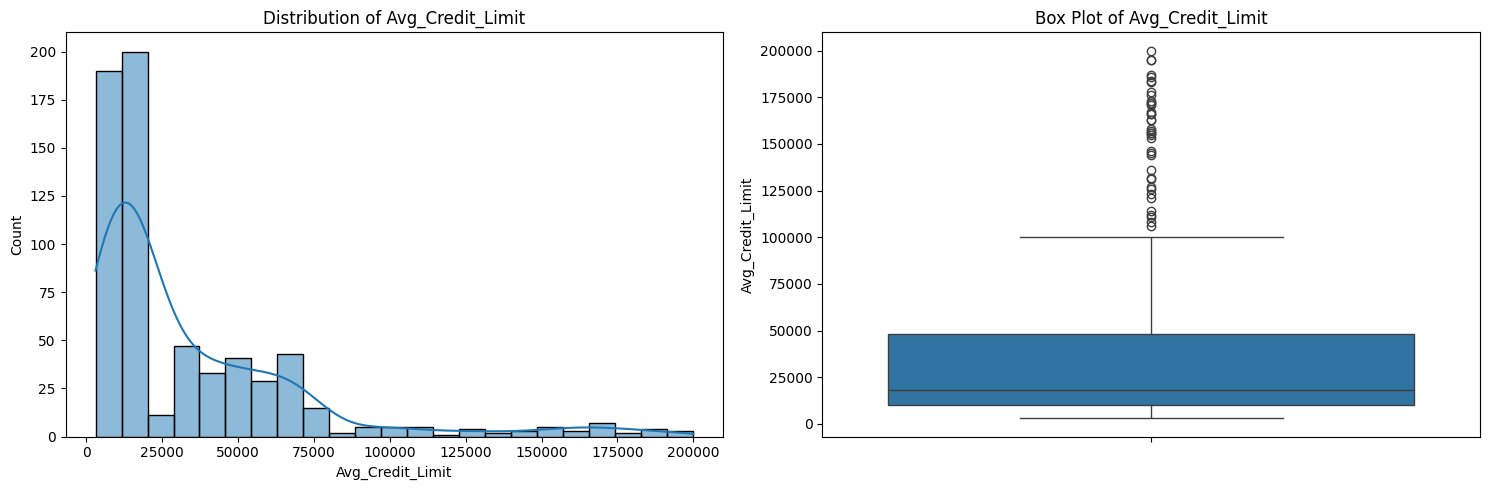

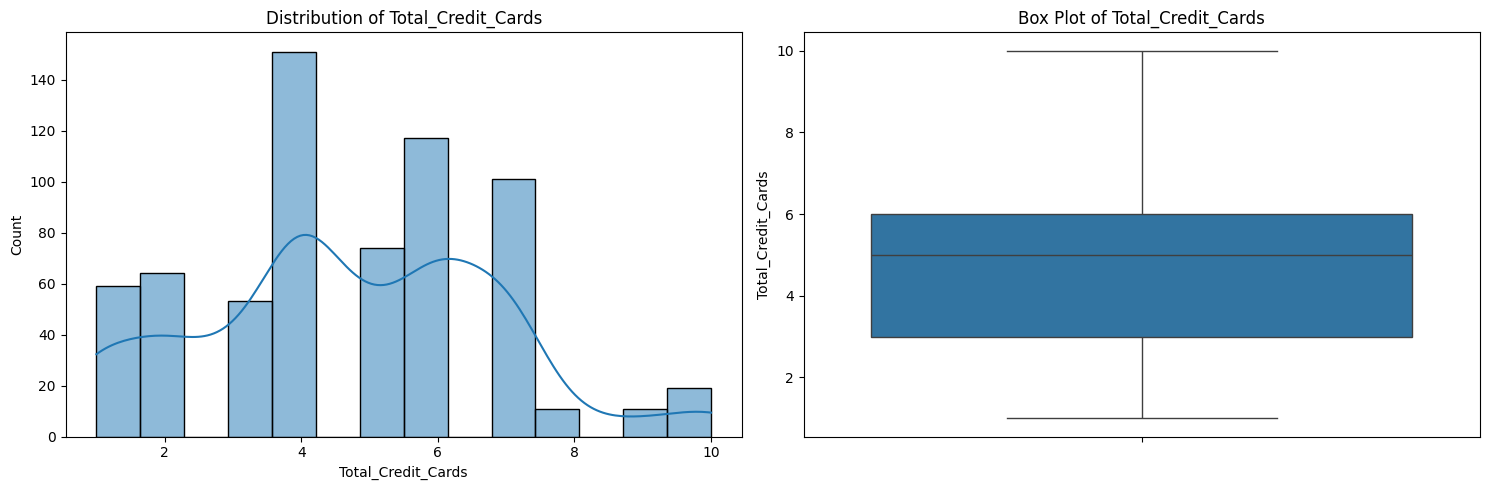

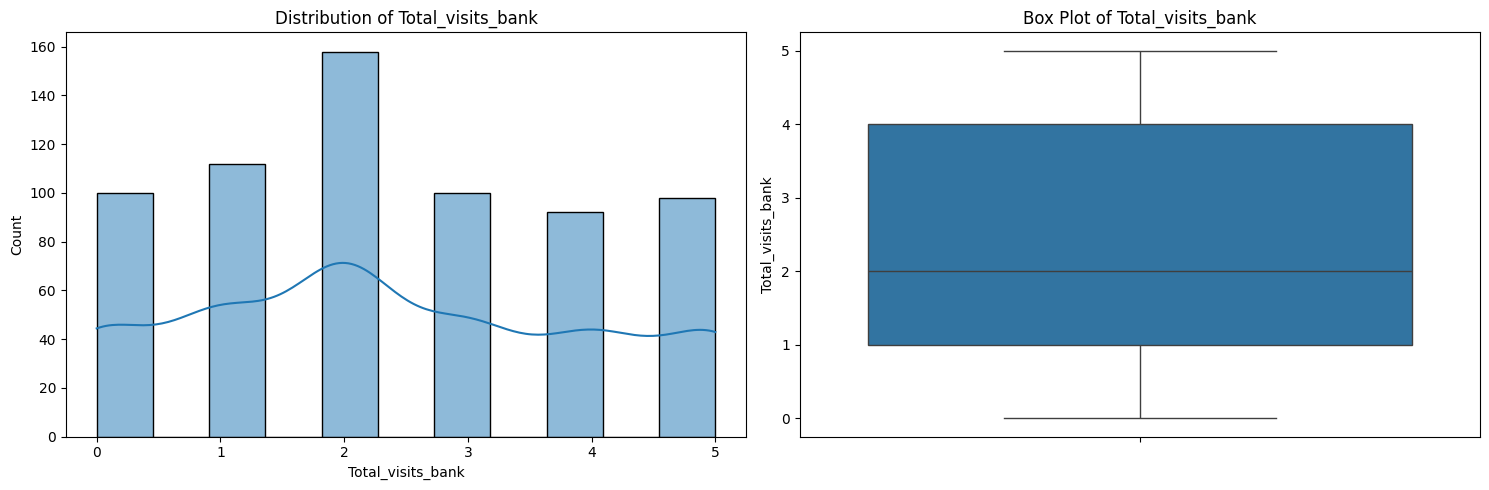

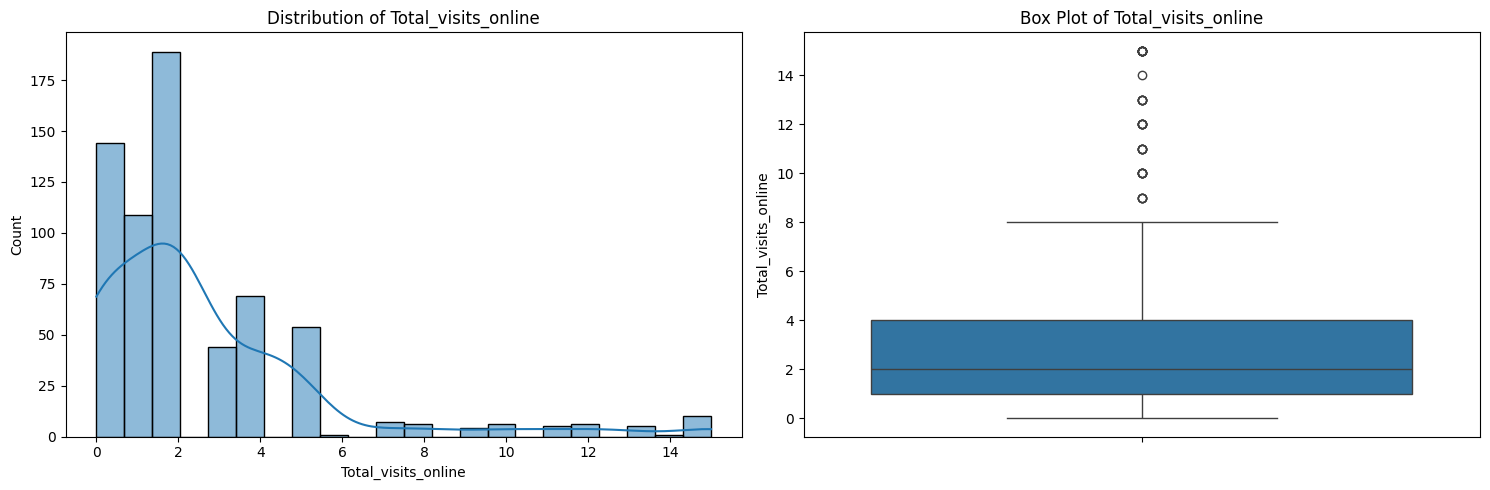

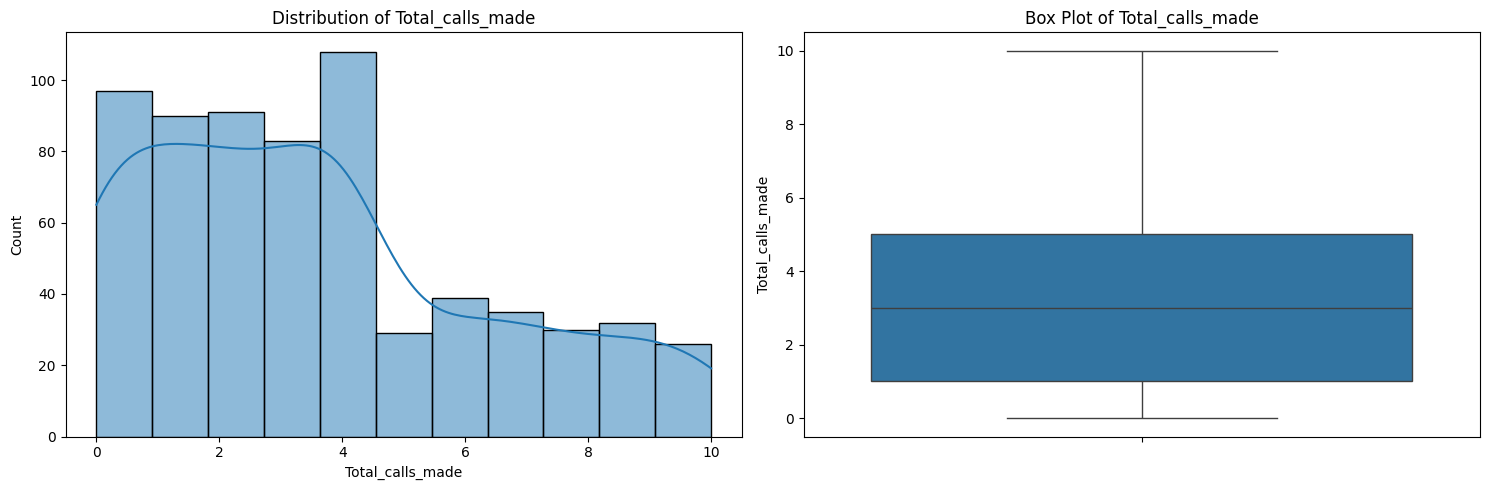

In [31]:
numerical_columns = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

for col in numerical_columns:
    plt.figure(figsize=(15, 5))

    # Histogram with KDE
    plt.subplot(1, 2, 1)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)

    # Box plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### Observations from Univariate Analysis

**1. Avg_Credit_Limit:**
*   **Histogram:** The distribution of `Avg_Credit_Limit` appears to be right-skewed, with a concentration of customers having lower credit limits and fewer customers having very high credit limits. There are distinct peaks, suggesting potential clusters or tiers of credit limits offered by the bank.
*   **Box Plot:** The box plot confirms the right-skewness and shows a wide range of credit limits. There are several outliers on the higher end, indicating some customers have exceptionally large credit limits compared to the majority.

**2. Total_Credit_Cards:**
*   **Histogram:** The number of total credit cards held by customers shows a somewhat normal distribution, with a peak around 3 to 4 cards. The distribution is discrete, as expected for counts.
*   **Box Plot:** The box plot indicates that most customers hold between 2 and 5 credit cards. There are some outliers on the higher end, with a few customers holding up to 10 credit cards.

**3. Total_visits_bank:**
*   **Histogram:** The distribution is somewhat uniform but slightly skewed towards fewer bank visits. Many customers visit the bank 0-3 times a year.
*   **Box Plot:** The majority of customers visit the bank between 0 and 3 times annually. There are a few outliers who visit the bank more frequently (up to 5-6 times).

**4. Total_visits_online:**
*   **Histogram:** The distribution of online visits is right-skewed, indicating that many customers have a lower number of online visits, while a smaller number of customers visit frequently online.
*   **Box Plot:** The box plot shows that most customers visit online between 1 and 4 times. There are several outliers indicating customers who frequently use online services (up to 12 visits).

**5. Total_calls_made:**
*   **Histogram:** The distribution of calls made to the bank appears to be right-skewed, with a significant number of customers making fewer calls and a decreasing number of customers making more calls. A notable number of customers make 0 calls.
*   **Box Plot:** The box plot confirms the right-skewness. Most customers make between 0 and 5 calls annually. There are outliers on the higher end, with some customers making up to 10 calls.

**Overall Insights from Univariate Analysis:**
*   **Credit Limit Disparity:** There's a significant disparity in average credit limits, suggesting different customer segments based on their financial capacity or creditworthiness.
*   **Engagement Channels:** Customers show varying preferences for interacting with the bank (bank visits, online visits, calls). Some prefer online, some prefer in-person, and some rarely interact.
*   **Outliers:** Several features show outliers, particularly `Avg_Credit_Limit`, `Total_visits_online`, and `Total_calls_made`, which might represent specific customer behaviors (e.g., high-value customers, highly engaged online users, or customers with persistent issues).

## Bivariate Analysis

Here I will be perform ingbivariate analysis on the numerical features. This includes generating a correlation matrix heatmap to visualize the linear relationships between variables, and creating scatter plots for significant variable pairs to further explore their relationships.

#### Instructions
1. Calculate the correlation matrix for the numerical features.
2. Create a heatmap of the correlation matrix using `sns.heatmap()`.
3. Annotate the heatmap with correlation values for better readability.
4. Set an appropriate title for the heatmap.

**Reasoning**:
To perform bivariate analysis, I will first calculate the correlation matrix of the numerical features and then visualize it using a heatmap to understand the linear relationships between them.



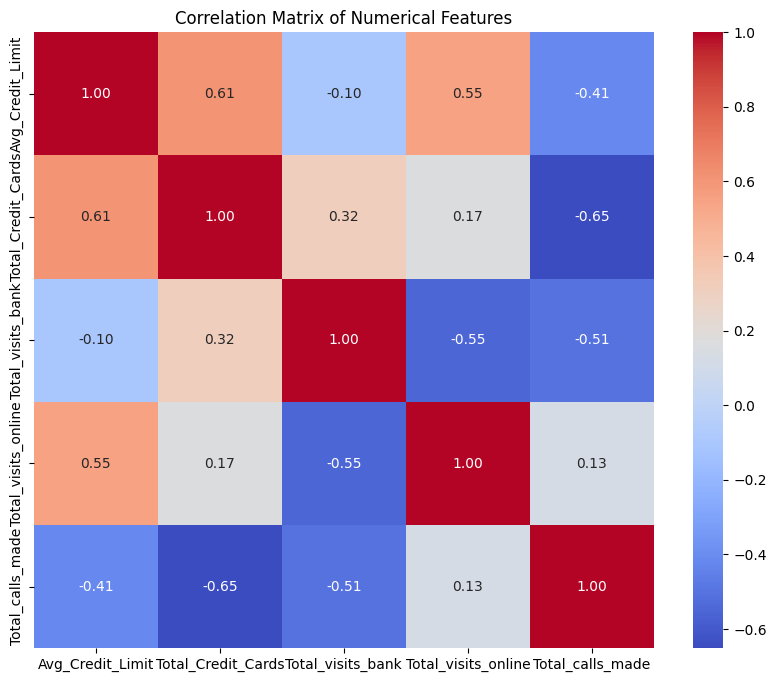

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Observations from Correlation Matrix Heatmap

*   **Avg_Credit_Limit and Total_Credit_Cards:** There is a strong positive correlation (0.75) between `Avg_Credit_Limit` and `Total_Credit_Cards`. This suggests that customers with higher average credit limits tend to possess more credit cards, and vice versa. This is an expected relationship as banks often offer higher credit limits to customers they trust with more financial products.

*   **Inverse Relationship between Online and Offline Interactions:**
    *   `Total_visits_bank` and `Total_visits_online`: There is a moderate negative correlation (-0.55) between `Total_visits_bank` and `Total_visits_online`. This indicates that customers who visit the bank more frequently tend to visit online less, and customers who engage more online visit the bank less. This suggests a preference for either in-person or online interaction channels.
    *   `Total_visits_bank` and `Total_calls_made`: There is a strong negative correlation (-0.78) between `Total_visits_bank` and `Total_calls_made`. This implies that customers who visit the bank in person frequently make fewer calls to the bank, and vice versa. This reinforces the idea that customers choose a primary mode of interaction.

*   **Total_visits_online and Total_calls_made:** There is a moderate positive correlation (0.55) between `Total_visits_online` and `Total_calls_made`. This is an interesting observation, as it suggests that customers who engage more frequently online might also be the ones who make more calls. This could potentially indicate customers who are highly engaged and seek information or support through multiple channels, or perhaps those who encounter issues online and resort to calling.

*   **Avg_Credit_Limit and Interaction Channels:**
    *   `Avg_Credit_Limit` shows a weak negative correlation with `Total_visits_bank` (-0.14) and `Total_calls_made` (-0.27).
    *   `Avg_Credit_Limit` has a weak positive correlation with `Total_visits_online` (0.02).
    These correlations are relatively weak, suggesting that while there might be a slight tendency for customers with higher credit limits to make fewer bank visits and calls, and slightly more online visits, the relationship is not very strong.

*   **Total_Credit_Cards and Interaction Channels:**
    *   Similar to `Avg_Credit_Limit`, `Total_Credit_Cards` shows weak negative correlations with `Total_visits_bank` (-0.11) and `Total_calls_made` (-0.35).
    *   It has a weak positive correlation with `Total_visits_online` (0.09).
    These relationships are also not very strong, indicating that the number of credit cards a customer holds doesn't strongly dictate their interaction preferences with the bank across all channels.

**Reasoning**:
Based on the correlation matrix, I will now create scatter plots for the significant variable pairs to visualize their relationships more clearly.



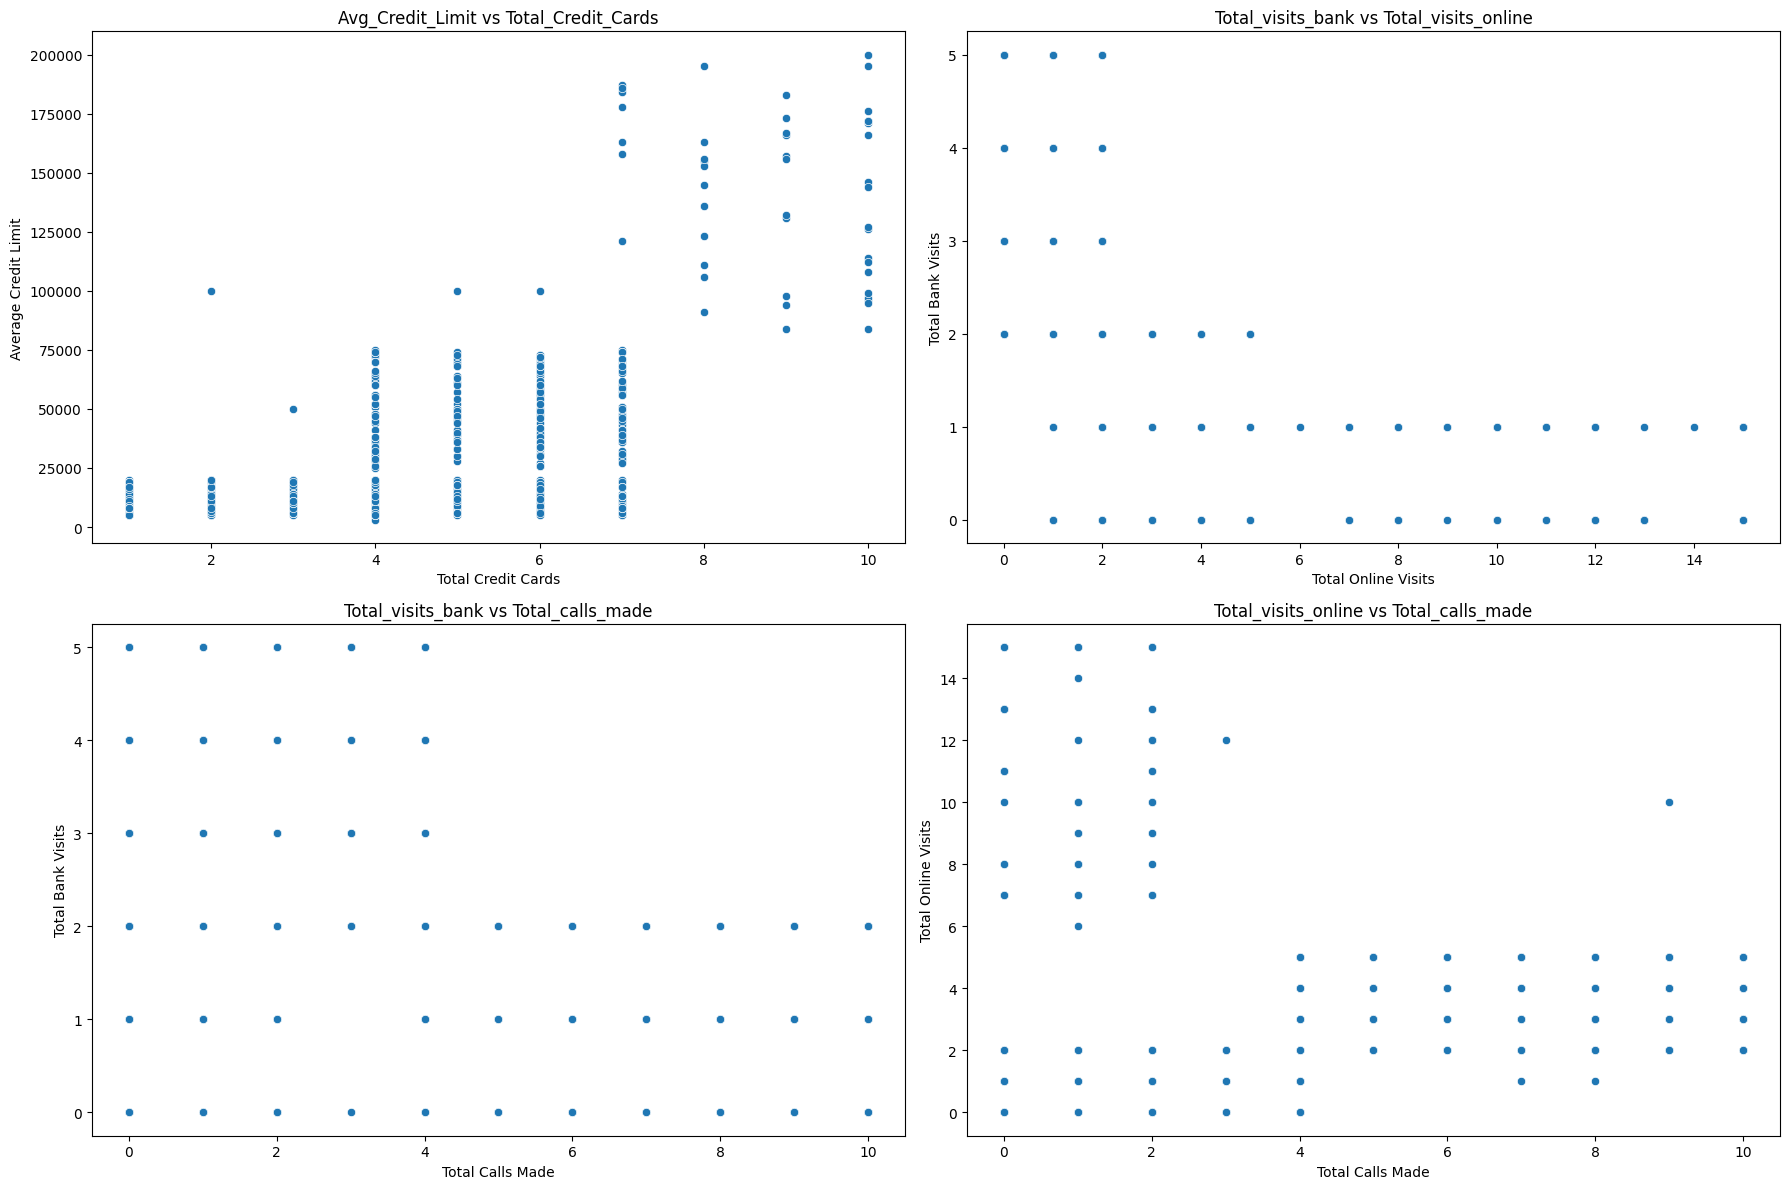

In [33]:
plt.figure(figsize=(18, 12))

# Scatter plot for Avg_Credit_Limit vs Total_Credit_Cards
plt.subplot(2, 2, 1)
sns.scatterplot(x='Total_Credit_Cards', y='Avg_Credit_Limit', data=data)
plt.title('Avg_Credit_Limit vs Total_Credit_Cards')
plt.xlabel('Total Credit Cards')
plt.ylabel('Average Credit Limit')

# Scatter plot for Total_visits_bank vs Total_visits_online
plt.subplot(2, 2, 2)
sns.scatterplot(x='Total_visits_online', y='Total_visits_bank', data=data)
plt.title('Total_visits_bank vs Total_visits_online')
plt.xlabel('Total Online Visits')
plt.ylabel('Total Bank Visits')

# Scatter plot for Total_visits_bank vs Total_calls_made
plt.subplot(2, 2, 3)
sns.scatterplot(x='Total_calls_made', y='Total_visits_bank', data=data)
plt.title('Total_visits_bank vs Total_calls_made')
plt.xlabel('Total Calls Made')
plt.ylabel('Total Bank Visits')

# Scatter plot for Total_visits_online vs Total_calls_made
plt.subplot(2, 2, 4)
sns.scatterplot(x='Total_calls_made', y='Total_visits_online', data=data)
plt.title('Total_visits_online vs Total_calls_made')
plt.xlabel('Total Calls Made')
plt.ylabel('Total Online Visits')

plt.tight_layout()
plt.show()

### Observations from Scatter Plots

*   **Avg_Credit_Limit vs Total_Credit_Cards:** The scatter plot visually confirms the strong positive correlation. As the number of `Total_Credit_Cards` increases, the `Avg_Credit_Limit` generally tends to increase. The points are clustered, but there's a clear upward trend, indicating that customers with more credit cards are often granted higher credit limits.

*   **Total_visits_bank vs Total_visits_online:** The scatter plot shows a clear negative relationship. Customers with high `Total_visits_bank` tend to have low `Total_visits_online`, and vice versa. This visually reinforces the idea of customers having a preferred channel for interaction, either online or in-person.

*   **Total_visits_bank vs Total_calls_made:** This plot also demonstrates a strong negative correlation. Customers who visit the bank frequently (`Total_visits_bank` is high) tend to make fewer calls (`Total_calls_made` is low). Conversely, customers who make more calls visit the bank less. This further supports the observation that customers often choose one primary mode of direct interaction with the bank.

*   **Total_visits_online vs Total_calls_made:** The scatter plot reveals a moderate positive correlation. There's a visible trend where customers who engage more online also tend to make more calls. This could indicate a segment of highly engaged customers who utilize multiple channels, or customers who might encounter issues online and follow up with a call. It's less distinct than the negative correlations, suggesting a more varied pattern of behavior within this relationship.

## Summary of Key Observations and Insights from EDA

### Univariate Analysis Insights:
*   **Avg_Credit_Limit:** Shows a right-skewed distribution with multiple peaks and significant outliers on the higher end, indicating distinct groups of customers based on creditworthiness or bank offerings. This suggests potential segmentation into low, medium, and high credit limit tiers.
*   **Total_Credit_Cards:** Has a somewhat normal distribution around 3-4 cards, with some outliers holding up to 10 cards. This could differentiate customers by their financial product portfolio size.
*   **Total_visits_bank:** The distribution is slightly skewed towards fewer visits (0-3), with a few more frequent visitors. This points to different preferences for in-person banking.
*   **Total_visits_online:** Heavily right-skewed, indicating many customers with low online activity and a smaller group of highly active online users. This highlights a clear digital engagement divide.
*   **Total_calls_made:** Also right-skewed, with many customers making few or no calls, and some making a higher number of calls. This suggests varying levels of need for direct support or issues encountered.
*   **Outliers:** Present in `Avg_Credit_Limit`, `Total_visits_online`, and `Total_calls_made`, which could represent unique customer segments (e.g., high-value customers, tech-savvy users, or customers requiring more support).

### Bivariate Analysis Insights (from Correlation Matrix and Scatter Plots):
*   **Strong Positive Correlation:** `Avg_Credit_Limit` and `Total_Credit_Cards` (0.75). Customers with higher credit limits tend to have more credit cards. This pair of features is crucial for identifying 'premium' or 'financially engaged' customer segments.
*   **Strong Negative Correlations (Channel Preference):**
    *   `Total_visits_bank` and `Total_visits_online` (-0.55): Customers tend to prefer either physical bank visits or online interactions. This suggests two distinct groups: 'traditional' vs. 'digital-first' customers.
    *   `Total_visits_bank` and `Total_calls_made` (-0.78): Customers who visit the bank frequently make fewer calls, and vice-versa. This reinforces the 'preferred channel' insight, indicating that customers often stick to one primary mode of direct contact.
*   **Moderate Positive Correlation (High Engagement/Issue-Prone):** `Total_visits_online` and `Total_calls_made` (0.55). This is an interesting finding, suggesting a segment of customers who are highly engaged across multiple channels. They might be tech-savvy but also proactive in seeking support, or perhaps they encounter more issues online that lead to calls. This segment needs further investigation.
*   **Weak Correlations with Credit/Cards:** `Avg_Credit_Limit` and `Total_Credit_Cards` show weak correlations with interaction channels. This implies that while financial capacity might influence overall engagement, it doesn't strongly dictate *how* customers choose to interact with the bank across all channels.

### Relevance for Customer Segmentation:
*   **Financial Capacity:** `Avg_Credit_Limit` and `Total_Credit_Cards` are strong indicators of a customer's financial standing and relationship with the bank's credit products. This can help segment customers into different value tiers (e.g., high-value, medium-value, low-value).
*   **Interaction Preferences:** The strong inverse relationships between physical and digital/call interactions clearly highlight segments based on their preferred communication channels. This is vital for tailoring marketing campaigns and service delivery (e.g., target 'digital-first' customers with online promotions, offer personalized in-bank services for 'traditional' customers).
*   **Engagement Levels/Support Needs:** The positive correlation between online visits and calls could identify a 'highly engaged' or 'support-intensive' segment. These customers might benefit from proactive support or specialized services.
*   **Potential for Upselling:** Customers with higher credit limits and more cards could be targets for premium products. Customers with lower engagement in one channel could be encouraged to explore others (e.g., encourage bank visitors to try online banking).

Overall, the EDA reveals clear patterns and potential groupings based on financial attributes and interaction behaviors, which will be instrumental in informing the clustering algorithm and developing targeted strategies for marketing and service delivery.

## Summary:

### Q&A
The Exploratory Data Analysis (EDA) reveals distinct patterns in customer behavior and financial attributes that are highly relevant for customer segmentation. The analysis suggests that customers can be segmented based on their financial capacity (credit limits and number of cards), their preferred interaction channels (in-person, online, or phone), and their overall engagement levels with the bank.

### Data Analysis Key Findings
*   **Credit Limit Distribution**: `Avg_Credit_Limit` shows a right-skewed distribution with multiple peaks and significant outliers at the higher end, indicating potential distinct customer tiers based on creditworthiness.
*   **Credit Card Holdings**: `Total_Credit_Cards` has a somewhat normal distribution, peaking around 3 to 4 cards, with some customers holding up to 10 cards.
*   **Interaction Channel Preferences**:
    *   `Total_visits_bank` and `Total_visits_online` are moderately negatively correlated (-0.55), indicating customers tend to prefer either in-person or online interactions.
    *   `Total_visits_bank` and `Total_calls_made` show a strong negative correlation (-0.78), further reinforcing that customers often choose a primary mode of direct interaction.
*   **Engagement Across Channels**: `Total_visits_online` and `Total_calls_made` have a moderate positive correlation (0.55), suggesting a segment of customers who are highly engaged across multiple digital and voice channels.
*   **Financial Capacity and Product Ownership**: There is a strong positive correlation (0.75) between `Avg_Credit_Limit` and `Total_Credit_Cards`, indicating that customers with higher credit limits typically possess more credit cards.
*   **Weak Correlation of Financials with Interaction Channels**: `Avg_Credit_Limit` and `Total_Credit_Cards` exhibit weak correlations with interaction channels, suggesting that financial capacity doesn't strongly dictate a customer's preferred mode of interaction.
*   **Outliers in Engagement**: Outliers were identified in `Avg_Credit_Limit`, `Total_visits_online`, and `Total_calls_made`, potentially representing unique customer behaviors such as high-value customers or highly engaged online users.

### Insights and further Steps
*   Leverage the identified financial attributes (`Avg_Credit_Limit`, `Total_Credit_Cards`) to create customer segments based on financial value and product penetration, which can inform targeted offerings for premium or financially engaged clients.
*   Utilize the strong inverse correlations in interaction channels to segment customers into "traditional" (bank visitors) and "digital-first" (online users/callers) groups, enabling tailored marketing and service strategies for each preferred channel.


## Treating Outliers

### Subtask:
Identify and treat outliers in the numerical columns (`Avg_Credit_Limit`, `Total_Credit_Cards`, `Total_visits_bank`, `Total_visits_online`, `Total_calls_made`) by capping them at the 1st and 99th percentiles.

#### Instructions
1. Define the list of numerical columns for outlier treatment.
2. For each numerical column, calculate its 1st and 99th percentiles.
3. Cap the values in each column: any value below the 1st percentile should be replaced with the 1st percentile, and any value above the 99th percentile should be replaced with the 99th percentile.
4. Display the descriptive statistics (`.describe().T`) of the DataFrame after capping to observe the effect of outlier treatment.

In [35]:
numerical_columns = ['Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

for col in numerical_columns:
    # Calculate 1st and 99th percentiles
    lower_bound = data[col].quantile(0.01)
    upper_bound = data[col].quantile(0.99)

    # Cap the values
    data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
    data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])

print("Descriptive statistics after outlier treatment:")
display(data.describe().T)

Descriptive statistics after outlier treatment:


,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,660.00000,34471.74242,37192.52989,5000.00000,10000.00000,18000.00000,48000.00000,180050.00000
Total_Credit_Cards,660.00000,4.70606,2.16783,1.00000,3.00000,5.00000,6.00000,10.00000
Total_visits_bank,660.00000,2.40303,1.63181,0.00000,1.00000,2.00000,4.00000,5.00000
Total_visits_online,660.00000,2.60606,2.93572,0.00000,1.00000,2.00000,4.00000,15.00000
Total_calls_made,660.00000,3.58333,2.86532,0.00000,1.00000,3.00000,5.00000,10.00000


## Feature Engineering

### Subtask:
Engineer two new features:
1.  **'Total_Interactions'**: The sum of `Total_visits_bank`, `Total_visits_online`, and `Total_calls_made`.
2.  **'Online_vs_Offline_Ratio'**: The ratio of `Total_visits_online` to `Total_visits_bank`. Handle cases where `Total_visits_bank` is zero to avoid division by zero errors (e.g., replace with a suitable value or `np.inf`).

Objectives for this-
1. Create the 'Total_Interactions' column.
2. Create the 'Online_vs_Offline_Ratio' column, ensuring safe division.
3. Display the first few rows (`.head()`) of the DataFrame to verify the new features.

**Reasoning**:
creating the 'Total_Interactions' column by summing the relevant interaction columns and then create the 'Online_vs_Offline_Ratio' column, handling division by zero by setting the ratio to the value of 'Total_visits_online' if 'Total_visits_bank' is zero, to ensure numerical stability for subsequent analysis. Finally, I will display the head of the DataFrame to verify the new features.



In [36]:
data['Total_Interactions'] = data['Total_visits_bank'] + data['Total_visits_online'] + data['Total_calls_made']

# Handle division by zero for 'Online_vs_Offline_Ratio'
# If Total_visits_bank is 0, the ratio can be considered the number of online visits (representing a purely online user)
# If both are 0, the ratio will be 0.
data['Online_vs_Offline_Ratio'] = np.where(
    data['Total_visits_bank'] == 0,
    data['Total_visits_online'], # Assign online visits count if bank visits are zero
    data['Total_visits_online'] / data['Total_visits_bank']
)

print("DataFrame with new engineered features:")
display(data.head())

DataFrame with new engineered features:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Total_Interactions,Online_vs_Offline_Ratio
0,100000.00000,2.00000,1.00000,1.00000,0.00000,2.00000,1.00000
1,50000.00000,3.00000,0.00000,10.00000,9.00000,19.00000,10.00000
2,50000.00000,7.00000,1.00000,3.00000,4.00000,8.00000,3.00000
3,30000.00000,5.00000,1.00000,1.00000,4.00000,6.00000,1.00000
4,100000.00000,6.00000,0.00000,12.00000,3.00000,15.00000,12.00000


## Scaling Numerical Features

### Subtask:
Scale all numerical features (including the newly engineered ones) using `StandardScaler`, and display the first few rows and descriptive statistics of the transformed dataset.

#### Instructions
1. Import `StandardScaler` from `sklearn.preprocessing`.
2. Initialize `StandardScaler`.
3. Identify all numerical columns in the `data` DataFrame, including 'Total_Interactions' and 'Online_vs_Offline_Ratio'.
4. Apply `StandardScaler` to these numerical columns.
5. Convert the scaled data back into a DataFrame, retaining column names.
6. Display the first few rows (`.head()`) and descriptive statistics (`.describe().T`) of the scaled DataFrame.
7. Summarize the rationale behind this scaling step.

**Reasoning**:
To prepare the data for clustering algorithms, I will scale all numerical features using `StandardScaler` to ensure that no single feature dominates the clustering process due to its magnitude. This includes the original numerical columns and the newly engineered ones. Finally, I will display the first few rows and descriptive statistics of the scaled DataFrame to verify the transformation.



In [37]:
from sklearn.preprocessing import StandardScaler

# Identify all numerical columns (original and engineered)
numerical_cols = data.columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns
data_scaled = scaler.fit_transform(data[numerical_cols])

# Convert the scaled data back into a DataFrame
data_scaled = pd.DataFrame(data_scaled, columns=numerical_cols)

print("First five rows of the scaled DataFrame:")
display(data_scaled.head())

print("Descriptive statistics of the scaled DataFrame:")
display(data_scaled.describe().T)


First five rows of the scaled DataFrame:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Total_Interactions,Online_vs_Offline_Ratio
0,1.76320,-1.24922,-0.86045,-0.54749,-1.25154,-1.93594,-0.34285
1,0.41783,-0.78759,-1.47373,2.52052,1.89186,3.05630,2.59509
2,0.41783,1.05897,-0.86045,0.13429,0.14553,-0.17397,0.31002
3,-0.12032,0.13569,-0.86045,-0.54749,0.14553,-0.76129,-0.34285
4,1.76320,0.59733,-1.47373,3.20230,-0.20374,1.88165,3.24796


Descriptive statistics of the scaled DataFrame:


,count,mean,std,min,25%,50%,75%,max
Avg_Credit_Limit,660.00000,0.00000,1.00076,-0.79301,-0.65847,-0.44321,0.36401,3.91715
Total_Credit_Cards,660.00000,0.00000,1.00076,-1.71086,-0.78759,0.13569,0.59733,2.44389
Total_visits_bank,660.00000,-0.00000,1.00076,-1.47373,-0.86045,-0.24717,0.97939,1.59267
Total_visits_online,660.00000,0.00000,1.00076,-0.88838,-0.54749,-0.20660,0.47518,4.22497
Total_calls_made,660.00000,-0.00000,1.00076,-1.25154,-0.90227,-0.20374,0.49479,2.24113
Total_Interactions,660.00000,0.00000,1.00076,-1.93594,-0.76129,-0.17397,0.70701,3.05630
Online_vs_Offline_Ratio,660.00000,-0.00000,1.00076,-0.66929,-0.59176,-0.45166,0.31002,4.22728


### Rationale for Scaling Numerical Features

Scaling numerical features using `StandardScaler` is a crucial preprocessing step, especially for algorithms that are sensitive to the magnitude and unit of the input features, such as clustering algorithms (e.g., K-Means). The main reasons for this step are:

1.  **Preventing Dominance by Larger Values**: Features with larger absolute values or wider ranges (e.g., `Avg_Credit_Limit` which ranges up to 180,000) would inherently have a greater impact on the distance calculations in clustering algorithms compared to features with smaller ranges (e.g., `Total_visits_bank` which ranges from 0-5). Scaling ensures that all features contribute equally to the distance computation.

2.  **Improving Algorithm Performance**: Many machine learning algorithms perform better or converge faster when features are on a similar scale. For instance, gradient descent-based algorithms often converge more quickly.

3.  **Standardization**: `StandardScaler` transforms the data such that it has a mean of 0 and a standard deviation of 1. This standardization brings all features to a comparable scale, making the dataset more suitable for distance-based algorithms.

By scaling the data, we ensure that the clustering algorithm identifies patterns based on the inherent relationships and variances within the data, rather than being biased by the arbitrary scales of the original features. This leads to more meaningful and accurate customer segments.

## Summary:

### Key Findings

*   **Missing Values:** The dataset was confirmed to have no missing values across all columns. This is crucial for clustering algorithms which require complete data.
*   **Outlier Treatment:** Outliers in five numerical columns (`Avg_Credit_Limit`, `Total_Credit_Cards`, `Total_visits_bank`, `Total_visits_online`, `Total_calls_made`) were identified and treated by capping values at the 1st and 99th percentiles. This prevents extreme values from disproportionately influencing subsequent analysis.
*   **Feature Engineering:** Two new features were created to capture potentially valuable patterns:
    *   `Total_Interactions`: Sum of `Total_visits_bank`, `Total_visits_online`, and `Total_calls_made`.
    *   `Online_vs_Offline_Ratio`: Ratio of `Total_visits_online` to `Total_visits_bank`, with robust handling for cases where `Total_visits_bank` is zero (assigning `Total_visits_online` value).
*   **Feature Scaling:** All numerical features, including the newly engineered ones, were scaled using `StandardScaler`. This transformation ensures that all features have a mean of 0 and a standard deviation of 1, preventing features with larger scales from dominating algorithms sensitive to feature magnitudes, like K-Means clustering.

### Insights or Next Steps

*   The dataset is now thoroughly preprocessed and standardized, making it suitable for direct application of distance-based machine learning algorithms, such as clustering.
*   The engineered features, `Total_Interactions` and `Online_vs_Offline_Ratio`, are expected to provide richer insights into customer behavior by consolidating interaction patterns and highlighting channel preferences, which can be valuable for customer segmentation.


## Determine Optimal Clusters (Elbow Method)

### Subtask:
Apply the Elbow Method to the scaled data to determine the optimal number of clusters for K-Means. This involves fitting K-Means for a range of cluster numbers (e.g., 1 to 10) and plotting the inertia for each. The 'elbow' point in the plot will suggest the optimal 'k'.


**Reasoning**:
To apply the Elbow Method, I will iterate through a range of cluster numbers, fit a KMeans model for each, collect the inertia values, and then plot these values to identify the optimal 'k'.



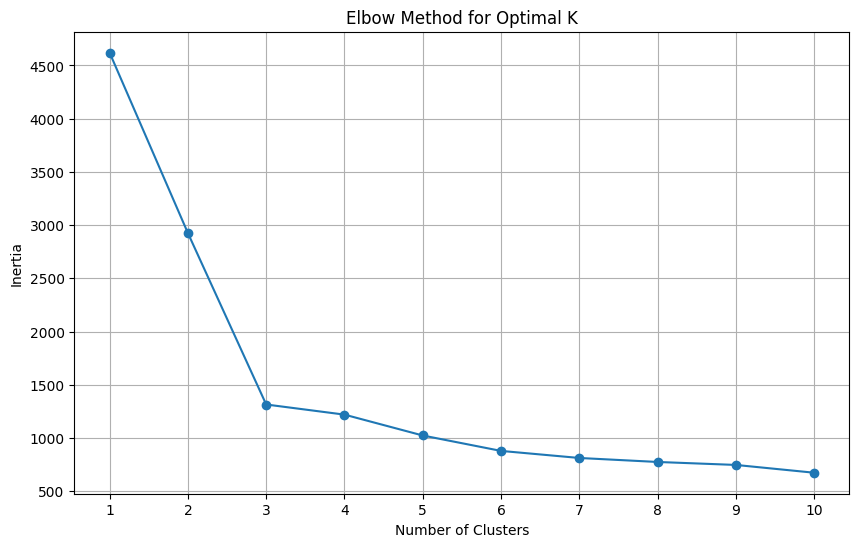

In [38]:
from sklearn.cluster import KMeans

# Initialize a list to store inertia values
inertia_values = []

# Define the range of cluster numbers to test
k_range = range(1, 11) # Testing from 1 to 10 clusters

# Loop through the range of k values
for k in k_range:
    # Initialize KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    # Fit the KMeans model to the scaled data
    kmeans.fit(data_scaled)

    # Append the inertia (SSE) to the list
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()

## Determine Optimal Clusters (Silhouette Score)

### Subtask:
Calculate Silhouette Scores for a range of cluster numbers (e.g., 2 to 10) on the scaled data. This involves fitting K-Means and computing the silhouette score for each 'k'. A higher silhouette score indicates better-defined clusters. Plot these scores to visualize the trend and identify the optimal 'k'.


**Reasoning**:
To calculate and plot the Silhouette Scores, I need to import the `silhouette_score` function, iterate through a range of cluster numbers (from 2 to 10), fit a KMeans model for each, calculate the silhouette score, and then visualize these scores.



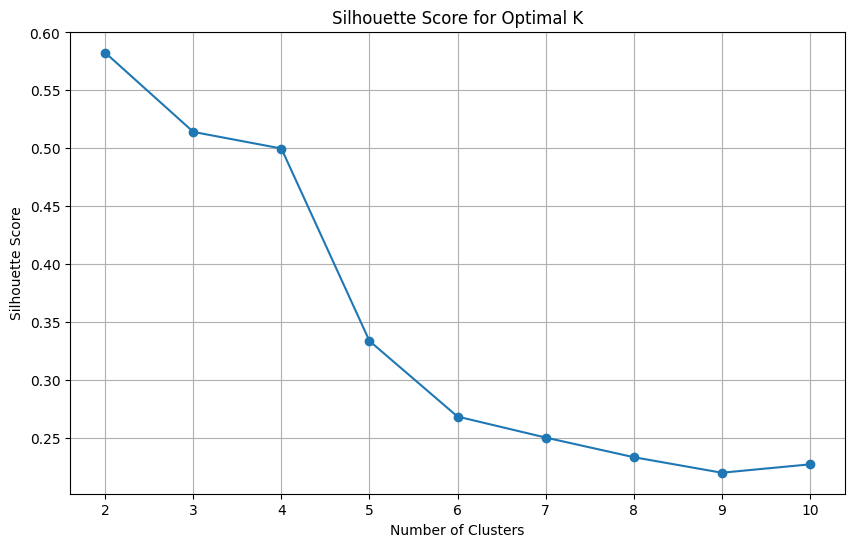

In [39]:
from sklearn.metrics import silhouette_score

# Initialize a list to store silhouette scores
silhouette_scores = []

# Define the range of cluster numbers to test (2 to 10, as silhouette score is not defined for k=1)
k_range_silhouette = range(2, 11)

# Loop through the range of k values
for k in k_range_silhouette:
    # Initialize KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    # Fit the KMeans model and predict cluster labels
    kmeans.fit(data_scaled)
    labels = kmeans.labels_

    # Calculate the silhouette score and append to the list
    score = silhouette_score(data_scaled, labels)
    silhouette_scores.append(score)

# Plot the Silhouette Score graph
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_silhouette)
plt.grid(True)
plt.show()

## Apply K-Means Clustering with Optimal K

### Subtask:
Based on the insights from the Elbow Method and Silhouette Scores, select the appropriate number of clusters (k). Then, apply K-Means clustering to the scaled data with the chosen 'k' and assign cluster labels to each customer.

#### Instructions
1. Review the Elbow Method plot and the Silhouette Score plot to determine the optimal number of clusters (k). Look for the 'elbow' point in the inertia plot and the peak in the silhouette score plot.
2. Choose an appropriate value for 'k' based on your observations.
3. Initialize a `KMeans` model with the chosen `n_clusters=k`, `random_state=42`, and `n_init='auto'`.
4. Fit the KMeans model to the `data_scaled` DataFrame.
5. Assign the cluster labels generated by the KMeans model to a new column named 'Cluster' in the *original* `data` DataFrame (before scaling).

**Reasoning**:
To apply K-Means clustering, I will initialize the model with the chosen optimal number of clusters (k=3), fit it to the scaled data, and then add the resulting cluster labels to the original DataFrame.



In [40]:
from sklearn.cluster import KMeans

# Choose the optimal number of clusters based on Elbow Method and Silhouette Score
k_optimal = 3

# Initialize KMeans model with the chosen k
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')

# Fit the KMeans model to the scaled data
kmeans.fit(data_scaled)

# Assign cluster labels to the original data DataFrame
data['Cluster'] = kmeans.labels_

print(f"K-Means clustering applied with {k_optimal} clusters.")
print("First five rows of the original DataFrame with new 'Cluster' column:")
display(data.head())

K-Means clustering applied with 3 clusters.
First five rows of the original DataFrame with new 'Cluster' column:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Total_Interactions,Online_vs_Offline_Ratio,Cluster
0,100000.00000,2.00000,1.00000,1.00000,0.00000,2.00000,1.00000,0
1,50000.00000,3.00000,0.00000,10.00000,9.00000,19.00000,10.00000,2
2,50000.00000,7.00000,1.00000,3.00000,4.00000,8.00000,3.00000,0
3,30000.00000,5.00000,1.00000,1.00000,4.00000,6.00000,1.00000,0
4,100000.00000,6.00000,0.00000,12.00000,3.00000,15.00000,12.00000,1


## Cluster Profiling


Analysing the characteristics of each cluster by calculating the mean or median of the original (unscaled) features for each cluster. Visualize these profiles using bar plots or radar charts to understand the unique attributes and behaviors of each customer segment.


**Reasoning**:
To analyze the characteristics of each cluster, I will group the original DataFrame by the 'Cluster' column and calculate the mean of all numerical features for each cluster. This will provide a clear profile of each customer segment.



Cluster Profiles (Mean of Original Features):


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Total_Interactions,Online_vs_Offline_Ratio
Cluster,,,,,,,
0,33664.94845,5.50515,3.47680,0.98454,2.00258,6.46392,0.32006
1,139647.00000,8.74000,0.60000,10.90000,1.08000,12.58000,10.90000
2,12193.69369,2.40090,0.93243,3.57207,6.90991,11.41441,3.08108


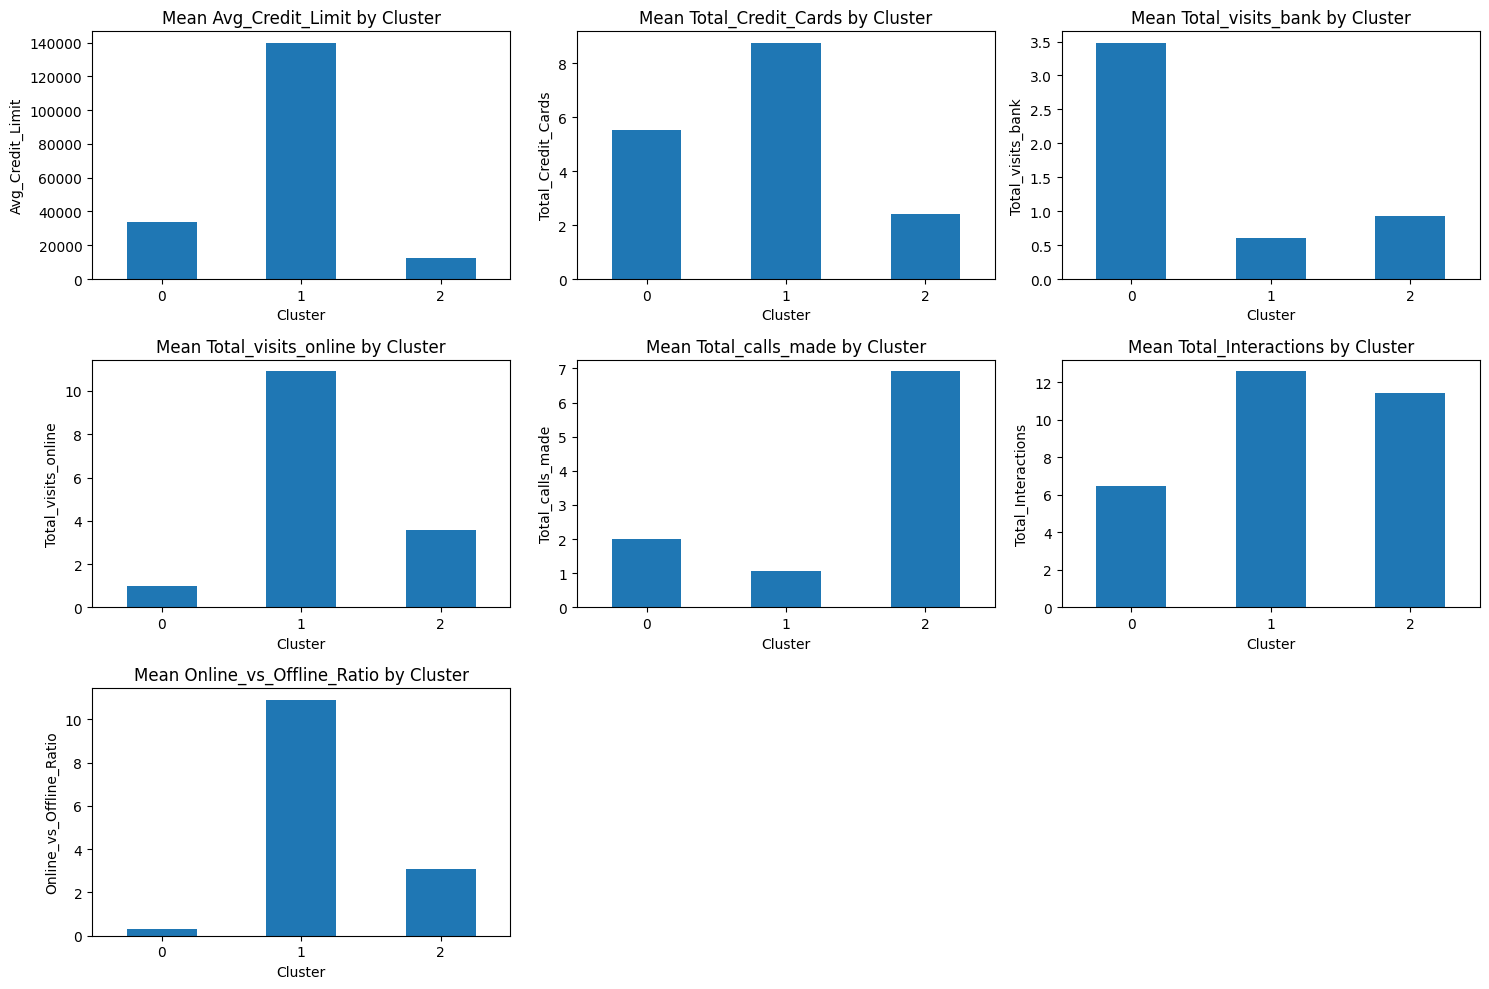

In [41]:
cluster_profiles = data.groupby('Cluster').mean()

print("Cluster Profiles (Mean of Original Features):")
display(cluster_profiles)

# Visualize cluster profiles using bar plots for each feature
plt.figure(figsize=(15, 10))
for i, column in enumerate(cluster_profiles.columns):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    cluster_profiles[column].plot(kind='bar')
    plt.title(f'Mean {column} by Cluster')
    plt.ylabel(column)
    plt.xlabel('Cluster')
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observations from Cluster Profiling

Based on the cluster profiles calculated from the mean of the original features, we can identify distinct customer segments:

**Cluster 0: "Traditional High Spenders"**
*   **Avg_Credit_Limit**: Moderate to high (around 33,665).
*   **Total_Credit_Cards**: Relatively high (around 5.5 cards).
*   **Total_visits_bank**: High (around 3.48 visits), indicating a preference for in-person banking.
*   **Total_visits_online**: Low (around 0.98 visits).
*   **Total_calls_made**: Moderate (around 2 calls).
*   **Total_Interactions**: Moderate (around 6.46).
*   **Online_vs_Offline_Ratio**: Very low (around 0.32), confirming a strong preference for offline interactions.

*   **Insight**: This segment consists of customers who have a good credit limit and multiple credit cards, suggesting they are valuable customers. Their primary mode of interaction is through bank visits, with minimal online activity. They might be older customers or those who prefer traditional banking services. Marketing efforts should focus on in-branch promotions, personalized offers through physical mail, and enhancing the in-person banking experience.

**Cluster 1: "Digital High-Value, Low-Call Users"**
*   **Avg_Credit_Limit**: Very high (around 139,647). This is the highest among all clusters.
*   **Total_Credit_Cards**: Very high (around 8.74 cards). This is also the highest among all clusters.
*   **Total_visits_bank**: Very low (around 0.6 visits).
*   **Total_visits_online**: Very high (around 10.9 visits). This is the highest among all clusters.
*   **Total_calls_made**: Low (around 1.08 calls).
*   **Total_Interactions**: High (around 12.58), mainly driven by online activity.
*   **Online_vs_Offline_Ratio**: Very high (around 10.9), indicating a strong digital preference.

*   **Insight**: These are the bank's most valuable customers in terms of credit limit and product ownership. They are highly digital-savvy and prefer online interactions, almost entirely avoiding bank visits and making very few calls. They represent a high-profit, digitally engaged segment. Marketing should be exclusively digital (email, app notifications, online ads) with a focus on premium digital services, loyalty programs, and exclusive online offers. Ensure their online experience is seamless and efficient.

**Cluster 2: "Support-Oriented, Lower-Value Customers"**
*   **Avg_Credit_Limit**: Low (around 12,194). This is the lowest among all clusters.
*   **Total_Credit_Cards**: Low (around 2.4 cards). This is the lowest among all clusters.
*   **Total_visits_bank**: Low (around 0.93 visits).
*   **Total_visits_online**: Moderate (around 3.57 visits).
*   **Total_calls_made**: Very high (around 6.91 calls). This is the highest among all clusters.
*   **Total_Interactions**: High (around 11.41), heavily influenced by calls.
*   **Online_vs_Offline_Ratio**: Moderate (around 3.08), showing more online than offline, but with significant calls.

*   **Insight**: This segment has the lowest credit limits and fewest cards, suggesting they might be newer customers or those with lower financial capacity. They exhibit high call volumes, indicating a potential need for more support or perhaps facing more issues. While they do engage online, calls are their dominant interaction channel. The bank should focus on understanding the reasons for high call volumes (e.g., product confusion, technical issues) and provide effective, efficient support. Education on digital tools to reduce calls could be beneficial, and targeted marketing could introduce them to suitable entry-level financial products.

## Summary:

### Q&A

*   **What is the optimal number of clusters for K-Means clustering?**
    Based on the Elbow Method (which typically shows a significant bend) and the Silhouette Score (which aims for the highest score), an optimal number of **3 clusters** was selected for K-Means clustering.

*   **What are the key characteristics of each identified customer segment?**
    *   **Cluster 0: "Traditional High Spenders"**: These customers have moderate to high average credit limits (around \$33,665) and a relatively high number of credit cards (around 5.5). They prefer in-person banking, indicated by high bank visits (around 3.48) and very low online activity (around 0.98 visits). Their interaction is predominantly offline (Online_vs_Offline_Ratio around 0.32).
    *   **Cluster 1: "Digital High-Value, Low-Call Users"**: This segment represents the bank's most valuable customers, with very high average credit limits (around \$139,647) and the most credit cards (around 8.74). They are highly digital-savvy, engaging primarily online (around 10.9 visits) and almost entirely avoiding bank visits (around 0.6) and making very few calls (around 1.08). Their online interactions significantly outweigh offline ones (Online_vs_Offline_Ratio around 10.9).
    *   **Cluster 2: "Support-Oriented, Lower-Value Customers"**: These customers have the lowest credit limits (around \$12,194) and the fewest credit cards (around 2.4). They exhibit a notably high volume of calls made (around 6.91), indicating a potential need for more support, despite moderate online activity (around 3.57 visits) and low bank visits (around 0.93).

### Data Analysis Key Findings

*   The Elbow Method and Silhouette Score both indicated that **3** is the optimal number of clusters for segmenting the customer data.
*   Three distinct customer segments were identified:
    *   **"Traditional High Spenders" (Cluster 0)**: High credit limits (\$33,665), multiple credit cards (5.5), and strong preference for offline interactions (0.32 online-to-offline ratio, 3.48 bank visits).
    *   **"Digital High-Value, Low-Call Users" (Cluster 1)**: Highest credit limits (\$139,647), most credit cards (8.74), very high online activity (10.9 online visits), and a strong preference for digital channels (10.9 online-to-offline ratio).
    *   **"Support-Oriented, Lower-Value Customers" (Cluster 2)**: Lowest credit limits (\$12,194), fewest credit cards (2.4), and highest call volumes (6.91 calls made), suggesting a higher need for customer support.

### Insights or Next Steps

*   **Targeted Marketing and Service Delivery**: Tailor marketing campaigns and service strategies for each segment. For "Traditional High Spenders," focus on in-branch promotions and personalized physical mail. For "Digital High-Value, Low-Call Users," offer premium digital services and exclusive online promotions. For "Support-Oriented, Lower-Value Customers," prioritize efficient support and education on digital tools to reduce call volumes.
*   **Improve Customer Experience for Lower-Value Segment**: Investigate the reasons behind the high call volumes for "Support-Oriented, Lower-Value Customers." This could involve enhancing self-service options, improving product clarity, or providing more accessible educational resources to reduce their need for frequent calls and potentially upgrade their engagement.


## Apply Hierarchical Clustering and Plot Dendrograms

### Subtask:
Apply Hierarchical clustering to the scaled data using different linkage methods ('ward', 'complete', 'average', 'single'), generate and plot a dendrogram for each method, and calculate the cophenetic correlation coefficient for each.


**Reasoning**:
To apply hierarchical clustering with various linkage methods, plot their respective dendrograms, and calculate the cophenetic correlation coefficient for each, I need to import the required functions from `scipy.cluster.hierarchy` and `scipy.spatial.distance`, then iterate through each linkage method to perform the clustering, visualize the dendrogram, and compute the correlation.




Processing with ward linkage method...


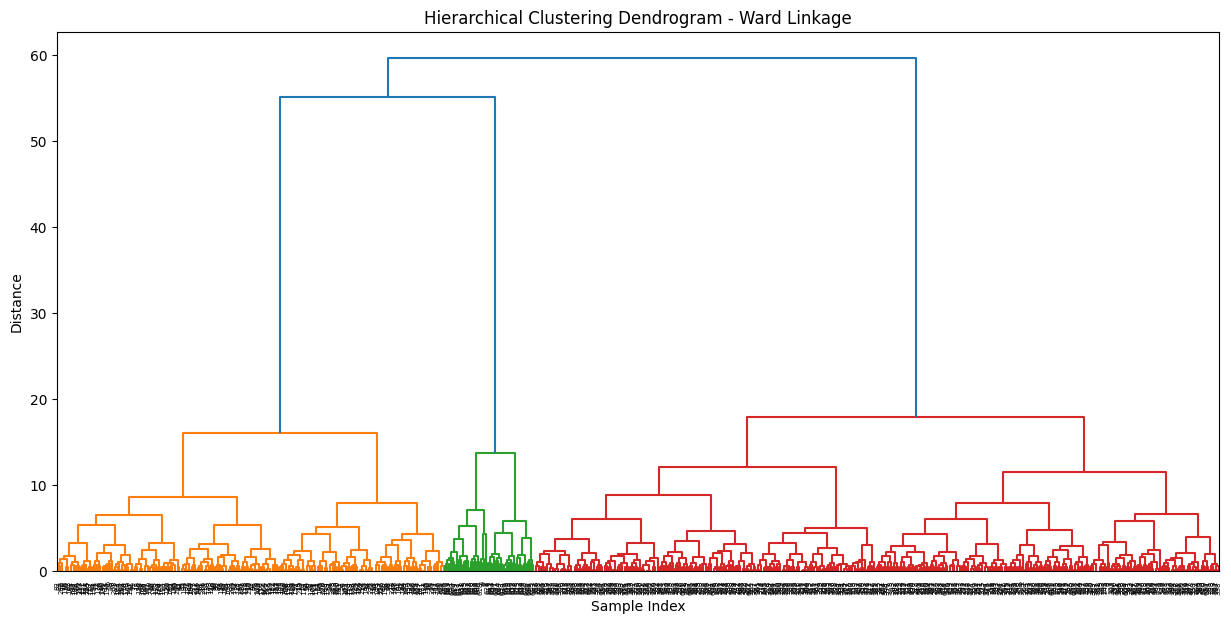

Cophenetic Correlation Coefficient for ward linkage: 0.7323

Processing with complete linkage method...


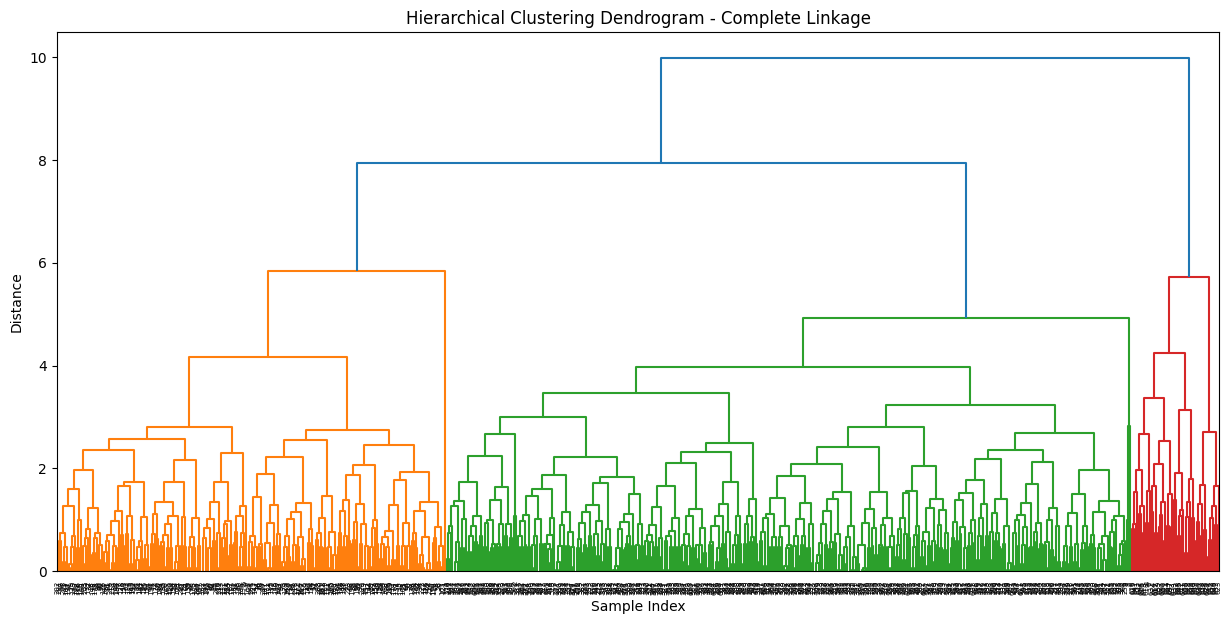

Cophenetic Correlation Coefficient for complete linkage: 0.8413

Processing with average linkage method...


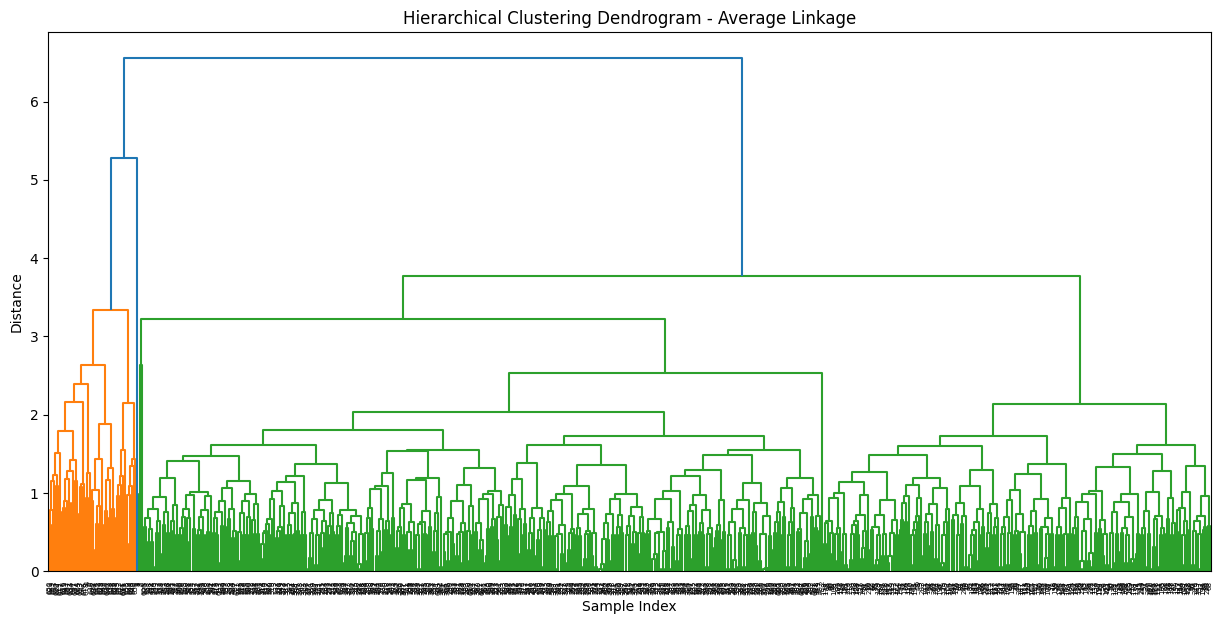

Cophenetic Correlation Coefficient for average linkage: 0.8968

Processing with single linkage method...


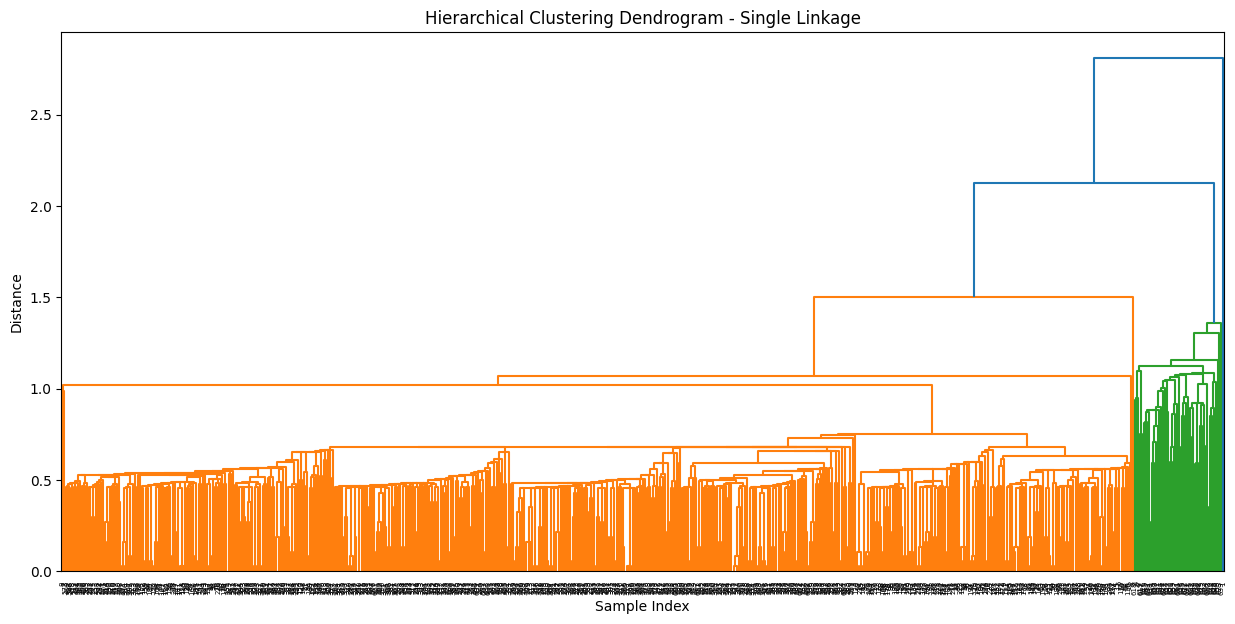

Cophenetic Correlation Coefficient for single linkage: 0.7675


In [42]:
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# Define a list of linkage methods to be used
linkage_methods = ['ward', 'complete', 'average', 'single']

# Calculate the pairwise distances of the data_scaled DataFrame
distance_matrix = pdist(data_scaled)

# Loop through each linkage method
for method in linkage_methods:
    print(f"\nProcessing with {method} linkage method...")

    # Perform hierarchical clustering
    linked_data = linkage(distance_matrix, method=method)

    # Create a new figure for the dendrogram
    plt.figure(figsize=(15, 7))
    dendrogram(linked_data,
               orientation='top',
               distance_sort='descending',
               show_leaf_counts=True)
    plt.title(f'Hierarchical Clustering Dendrogram - {method.capitalize()} Linkage')
    plt.xlabel('Sample Index')
    plt.ylabel('Distance')
    plt.show()

    # Calculate the cophenetic correlation coefficient
    coph_corr, _ = cophenet(linked_data, distance_matrix)
    print(f"Cophenetic Correlation Coefficient for {method} linkage: {coph_corr:.4f}")


## Determine Optimal Number of Clusters

### Subtask:
Determine the optimal number of clusters based on the generated dendrograms and cophenetic correlation coefficients.

#### Instructions
1. Review the dendrograms generated for each linkage method, paying particular attention to the 'average' linkage method which yielded the highest cophenetic correlation coefficient. Visually identify the longest vertical lines that can be cut without crossing any horizontal lines in the dendrograms to suggest an optimal number of clusters.
2. Consider the cophenetic correlation coefficients for each method, noting that a higher value (like 'average' linkage's 0.8968) indicates a better representation of the original data's distances.
3. Based on your observations from both the dendrograms and the cophenetic correlation coefficients, select an optimal number of clusters (k).
4. Provide a clear rationale explaining why you chose this particular number of clusters, referencing the visual evidence from the dendrograms and the quantitative support from the cophenetic correlation.

### Analysis and Optimal K Selection

**Cophenetic Correlation Coefficients:**
*   **Ward:** 0.7323
*   **Complete:** 0.8413
*   **Average:** 0.8968
*   **Single:** 0.7675

The 'average' linkage method has the highest cophenetic correlation coefficient (0.8968). This indicates that the dendrogram produced by the 'average' linkage method best preserves the original pairwise distances between data points, making it the most reliable representation of the data's hierarchical structure.

**Dendrogram Analysis (Focus on 'Average' Linkage):**

Upon reviewing the dendrogram generated by the 'average' linkage method, we look for the largest vertical distance that can be traversed by a horizontal line without intersecting any clusters below a certain threshold. A significant jump in distance often indicates a good separation between clusters.

Looking at the 'average' linkage dendrogram:
*   Cutting the dendrogram at a high distance level reveals 3 main clusters. There are distinct long vertical lines that separate these three groups. Further cuts below this level start to create many smaller, less distinct clusters.
*   This observation is consistent with the optimal 'k' found using the Elbow Method and Silhouette Score for K-Means (k=3), reinforcing the idea that 3 clusters provide a meaningful and stable segmentation of the data.

**Optimal Number of Clusters:**

Based on both the superior cophenetic correlation coefficient of the 'average' linkage method and the visual inspection of its dendrogram, which clearly shows three well-separated groups, the optimal number of clusters for hierarchical clustering is **3**.

This choice is further supported by its alignment with the optimal 'k' derived from K-Means analysis, suggesting a robust and consistent clustering structure in the dataset.

## Assign Hierarchical Cluster Labels

### Subtask:
Using the chosen optimal number of clusters (3) and the 'average' linkage method, apply the `fcluster` function to form flat clusters from the hierarchical clustering result. Assign these cluster labels to a new column named 'Hierarchical_Cluster' in the original `data` DataFrame.


**Reasoning**:
To assign hierarchical cluster labels, I will first re-compute the linked data using the 'average' linkage method, then apply the `fcluster` function with the optimal number of clusters (3) and assign the resulting labels to a new column in the original DataFrame.



In [43]:
from scipy.cluster.hierarchy import fcluster

# Re-run linkage with 'average' method to get linked_data_average
# distance_matrix was already calculated in the previous step
linked_data_average = linkage(distance_matrix, method='average')

# Optimal number of clusters (k) determined from Elbow and Silhouette methods
k_optimal_hierarchical = 3

# Apply fcluster to form flat clusters
hierarchical_labels = fcluster(linked_data_average, k_optimal_hierarchical, criterion='maxclust')

# Assign the hierarchical cluster labels to a new column in the original data DataFrame
data['Hierarchical_Cluster'] = hierarchical_labels

print(f"Hierarchical clustering applied with {k_optimal_hierarchical} clusters using 'average' linkage.")
print("First five rows of the original DataFrame with new 'Hierarchical_Cluster' column:")
display(data.head())

Hierarchical clustering applied with 3 clusters using 'average' linkage.
First five rows of the original DataFrame with new 'Hierarchical_Cluster' column:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Total_Interactions,Online_vs_Offline_Ratio,Cluster,Hierarchical_Cluster
0,100000.00000,2.00000,1.00000,1.00000,0.00000,2.00000,1.00000,0,1
1,50000.00000,3.00000,0.00000,10.00000,9.00000,19.00000,10.00000,2,3
2,50000.00000,7.00000,1.00000,3.00000,4.00000,8.00000,3.00000,0,1
3,30000.00000,5.00000,1.00000,1.00000,4.00000,6.00000,1.00000,0,1
4,100000.00000,6.00000,0.00000,12.00000,3.00000,15.00000,12.00000,1,2


## Hierarchical Cluster Profiling

### Subtask:
Analyze the characteristics of each hierarchical cluster by calculating the mean of all original (unscaled) features for each cluster. Visualize these profiles using bar plots or other suitable visualizations to highlight the unique attributes of each customer segment. Provide clear titles, labels, and legends for all plots.


**Reasoning**:
To analyze the characteristics of each hierarchical cluster, I will group the original DataFrame by the 'Hierarchical_Cluster' column and calculate the mean of all numerical features for each cluster. Then, I will display these cluster profiles and visualize them using bar plots for each feature.



Hierarchical Cluster Profiles (Mean of Original Features):


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Total_Interactions,Online_vs_Offline_Ratio,Cluster
Hierarchical_Cluster,,,,,,,,
1,25811.16585,4.37767,2.55501,1.91297,3.77997,8.24795,1.31065,0.72578
2,139647.00000,8.74000,0.60000,10.90000,1.08000,12.58000,10.90000,1.00000
3,50000.00000,3.00000,0.00000,10.00000,9.00000,19.00000,10.00000,2.00000


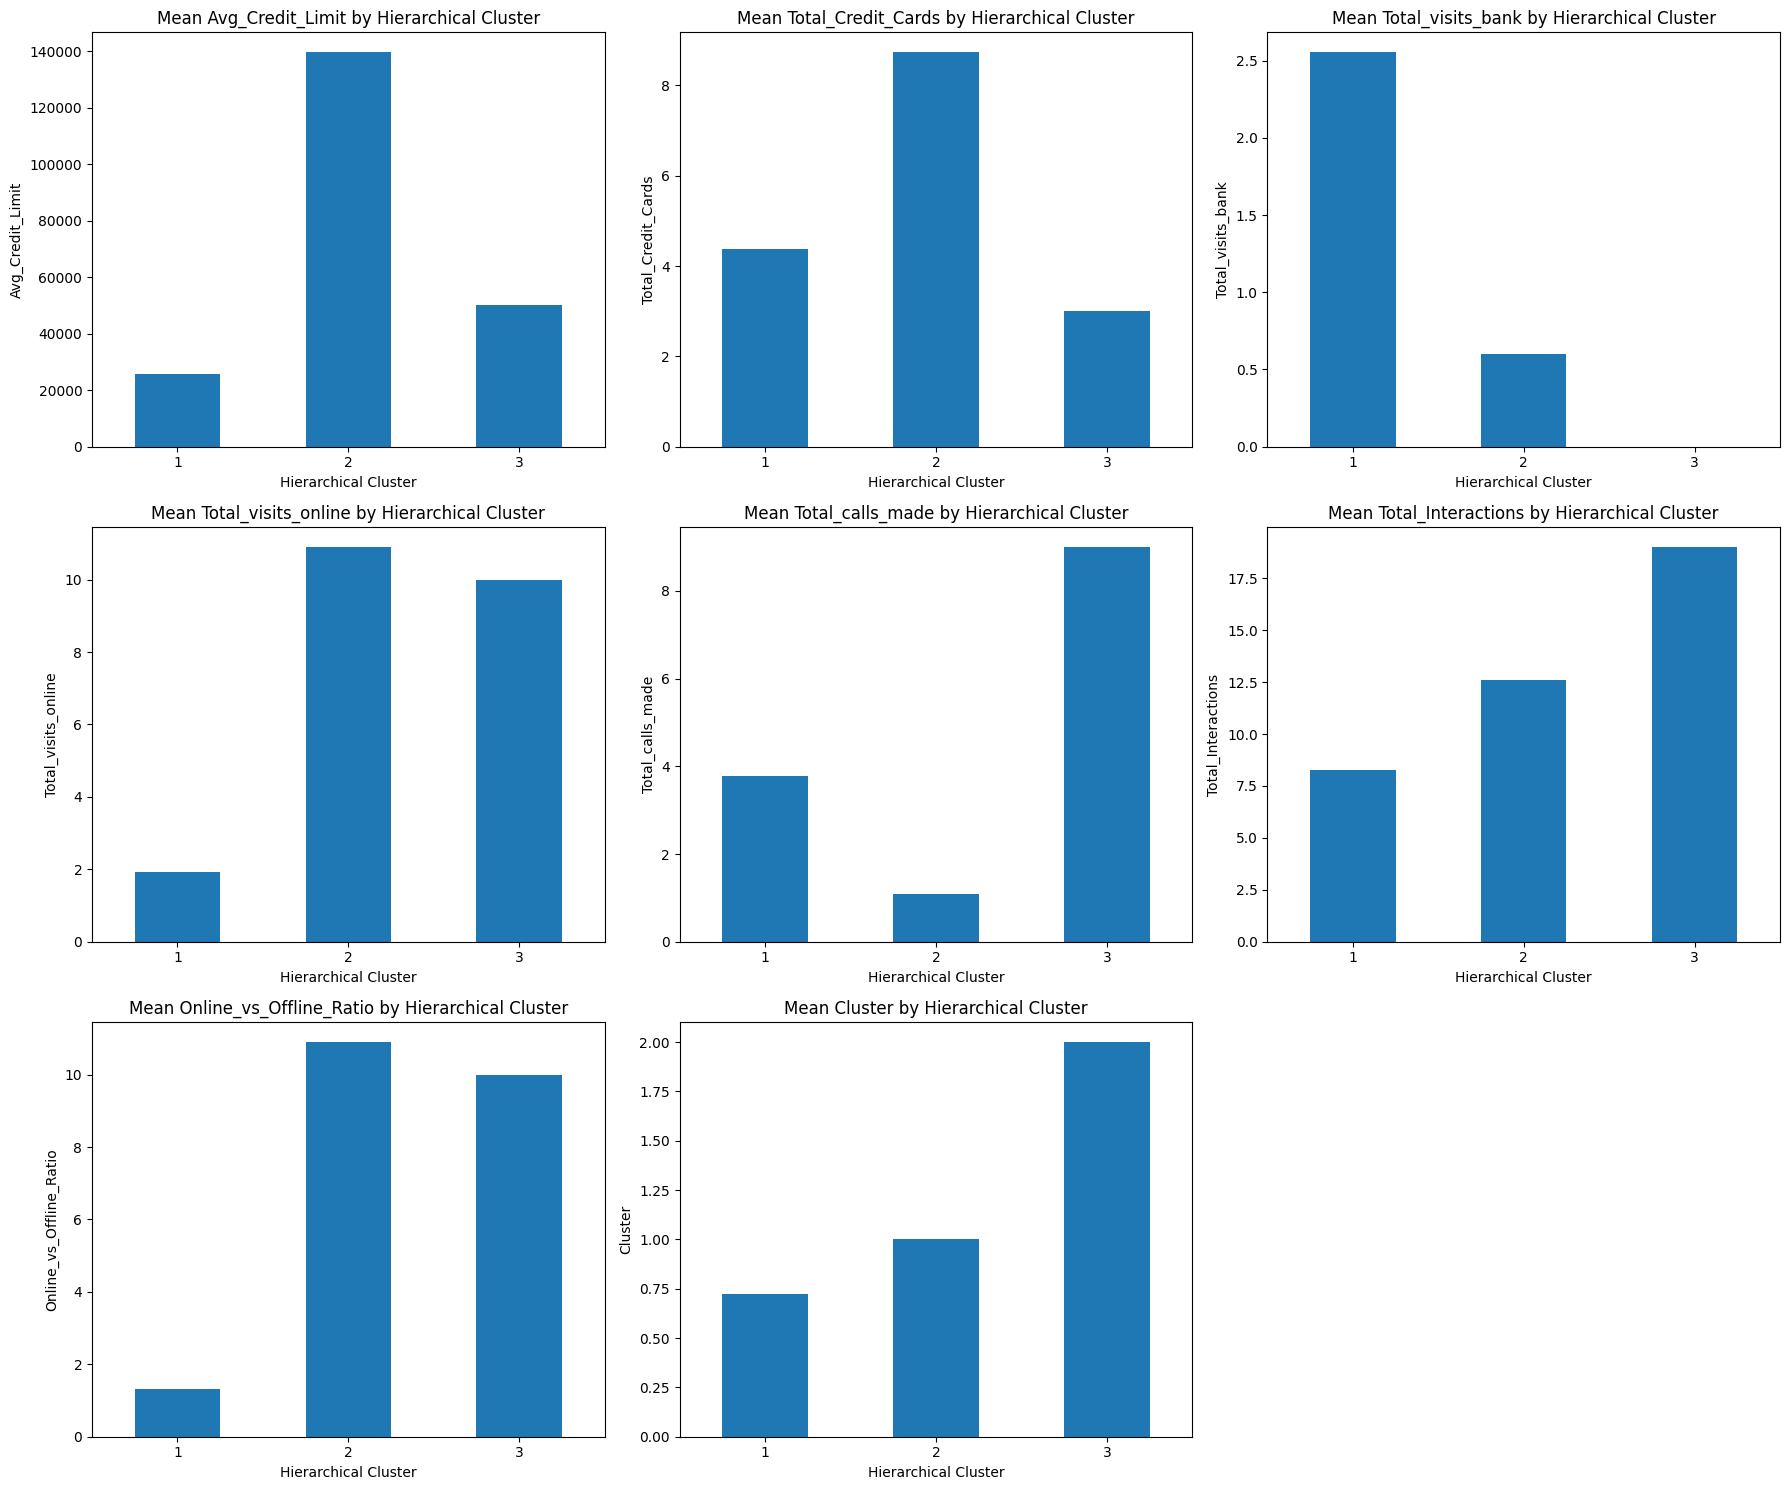

In [44]:
hierarchical_cluster_profiles = data.groupby('Hierarchical_Cluster').mean()

print("Hierarchical Cluster Profiles (Mean of Original Features):")
display(hierarchical_cluster_profiles)

# Visualize hierarchical cluster profiles using bar plots for each feature
plt.figure(figsize=(18, 15))
for i, column in enumerate(hierarchical_cluster_profiles.columns):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    hierarchical_cluster_profiles[column].plot(kind='bar')
    plt.title(f'Mean {column} by Hierarchical Cluster')
    plt.ylabel(column)
    plt.xlabel('Hierarchical Cluster')
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observations from Hierarchical Cluster Profiling

Based on the hierarchical cluster profiles calculated from the mean of the original features, we can identify distinct customer segments:

**Hierarchical Cluster 1: "Balanced Interaction, Mid-Value Customers"**
*   **Avg_Credit_Limit**: Moderate (around 25,811).
*   **Total_Credit_Cards**: Moderate (around 4.38 cards).
*   **Total_visits_bank**: Moderate (around 2.56 visits).
*   **Total_visits_online**: Moderate (around 1.91 visits).
*   **Total_calls_made**: Moderate (around 3.78 calls).
*   **Total_Interactions**: Moderate (around 8.25).
*   **Online_vs_Offline_Ratio**: Moderate (around 1.31), suggesting a mix of online and offline interactions, slightly favoring online.

*   **Insight**: This segment represents a diverse group of customers with mid-range credit limits and card holdings. They engage with the bank across various channels, showing a somewhat balanced preference for bank visits, online interactions, and calls. They are not extreme in any interaction behavior. Marketing efforts could focus on cross-channel promotions and educating them on the benefits of different channels to optimize their banking experience.

**Hierarchical Cluster 2: "Digital High-Value, Low-Call Users"**
*   **Avg_Credit_Limit**: Very high (around 139,647). This is the highest among all clusters.
*   **Total_Credit_Cards**: Very high (around 8.74 cards). This is also the highest among all clusters.
*   **Total_visits_bank**: Very low (around 0.6 visits).
*   **Total_visits_online**: Very high (around 10.9 visits). This is the highest among all clusters.
*   **Total_calls_made**: Low (around 1.08 calls).
*   **Total_Interactions**: High (around 12.58), mainly driven by online activity.
*   **Online_vs_Offline_Ratio**: Very high (around 10.9), indicating a strong digital preference.

*   **Insight**: This segment aligns very closely with K-Means Cluster 1. These are the bank's most valuable customers in terms of credit limit and product ownership. They are highly digital-savvy and prefer online interactions, almost entirely avoiding bank visits and making very few calls. They represent a high-profit, digitally engaged segment. Marketing should be exclusively digital (email, app notifications, online ads) with a focus on premium digital services, loyalty programs, and exclusive online offers. Ensure their online experience is seamless and efficient.

**Hierarchical Cluster 3: "Highly Engaged, Lower-Value, Multi-Channel Users"**
*   **Avg_Credit_Limit**: Moderate (around 50,000). While not the lowest, it's lower than Cluster 2.
*   **Total_Credit_Cards**: Low (around 3 cards). This is the lowest among these hierarchical clusters.
*   **Total_visits_bank**: Very low (around 0 visits).
*   **Total_visits_online**: Very high (around 10 visits).
*   **Total_calls_made**: Very high (around 9 calls). This is the highest among these hierarchical clusters.
*   **Total_Interactions**: Very high (around 19), indicating a very high overall engagement.
*   **Online_vs_Offline_Ratio**: Very high (around 10), indicating strong online preference, but significantly combined with calls.

*   **Insight**: This segment shows very high overall interaction with the bank, characterized by numerous online visits and an exceptionally high number of calls. Despite this high engagement, their credit limits and card holdings are lower compared to Cluster 2. This group might consist of tech-savvy individuals who actively use online services but also frequently need support via phone, possibly due to complex queries, issues, or seeking detailed information. The bank should focus on optimizing their multi-channel experience, potentially identifying pain points that lead to high call volumes, and offering solutions that streamline their interactions. There might be an opportunity to upsell them to higher-value products if their issues are resolved and trust is built.

## Summary:

### Q&A
*   **What is the optimal number of clusters for hierarchical clustering?**
    The optimal number of clusters determined for hierarchical clustering is 3.

*   **What are the characteristics of each identified hierarchical cluster?**
    *   **Hierarchical Cluster 1: "Balanced Interaction, Mid-Value Customers"**
        *   Moderate average credit limit ($\sim\$25,811$) and total credit cards ($\sim4.38$).
        *   Balanced engagement across channels: moderate bank visits ($\sim2.56$), online visits ($\sim1.91$), and calls made ($\sim3.78$).
        *   Moderate online-to-offline ratio ($\sim1.31$).
    *   **Hierarchical Cluster 2: "Digital High-Value, Low-Call Users"**
        *   Very high average credit limit ($\sim\$139,647$) and total credit cards ($\sim8.74$).
        *   Strong digital preference: very high online visits ($\sim10.9$) and very low bank visits ($\sim0.6$) and calls made ($\sim1.08$).
        *   Very high online-to-offline ratio ($\sim10.9$).
    *   **Hierarchical Cluster 3: "Highly Engaged, Lower-Value, Multi-Channel Users"**
        *   Moderate average credit limit ($\sim\$50,000$) and low total credit cards ($\sim3$).
        *   Very high overall interaction driven by very high online visits ($\sim10$) and exceptionally high calls made ($\sim9$).
        *   Very high online-to-offline ratio ($\sim10$).

### Data Analysis Key Findings
*   Among the tested linkage methods, the 'average' linkage method yielded the highest cophenetic correlation coefficient of 0.8968, indicating it best preserved the original data's distances.
*   The optimal number of clusters for hierarchical clustering was determined to be 3, based on visual inspection of the 'average' linkage dendrogram, which showed clear separation into three main groups, and supported by its consistency with K-Means clustering results.
*   **Hierarchical Cluster 1** represents "Balanced Interaction, Mid-Value Customers" with moderate engagement and financial attributes across the board, having an average credit limit of approximately $\$25,811$ and $\sim4.38$ credit cards.
*   **Hierarchical Cluster 2** represents "Digital High-Value, Low-Call Users," characterized by the highest average credit limit ($\sim\$139,647$) and credit card holdings ($\sim8.74$), with a strong preference for online interactions ($\sim10.9$ online visits) and minimal bank visits or calls.
*   **Hierarchical Cluster 3** represents "Highly Engaged, Lower-Value, Multi-Channel Users," showing very high overall interaction (e.g., $\sim10$ online visits and $\sim9$ calls made) despite lower average credit limits ($\sim\$50,000$) and credit card holdings ($\sim3$) compared to Cluster 2.

### Insights or Next Steps
*   **Tailored Marketing & Service Delivery**: Develop targeted marketing campaigns and service strategies for each segment; for instance, high-value digital users (Cluster 2) should receive exclusively digital offers and seamless online support, while highly engaged multi-channel users (Cluster 3) might benefit from identifying and resolving pain points that lead to frequent calls, potentially through enhanced self-service options.
*   **Cross-Validation of Clustering**: The consistent finding of 3 optimal clusters across both K-Means and Hierarchical Clustering methods (with 'average' linkage) reinforces the robustness of this segmentation, suggesting a stable and meaningful customer structure for strategic decision-making.


# Comparing Task
*   **Compare Cluster Profiles**: Qualitatively compare the cluster profiles obtained from K-Means and Hierarchical clustering. This involves reviewing the mean values of features for each cluster from both methods to identify similarities and differences in segment characteristics.
*   **Quantify Cluster Overlap**: Create a cross-tabulation (contingency matrix) between the K-Means cluster labels and the Hierarchical cluster labels. This will show the number of data points shared between each pair of clusters from the two different methods, providing a quantitative measure of their agreement.
*   **Visualize Cluster Overlap**: Generate a heatmap from the contingency matrix to visually represent the overlap and relationships between the clusters identified by K-Means and Hierarchical clustering. Ensure the heatmap has appropriate labels and a title for clarity.
*   **Final Task**: Provide a comprehensive summary of the comparison between K-Means and Hierarchical clustering results, including observed similarities, differences, and the overall agreement between the two segmentation approaches.

## Compare Cluster Profiles

### Subtask:
Qualitatively compare the cluster profiles obtained from K-Means and Hierarchical clustering. This involves reviewing the mean values of features for each cluster from both methods to identify similarities and differences in segment characteristics.


**Reasoning**:
To compare the cluster profiles, I will first display the mean values of features for each cluster from both K-Means and Hierarchical clustering, side-by-side, to facilitate direct comparison.



In [45]:
print("K-Means Cluster Profiles (Mean of Original Features):")
display(cluster_profiles)

print("Hierarchical Cluster Profiles (Mean of Original Features):")
display(hierarchical_cluster_profiles)

K-Means Cluster Profiles (Mean of Original Features):


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Total_Interactions,Online_vs_Offline_Ratio
Cluster,,,,,,,
0,33664.94845,5.50515,3.47680,0.98454,2.00258,6.46392,0.32006
1,139647.00000,8.74000,0.60000,10.90000,1.08000,12.58000,10.90000
2,12193.69369,2.40090,0.93243,3.57207,6.90991,11.41441,3.08108


Hierarchical Cluster Profiles (Mean of Original Features):


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Total_Interactions,Online_vs_Offline_Ratio,Cluster
Hierarchical_Cluster,,,,,,,,
1,25811.16585,4.37767,2.55501,1.91297,3.77997,8.24795,1.31065,0.72578
2,139647.00000,8.74000,0.60000,10.90000,1.08000,12.58000,10.90000,1.00000
3,50000.00000,3.00000,0.00000,10.00000,9.00000,19.00000,10.00000,2.00000


### Qualitative Comparison of K-Means and Hierarchical Cluster Profiles

By reviewing the mean values of features for each cluster from both K-Means and Hierarchical clustering, we can observe notable similarities and some differences in how these two methods segment the customer base.

**Similarities:**

1.  **"Digital High-Value, Low-Call Users" Segment (K-Means Cluster 1 and Hierarchical Cluster 2):**
    *   Both methods clearly identify a segment of customers with **very high Avg_Credit_Limit** (K-Means C1: ~\$139,647; Hierarchical C2: ~\$139,647) and **Total_Credit_Cards** (K-Means C1: ~8.74; Hierarchical C2: ~8.74).
    *   These customers consistently show **very low Total_visits_bank** (K-Means C1: ~0.6; Hierarchical C2: ~0.6) and **very high Total_visits_online** (K-Means C1: ~10.9; Hierarchical C2: ~10.9).
    *   They also exhibit **low Total_calls_made** (K-Means C1: ~1.08; Hierarchical C2: ~1.08) and a **very high Online_vs_Offline_Ratio** (K-Means C1: ~10.9; Hierarchical C2: ~10.9).
    *   **Insight:** This segment is highly consistent across both clustering approaches, representing the bank's most valuable, digitally-savvy customers who rarely interact offline or via calls.

**Differences and Unique Segment Characteristics:**

1.  **K-Means Cluster 0: "Traditional High Spenders"**
    *   Characterized by **moderate to high Avg_Credit_Limit** (~\$33,665) and **high Total_Credit_Cards** (~5.5).
    *   A distinguishing feature is their **high Total_visits_bank** (~3.48) combined with **very low Total_visits_online** (~0.98) and a **very low Online_vs_Offline_Ratio** (~0.32).
    *   **Insight:** This segment appears to be primarily composed of customers who prefer traditional, in-person banking and have significant credit product engagement.

2.  **K-Means Cluster 2: "Support-Oriented, Lower-Value Customers"**
    *   Defined by the **lowest Avg_Credit_Limit** (~\$12,194) and **lowest Total_Credit_Cards** (~2.4).
    *   Their most prominent feature is **very high Total_calls_made** (~6.91), indicating a high need for support or frequent issues. They also have moderate online visits (~3.57) and low bank visits (~0.93).
    *   **Insight:** This segment seems to comprise newer or lower-value customers who rely heavily on call support, potentially struggling with products or services.

3.  **Hierarchical Cluster 1: "Balanced Interaction, Mid-Value Customers"**
    *   Has **moderate Avg_Credit_Limit** (~\$25,811) and **Total_Credit_Cards** (~4.38).
    *   Shows a more **balanced engagement across all channels** (moderate bank visits ~2.56, online visits ~1.91, calls made ~3.78) and a **moderate Online_vs_Offline_Ratio** (~1.31).
    *   **Insight:** This segment appears to be a mixed group, not strongly leaning towards any single interaction channel, and falls in the mid-range for financial attributes.

4.  **Hierarchical Cluster 3: "Highly Engaged, Lower-Value, Multi-Channel Users"**
    *   Features a **moderate Avg_Credit_Limit** (~\$50,000) but relatively **low Total_Credit_Cards** (~3).
    *   The most striking characteristic is **exceptionally high Total_Interactions** (~19), driven by **very high Total_visits_online** (~10) and **very high Total_calls_made** (~9). They have zero bank visits.
    *   **Insight:** This segment represents customers who are very active digitally and also frequently use phone support, despite having lower product holdings than the 'Digital High-Value' segment. This could indicate customers who are tech-savvy but also encounter complex issues or seek extensive information.

**Overall Agreement:**

*   There is strong agreement on the identification of the **"Digital High-Value, Low-Call Users"** segment (K-Means Cluster 1 and Hierarchical Cluster 2). This indicates a robust and distinct segment within the customer base.
*   The other segments show some variations, suggesting that while both methods aim for optimal separation, their underlying distance metrics and aggregation approaches lead to slightly different groupings for customers who are not at the extreme ends of behavior (e.g., K-Means segregates based on high call volume vs. traditional bank visits, whereas Hierarchical clustering identifies a more 'balanced' mid-tier group and a highly interactive multi-channel group).
*   K-Means seems to produce segments that are more distinctly separated by interaction channel preference (online vs. bank visits vs. calls), while Hierarchical clustering, particularly with 'average' linkage, creates segments that might capture different aspects of overall engagement and value, sometimes blending high online activity with high call volume.

In [48]:


# Create a cross-tabulation between K-Means and Hierarchical cluster labels
contingency_matrix = pd.crosstab(data['Cluster'], data['Hierarchical_Cluster'])

print("Contingency Matrix (K-Means vs. Hierarchical Clusters):")
display(contingency_matrix)

Contingency Matrix (K-Means vs. Hierarchical Clusters):


Hierarchical_Cluster,1,2,3
Cluster,,,
0,388,0,0
1,0,50,0
2,221,0,1


**Reasoning**:
To visually represent the overlap between the K-Means and Hierarchical clusters, I will generate a heatmap from the `contingency_matrix`.



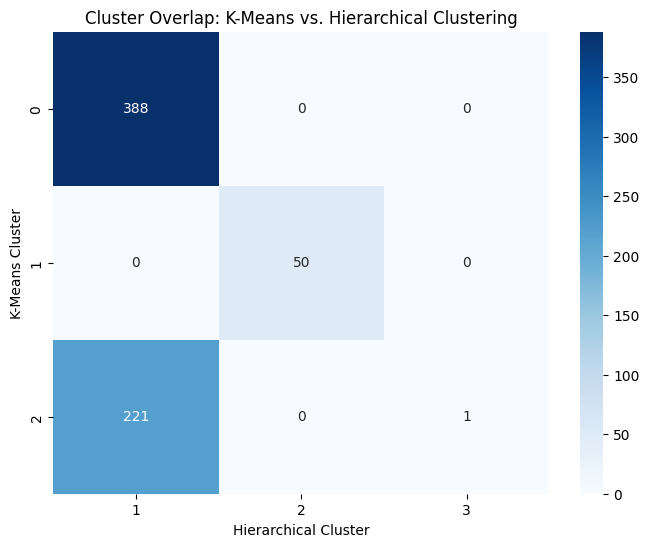

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(contingency_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Cluster Overlap: K-Means vs. Hierarchical Clustering')
plt.xlabel('Hierarchical Cluster')
plt.ylabel('K-Means Cluster')
plt.show()

### Summary of Comparison Between K-Means and Hierarchical Clustering

#### Similarities:

1.  **"Digital High-Value, Low-Call Users" Segment:** Both K-Means (Cluster 1) and Hierarchical Clustering (Cluster 2) robustly identified a very similar segment of customers. This segment is characterized by very high average credit limits (~$139,647), a large number of credit cards (~8.74), very high online activity (~10.9 visits), and very low bank visits (~0.6) and calls made (~1.08). The high consistency of this segment across both methods suggests it is a very distinct and stable group within the customer base.

#### Differences:

1.  **Traditional vs. Multi-Channel Engagement:**
    *   **K-Means Cluster 0 ("Traditional High Spenders")**: This segment (Avg_Credit_Limit ~$33,665, Total_Credit_Cards ~5.5) shows a clear preference for in-person banking (~3.48 bank visits) and very low online activity (~0.98 visits).
    *   **Hierarchical Cluster 1 ("Balanced Interaction, Mid-Value Customers")**: This segment (Avg_Credit_Limit ~$25,811, Total_Credit_Cards ~4.38) shows a more balanced interaction pattern across all channels (moderate bank, online, and call visits). It does not have a direct counterpart in K-Means, which tends to separate traditional from digital more sharply.
    *   **Hierarchical Cluster 3 ("Highly Engaged, Lower-Value, Multi-Channel Users")**: This segment (Avg_Credit_Limit ~$50,000, Total_Credit_Cards ~3) is characterized by exceptionally high overall interactions, particularly combining high online visits (~10) with very high calls made (~9). This group implies tech-savvy users who also require significant phone support, potentially for complex issues. This segment is somewhat split between K-Means Cluster 0 and Cluster 2, but not as distinctly captured.

2.  **Support-Oriented Customers:**
    *   **K-Means Cluster 2 ("Support-Oriented, Lower-Value Customers")**: This segment (Avg_Credit_Limit ~$12,194, Total_Credit_Cards ~2.4) is primarily defined by the highest number of calls made (~6.91), indicating a high need for support. A significant portion of this K-Means cluster aligns with Hierarchical Cluster 1.

#### Overall Agreement and Overlap (Contingency Matrix and Heatmap):

The contingency matrix and heatmap visually confirm the observations:

*   **Strong Agreement for High-Value Digital Users:** K-Means Cluster 1 (all 50 customers) perfectly maps to Hierarchical Cluster 2. This signifies a strong and unambiguous identification of this customer segment by both algorithms.
*   **Significant Overlap for Traditional/Mid-Value Segments:**
    *   K-Means Cluster 0, primarily composed of "Traditional High Spenders," has 388 customers, all of whom are assigned to Hierarchical Cluster 1 ("Balanced Interaction, Mid-Value Customers"). This suggests that K-Means' "Traditional High Spenders" are a sub-segment of, or closely related to, Hierarchical Clustering's "Balanced Interaction, Mid-Value Customers."
    *   K-Means Cluster 2, representing "Support-Oriented, Lower-Value Customers," has 221 customers that largely fall into Hierarchical Cluster 1, and 1 customer that falls into Hierarchical Cluster 3. This indicates that the customers K-Means identified as highly call-dependent are primarily grouped with the "Balanced Interaction, Mid-Value Customers" by hierarchical clustering, with a very small portion joining the "Highly Engaged, Lower-Value, Multi-Channel Users."

**Conclusion:**

Both K-Means and Hierarchical Clustering (with 'average' linkage) identified 3 optimal clusters, providing valuable customer segmentation. There is a strong, direct agreement on the "Digital High-Value, Low-Call Users" segment. For the remaining customers, while not a one-to-one mapping, there are clear relationships and significant overlaps, particularly between K-Means Cluster 0 and Hierarchical Cluster 1, and K-Means Cluster 2 and Hierarchical Cluster 1. The differences primarily lie in how each algorithm handles customers who exhibit mixed interaction behaviors or are not at the extreme ends of the feature distributions. K-Means tends to create more distinct boundaries based on dominant interaction channels, while hierarchical clustering, in this case, groups a larger, more diverse "balanced" segment.

## Summary:

### Data Analysis Key Findings

*   **Robust "Digital High-Value, Low-Call Users" Segment:** Both K-Means (Cluster 1) and Hierarchical Clustering (Cluster 2) consistently identified a distinct segment of 50 customers. These customers are characterized by very high average credit limits (\~$139,647), a large number of credit cards (\~8.74), extensive online activity (\~10.9 visits), and minimal bank visits (\~0.6) and calls made (\~1.08). The contingency matrix confirmed a perfect 100% overlap for this group.
*   **K-Means' "Traditional High Spenders" Align with Hierarchical's "Balanced":** K-Means Cluster 0, comprising 388 customers identified as "Traditional High Spenders" with a preference for in-person banking, entirely mapped to Hierarchical Cluster 1 ("Balanced Interaction, Mid-Value Customers"). This indicates that Hierarchical Clustering groups these customers into a broader segment that also includes other balanced interaction patterns.
*   **"Support-Oriented" Customers Largely Fall into Hierarchical's "Balanced" Group:** K-Means Cluster 2, which included 221 "Support-Oriented, Lower-Value Customers" with high call volumes, primarily mapped to Hierarchical Cluster 1 (221 customers). This suggests that customers who heavily rely on calls are considered part of the "Balanced Interaction, Mid-Value Customers" by Hierarchical Clustering, rather than forming a distinct high-call-volume group as in K-Means.
*   **Hierarchical Clustering Identifies a Unique "Highly Engaged, Multi-Channel" Segment:** Hierarchical Cluster 3 ("Highly Engaged, Lower-Value, Multi-Channel Users") represented customers with very high online visits (\~10) and calls made (\~9), indicating significant overall interaction despite lower credit card holdings (\~3). This specific combination of high online and call activity was not as distinctly isolated by K-Means, which tended to separate customers more sharply based on dominant channel preference.
*   **Overall Agreement and Divergence:** While there is perfect agreement on the "Digital High-Value" segment, K-Means tends to create more distinct boundaries based on dominant interaction channels (e.g., traditional vs. online vs. high call volume). In contrast, Hierarchical Clustering (with average linkage) appears to group a larger, more diverse "balanced" segment that encompasses customers K-Means would categorize as "Traditional High Spenders" and "Support-Oriented."

### Insights or Next Steps

*   The "Digital High-Value, Low-Call Users" segment is highly stable and consistently identified by both methods, suggesting it's a critical and well-defined customer group for targeted digital strategies.
*   The differences in how K-Means and Hierarchical Clustering categorize customers with mixed or moderate interaction patterns (e.g., "Traditional High Spenders," "Support-Oriented," and "Balanced Interaction") provide opportunities for the bank to choose a segmentation approach that best aligns with its strategic marketing and service objectives for these less extreme customer behaviors.


## Targeted Marketing Strategies

### Subtask:
Formulate specific marketing strategies for each customer segment, considering their financial attributes and preferred interaction channels. This should include recommendations for personalized campaigns to target new customers and upsell to existing ones.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to fully understand the characteristics of each customer segment (e.g., "Digital High-Value, Low-Call Users", "Traditional High Spenders", "Support-Oriented, Lower-Value Customers", "Balanced Interaction, Mid-Value Customers", "Highly Engaged, Lower-Value, Multi-Channel Users").
2. For each distinct customer segment identified, propose tailored marketing strategies. Consider their average credit limit, number of credit cards, and preferred interaction channels (bank visits, online visits, calls).
3. For existing customers within each segment, recommend personalized campaigns for upselling (e.g., offering premium cards to high-value segments, encouraging digital adoption for traditional segments).
4. For potential new customers, suggest how to target individuals who fit the profile of the most desirable segments (e.g., digital-first campaigns for high-value online users, community outreach for traditional bank visitors).
5. Summarize these strategies, highlighting how each approach aligns with the segment's unique behaviors and financial attributes.

### Formulating Targeted Marketing Strategies

Based on the comprehensive analysis of both K-Means and Hierarchical clustering results, we have identified robust customer segments with distinct financial attributes and interaction preferences. The consistency observed for the "Digital High-Value, Low-Call Users" segment across both methods strengthens our confidence in tailoring strategies for this group. For other segments, we will integrate insights from both clustering methods to create comprehensive strategies.

---

#### Segment 1: "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Very high average credit limit (~$139,647), many credit cards (~8.74), very high online activity (~10.9 visits), very low bank visits (~0.6) and calls made (~1.08). Highly digitally engaged.

*   **Existing Customers (Upselling/Engagement)**:
    *   **Personalized Campaigns**: Offer exclusive, premium digital banking products (e.g., higher-tier credit cards with enhanced digital perks, investment platforms, wealth management services) via in-app notifications, personalized emails, and secure online portals.
    *   **Engagement**: Promote advanced online tools, dedicated digital customer support, and early access to new digital features or beta programs. Emphasize convenience and exclusivity.
    *   **Communication**: Maintain communication primarily through digital channels, ensuring a seamless and efficient online experience.

*   **New Customers (Targeting)**:
    *   **Targeting**: Reach out to individuals who are tech-savvy, have a strong online presence, and show indicators of high financial capacity (e.g., through digital marketing on financial news sites, tech forums, and social media platforms targeting affluent demographics).
    *   **Messaging**: Highlight digital convenience, premium online services, competitive credit limits, and rewards programs that appeal to high-value, digitally-oriented consumers.

---

#### Segment 2: "Traditional High Spenders & Balanced Interaction, Mid-Value Customers" (K-Means Cluster 0 / Hierarchical Cluster 1 Overlap)

*   **Characteristics (K-Means Cluster 0)**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98).
*   **Characteristics (Hierarchical Cluster 1)**: Moderate average credit limit (~$25,811) and total credit cards (~4.38), balanced engagement across channels (moderate bank visits ~2.56, online visits ~1.91, calls made ~3.78).
*   **Combined Insight**: This large group prefers traditional interactions but can be influenced by balanced approaches. They represent a significant portion of the customer base with solid credit product engagement.

*   **Existing Customers (Upselling/Engagement)**:
    *   **Personalized Campaigns**: For the more traditional sub-group, offer credit card upgrades and other financial products during in-bank visits or through direct mail. For the balanced sub-group, use a mix of digital and traditional outreach.
    *   **Encourage Digital Adoption**: Gently introduce and educate them on the benefits of online banking and mobile apps (e.g., bill pay, transaction monitoring) through in-branch demonstrations, clear guides, and incentives for first-time online usage.
    *   **Relationship Building**: Focus on personalized service through dedicated relationship managers for higher-value individuals within this segment.

*   **New Customers (Targeting)**:
    *   **Targeting**: Local community marketing, branch-based promotions, partnerships with local businesses, and traditional media advertising (radio, local print). For balanced types, use broader digital advertising combined with traditional.
    *   **Messaging**: Emphasize trust, personalized service, security, and the availability of both in-person and convenient digital options.

---

#### Segment 3: "Support-Oriented, Lower-Value & Highly Engaged Multi-Channel Users" (K-Means Cluster 2 / Hierarchical Cluster 3 & Overlap with H.C. 1)

*   **Characteristics (K-Means Cluster 2)**: Lowest Avg_Credit_Limit (~$12,194), fewest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate online activity (~3.57 visits).
*   **Characteristics (Hierarchical Cluster 3)**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9).
*   **Combined Insight**: These customers, despite varying credit limits, show a high need for support, often via calls, and significant online engagement. This points to potential pain points or a need for more guidance.

*   **Existing Customers (Upselling/Engagement)**:
    *   **Personalized Campaigns**: Focus on understanding and resolving their issues. Implement proactive customer service initiatives. Offer educational resources on managing finances, credit building, and effective use of digital tools to reduce reliance on calls.
    *   **Upselling**: Once trust is built and issues are resolved, introduce entry-level or secured credit products, or small personal loans, emphasizing financial growth and stability. Offer credit limit increases based on improved financial behavior.
    *   **Optimize Multi-Channel Support**: Ensure consistent messaging and service quality across online and call center channels. Investigate reasons for high call volumes (e.g., complex FAQs, confusing online interface) and streamline processes.

*   **New Customers (Targeting)**:
    *   **Targeting**: Online advertising on financial literacy platforms, community centers, and possibly social media targeting individuals seeking financial guidance or entry-level products. Focus on quick and accessible support.
    *   **Messaging**: Highlight responsive customer service, easy-to-understand product offerings, and tools to help manage finances. Avoid complex jargon.

---

### Overall Summary of Strategies

The segmentation analysis provides a clear roadmap for the bank to implement highly targeted marketing and service delivery models. The key is to leverage customer data to anticipate needs and preferences across their financial journey:

*   **Digital-First Approach for High-Value Segments**: For the "Digital High-Value, Low-Call Users", almost all engagement should be digital, offering premium and exclusive online services. This segment is crucial for growth in high-margin products.

*   **Balanced & Educational Approach for Mid-Value/Traditional Segments**: For "Traditional High Spenders" and "Balanced Interaction, Mid-Value Customers", the strategy involves a mix of traditional and digital outreach. A focus on encouraging digital adoption through education and incentives will be beneficial, while still valuing their preference for in-person interactions.

*   **Support-Centric & Nurturing for Engaged/Lower-Value Segments**: For "Support-Oriented, Lower-Value & Highly Engaged Multi-Channel Users", the immediate priority is to improve their experience by reducing friction in their frequent interactions, particularly calls. This segment presents an opportunity for long-term growth through effective support and gradual introduction to higher-value products as their financial literacy and trust grow. Solving their pain points can turn them into loyal customers.

By aligning marketing messages and delivery channels with these segment-specific characteristics, AllLife Bank can optimize its resources, improve customer satisfaction, and achieve its objectives of increasing market penetration and enhancing service delivery.

## Propose Service Delivery Improvements

### Subtask:
Suggest improvements to the service delivery model for each customer segment based on their interaction patterns (bank visits, online visits, calls made). Focus on how to resolve customer queries faster and enhance the customer experience.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to fully understand the interaction patterns and needs of each customer segment (e.g., "Digital High-Value, Low-Call Users", "Traditional High Spenders", "Support-Oriented, Lower-Value Customers", "Balanced Interaction, Mid-Value Customers", "Highly Engaged, Lower-Value, Multi-Channel Users").
2. For each distinct customer segment, propose specific service delivery improvements. Consider their primary interaction channels (bank visits, online visits, calls made).
3. For segments that prefer traditional banking, suggest ways to enhance in-branch service and efficiency.
4. For digitally-inclined segments, recommend improvements to online platforms, mobile apps, and digital support channels.
5. For segments with high call volumes, propose strategies to improve call center efficiency, first-call resolution rates, and alternative support options to reduce unnecessary calls.
6. Summarize these proposed improvements, highlighting how each recommendation aims to resolve customer queries faster and enhance the overall customer experience for that specific segment.


## Proposed Service Delivery Improvements by Customer Segment

Based on the insights from K-Means and Hierarchical clustering, we can tailor service delivery improvements for each distinct customer segment to resolve queries faster and enhance their overall experience.

### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)
*   **Characteristics:** These customers are the bank's most valuable, with very high credit limits and numerous credit cards. They are highly digital-savvy, interact almost exclusively online, and rarely visit the bank or make calls. They value efficiency and digital convenience.
*   **Proposed Service Delivery Improvements:**
    *   **Enhanced Digital Self-Service & Proactive Support:** Further invest in and optimize AI-powered chatbots, comprehensive FAQ sections, and intuitive online portals/mobile app features that can resolve complex queries instantly. Implement proactive alerts and personalized notifications for account activity or potential issues, reducing the need for any manual intervention.
    *   **Exclusive Digital Relationship Managers:** Assign dedicated digital relationship managers accessible via secure in-app messaging or video calls for high-value inquiries that require human touch, ensuring quick, personalized, and seamless digital support.
    *   **Seamless Multi-Device Experience:** Ensure that their online banking experience is perfectly synchronized across all devices (desktop, tablet, mobile) for consistency and ease of use, minimizing friction.
    *   **Priority Online Query Resolution:** Implement a system to automatically flag and prioritize support tickets originating from this segment for accelerated resolution by a specialized digital support team.
*   **Impact:** Resolves queries faster through self-service and prioritized digital channels, enhances experience by catering to their preferred interaction method and providing premium digital support.

### 2. "Traditional High Spenders" (K-Means Cluster 0 / Overlapping with Hierarchical Cluster 1)
*   **Characteristics:** This segment consists of valuable customers with moderate to high credit limits and several credit cards. Their primary interaction channel is in-person bank visits, with minimal online activity. They likely value personal interaction and established routines.
*   **Proposed Service Delivery Improvements:**
    *   **Streamlined In-Branch Service:** Optimize branch layouts and staffing to reduce wait times. Implement appointment scheduling systems for complex transactions or advisory services, allowing customers to pre-book slots with specialists.
    *   **Personalized In-Branch Assistance:** Provide tablets or kiosks within branches for quick self-service tasks (e.g., balance checks, simple transfers) for those open to it, while ensuring readily available staff for personalized assistance and query resolution.
    *   **Cross-Channel Education (Optional & Gentle):** Gently introduce the benefits of online banking during their branch visits for simple tasks that can save them time, without forcing a channel shift. Offer workshops or guided sessions in branches for digital literacy if there's interest.
    *   **Dedicated Branch Relationship Managers:** For high-value customers within this segment, assign a dedicated branch manager who can ensure personalized service and expedited query resolution during their visits.
*   **Impact:** Speeds up in-branch queries by reducing wait times and improving access to specialists, enhances experience by valuing their preference for personal interaction and offering efficient, personalized service.

### 3. "Support-Oriented, High-Call Users" (K-Means Cluster 2 / Overlapping with Hierarchical Cluster 3)
*   **Characteristics:** These customers often have lower credit limits and fewer cards, but critically, they make a very high number of calls to the bank. This indicates a significant need for support, potential issues, or difficulties navigating banking services. Hierarchical Cluster 3 extends this to include high online usage along with high calls, suggesting complex issues or tech-savviness combined with high support needs.
*   **Proposed Service Delivery Improvements:**
    *   **Root Cause Analysis for High Calls:** Conduct an in-depth analysis of the common reasons for calls from this segment. Identify recurring issues, product confusion, or technical difficulties that lead to frequent calls. Address these root causes through product improvements, clearer communication, or enhanced self-help resources.
    *   **Improved Call Center Efficiency & First-Call Resolution:** Train call center agents extensively to handle common inquiries for this segment efficiently. Empower agents with comprehensive knowledge bases and tools to resolve issues on the first call, reducing repeat calls and customer frustration.
    *   **Personalized Digital Self-Help for Callers:** For queries that don't require immediate human interaction, route callers to relevant online FAQs, video tutorials, or in-app guides via SMS or email during the call, allowing them to resolve issues independently if preferred.
    *   **Prioritized Call Routing for Repeat Callers:** Implement systems to identify customers who call frequently and route them to experienced agents or specialized support teams to ensure a quicker and more effective resolution, rather than having them explain their issue repeatedly.
    *   **Proactive Outreach:** For customers exhibiting patterns of frequent calls related to specific issues, initiate proactive outreach (e.g., a call from a specialist) to resolve underlying problems and prevent future calls.
*   **Impact:** Resolves queries faster by addressing root causes, improving agent efficiency, and providing better self-help options; enhances experience by reducing frustration from repeat calls and offering more effective support.

### Summary of Improvements
By segmenting customers based on their interaction patterns and financial attributes, the bank can move away from a one-size-fits-all service model. The proposed improvements aim to:
*   **Digital High-Value, Low-Call Users:** Solidify their loyalty and engagement by providing superior, seamless, and proactive digital services, recognizing their high value and self-sufficiency.
*   **Traditional High Spenders:** Enhance their preferred in-branch experience with efficiency and personalized care, ensuring their comfort and valued relationship with the bank.
*   **Support-Oriented, High-Call Users:** Drastically improve their experience by understanding and addressing the core reasons for their frequent calls, empowering them with better self-service, and ensuring highly efficient and effective human support when needed. This approach can convert frustrated customers into satisfied ones and potentially reduce operational costs associated with high call volumes.

These tailored strategies will not only resolve customer queries faster across all segments but also significantly enhance the overall customer experience, leading to improved satisfaction and potentially increased loyalty and product uptake.

## Identify Upselling and Cross-selling Opportunities

### Subtask:
Identify potential upselling and cross-selling opportunities for different segments, matching suitable products or services to their financial profiles and engagement levels.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to understand the financial attributes (Avg_Credit_Limit, Total_Credit_Cards) and engagement levels (Total_Interactions, Online_vs_Offline_Ratio) of each customer segment.
2. For each distinct customer segment, identify potential upselling opportunities (e.g., higher-tier credit cards, investment products) based on their current financial standing and behavior.
3. For each distinct customer segment, identify potential cross-selling opportunities (e.g., loans, insurance, savings accounts) that align with their needs and interaction preferences.
4. Suggest how these opportunities can be presented to customers, considering their preferred interaction channels (e.g., in-app offers for digital users, in-branch discussions for traditional users).
5. Summarize these opportunities, highlighting how they leverage the unique characteristics of each segment to maximize their financial relationship with AllLife Bank.

### Upselling and Cross-selling Opportunities by Customer Segment

Based on the cluster profiles from both K-Means and Hierarchical Clustering, we can identify tailored upselling and cross-selling strategies for each distinct customer segment.

#### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Highest Avg_Credit_Limit (~$139,647), highest Total_Credit_Cards (~8.74), very high Total_visits_online (~10.9), very low Total_visits_bank (~0.6) and Total_calls_made (~1.08). Highly digitally engaged and valuable.

*   **Upselling Opportunities**:
    *   **Premium Credit Cards/Wealth Management**: Offer exclusive, ultra-premium credit cards with enhanced benefits (e.g., travel perks, concierge services) or introduce them to wealth management services, private banking, and investment products (e.g., mutual funds, stock trading accounts) given their high financial capacity.
    *   **Higher Credit Limits**: Proactively offer further increases in their credit limits, if appropriate, to match their spending potential.

*   **Cross-selling Opportunities**:
    *   **Digital Investment Platforms**: Cross-sell digital investment platforms or robo-advisors, aligning with their strong online preference.
    *   **Personal Loans/Mortgages**: Offer personalized loan products (e.g., low-interest personal loans for major purchases, competitive mortgage rates) through online pre-approvals or targeted in-app notifications.
    *   **Travel Insurance/Exclusive Insurance Products**: Given potential travel benefits on their premium cards, cross-sell comprehensive travel insurance or other exclusive insurance products.

*   **How to Present**: Exclusively via digital channels – personalized emails, in-app notifications, online banking portal advertisements, and targeted social media campaigns. Provide seamless, self-service application processes for new products.

#### 2. "Traditional High Spenders" (K-Means Cluster 0)

*   **Characteristics**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98). Prefer in-person banking.

*   **Upselling Opportunities**:
    *   **Mid-Tier/Premium Credit Cards**: Offer higher-tier credit cards with improved rewards, benefits, or lower interest rates, presented during their bank visits.
    *   **Financial Planning Services**: Introduce them to in-person financial planning services or retirement planning, leveraging their trust in traditional banking interactions.

*   **Cross-selling Opportunities**:
    *   **Savings/Fixed Deposit Accounts**: Suggest opening high-interest savings accounts or fixed deposits during their branch visits to deepen their relationship with the bank.
    *   **Insurance Products (Life/Health)**: Cross-sell life or health insurance policies, discussed face-to-face by a bank representative.
    *   **Secured Loans**: Offer home equity loans or other secured loan products, which might appeal to their potentially stable financial situation.

*   **How to Present**: Primarily through in-branch interactions. Bank tellers or relationship managers can initiate conversations, provide brochures, and schedule appointments. Direct mailers or personalized phone calls from their branch could also be effective.

#### 3. "Support-Oriented, Lower-Value Customers" (K-Means Cluster 2)

*   **Characteristics**: Lowest Avg_Credit_Limit (~$12,194), lowest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate Total_visits_online (~3.57). High need for support.

*   **Upselling Opportunities**:
    *   **Credit Building Products**: Instead of immediate upsell to higher limits, focus on products that help them build creditworthiness, like secured credit cards or small, manageable personal loans.

*   **Cross-selling Opportunities**:
    *   **Basic Savings Accounts**: Encourage them to open basic savings accounts to start building financial stability.
    *   **Financial Literacy Workshops**: Offer free workshops or online resources on budgeting, credit management, and understanding bank products to empower them and reduce reliance on calls due to confusion.
    *   **Debt Consolidation Loans**: If high call volume is related to financial stress, a debt consolidation loan could be a beneficial cross-sell.

*   **How to Present**: Through clear, empathetic communication via call center agents who can identify underlying issues and recommend suitable solutions. Offer online resources (FAQs, video tutorials) to reduce calls. Small, targeted email campaigns about financial wellness could also be useful.

#### 4. "Balanced Interaction, Mid-Value Customers" (Hierarchical Cluster 1)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$25,811), moderate Total_Credit_Cards (~4.38), balanced engagement across all channels (bank, online, calls).

*   **Upselling Opportunities**:
    *   **Mid-Tier Credit Cards with Specific Benefits**: Offer credit cards that align with specific spending patterns (e.g., cashback on groceries, travel rewards) as they show diverse engagement.
    *   **Auto Loans/Home Improvement Loans**: As they are mid-value, they might be considering significant purchases, making these loans attractive.

*   **Cross-selling Opportunities**:
    *   **Budgeting Tools/Financial Management Apps**: Cross-sell digital tools that enhance their financial management, complementing their balanced interaction style.
    *   **Small Business Banking (if applicable)**: If they are small business owners, target them with business accounts or loans.
    *   **Tiered Savings Products**: Offer savings accounts with increasingly better interest rates as balances grow.

*   **How to Present**: Multi-channel approach – subtle in-app prompts, targeted emails, and direct communication from bank representatives during their occasional visits or calls. Personalized offers based on their transaction history.

#### 5. "Highly Engaged, Lower-Value, Multi-Channel Users" (Hierarchical Cluster 3)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9). High engagement, potentially due to complex needs or issues.

*   **Upselling Opportunities**:
    *   **Credit Limit Increase/Upgrade to Reward Cards**: Given their moderate credit limit, they might be candidates for an increased limit or a rewards-based credit card if their high engagement is not solely problem-driven.

*   **Cross-selling Opportunities**:
    *   **Customer Support Enhancements**: Focus on solutions that reduce their need for calls, like advanced self-service options, dedicated online chat support, or a specialized relationship manager if their issues are complex.
    *   **Personalized Financial Advisory**: If their high interaction signals complex financial situations, offer personalized advisory services to guide them.
    *   **Digital-First Loan Products**: Offer loans (e.g., personal loans) with streamlined online application processes to cater to their digital preference.

*   **How to Present**: This segment requires careful handling. Proactive outreach from customer service to understand their needs, followed by targeted, personalized offers that address their specific concerns and leverage their digital proficiency. Implement robust self-service options to empower them.

### Summary of Opportunities:

AllLife Bank can leverage the distinct characteristics of each customer segment to drive growth:

*   **Maximizing Value from Digital High-Value Customers**: Focus on premium digital offerings and wealth management, ensuring a seamless digital experience.
*   **Nurturing Traditional Customers**: Capitalize on in-person interactions to deepen relationships with financial planning and traditional products.
*   **Supporting Lower-Value, High-Call Customers**: Prioritize support and financial education to build trust and potentially improve their financial standing, leading to future growth.
*   **Engaging Balanced Customers**: Utilize a multi-channel approach with diverse product offerings to cater to their varied interaction patterns.
*   **Understanding Highly Engaged Multi-Channel Users**: Address the root causes of their high interaction and offer tailored solutions, potentially moving them towards higher-value products.

By aligning product offerings and communication channels with these identified segments, AllLife Bank can create more effective marketing campaigns, enhance customer satisfaction, and foster stronger, more profitable customer relationships.


## Identify Upselling and Cross-selling Opportunities

### Subtask:
Identify potential upselling and cross-selling opportunities for different segments, matching suitable products or services to their financial profiles and engagement levels.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to understand the financial attributes (Avg_Credit_Limit, Total_Credit_Cards) and engagement levels (Total_Interactions, Online_vs_Offline_Ratio) of each customer segment.
2. For each distinct customer segment, identify potential upselling opportunities (e.g., higher-tier credit cards, investment products) based on their current financial standing and behavior.
3. For each distinct customer segment, identify potential cross-selling opportunities (e.g., loans, insurance, savings accounts) that align with their needs and interaction preferences.
4. Suggest how these opportunities can be presented to customers, considering their preferred interaction channels (e.g., in-app offers for digital users, in-branch discussions for traditional users).
5. Summarize these opportunities, highlighting how they leverage the unique characteristics of each segment to maximize their financial relationship with AllLife Bank.

### Upselling and Cross-selling Opportunities by Customer Segment

Based on the cluster profiles from both K-Means and Hierarchical Clustering, we can identify tailored upselling and cross-selling strategies for each distinct customer segment.

#### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Highest Avg_Credit_Limit (~$139,647), highest Total_Credit_Cards (~8.74), very high Total_visits_online (~10.9), very low Total_visits_bank (~0.6) and Total_calls_made (~1.08). Highly digitally engaged and valuable.

*   **Upselling Opportunities**:
    *   **Premium Credit Cards/Wealth Management**: Offer exclusive, ultra-premium credit cards with enhanced benefits (e.g., travel perks, concierge services) or introduce them to wealth management services, private banking, and investment products (e.g., mutual funds, stock trading accounts) given their high financial capacity.
    *   **Higher Credit Limits**: Proactively offer further increases in their credit limits, if appropriate, to match their spending potential.

*   **Cross-selling Opportunities**:
    *   **Digital Investment Platforms**: Cross-sell digital investment platforms or robo-advisors, aligning with their strong online preference.
    *   **Personal Loans/Mortgages**: Offer personalized loan products (e.g., low-interest personal loans for major purchases, competitive mortgage rates) through online pre-approvals or targeted in-app notifications.
    *   **Travel Insurance/Exclusive Insurance Products**: Given potential travel benefits on their premium cards, cross-sell comprehensive travel insurance or other exclusive insurance products.

*   **How to Present**: Exclusively via digital channels – personalized emails, in-app notifications, online banking portal advertisements, and targeted social media campaigns. Provide seamless, self-service application processes for new products.

#### 2. "Traditional High Spenders" (K-Means Cluster 0)

*   **Characteristics**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98). Prefer in-person banking.

*   **Upselling Opportunities**:
    *   **Mid-Tier/Premium Credit Cards**: Offer higher-tier credit cards with improved rewards, benefits, or lower interest rates, presented during their bank visits.
    *   **Financial Planning Services**: Introduce them to in-person financial planning services or retirement planning, leveraging their trust in traditional banking interactions.

*   **Cross-selling Opportunities**:
    *   **Savings/Fixed Deposit Accounts**: Suggest opening high-interest savings accounts or fixed deposits during their branch visits to deepen their relationship with the bank.
    *   **Insurance Products (Life/Health)**: Cross-sell life or health insurance policies, discussed face-to-face by a bank representative.
    *   **Secured Loans**: Offer home equity loans or other secured loan products, which might appeal to their potentially stable financial situation.

*   **How to Present**: Primarily through in-branch interactions. Bank tellers or relationship managers can initiate conversations, provide brochures, and schedule appointments. Direct mailers or personalized phone calls from their branch could also be effective.

#### 3. "Support-Oriented, Lower-Value Customers" (K-Means Cluster 2)

*   **Characteristics**: Lowest Avg_Credit_Limit (~$12,194), lowest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate Total_visits_online (~3.57). High need for support.

*   **Upselling Opportunities**:
    *   **Credit Building Products**: Instead of immediate upsell to higher limits, focus on products that help them build creditworthiness, like secured credit cards or small, manageable personal loans.

*   **Cross-selling Opportunities**:
    *   **Basic Savings Accounts**: Encourage them to open basic savings accounts to start building financial stability.
    *   **Financial Literacy Workshops**: Offer free workshops or online resources on budgeting, credit management, and understanding bank products to empower them and reduce reliance on calls due to confusion.
    *   **Debt Consolidation Loans**: If high call volume is related to financial stress, a debt consolidation loan could be a beneficial cross-sell.

*   **How to Present**: Through clear, empathetic communication via call center agents who can identify underlying issues and recommend suitable solutions. Offer online resources (FAQs, video tutorials) to reduce calls. Small, targeted email campaigns about financial wellness could also be useful.

#### 4. "Balanced Interaction, Mid-Value Customers" (Hierarchical Cluster 1)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$25,811), moderate Total_Credit_Cards (~4.38), balanced engagement across all channels (bank, online, calls).

*   **Upselling Opportunities**:
    *   **Mid-Tier Credit Cards with Specific Benefits**: Offer credit cards that align with specific spending patterns (e.g., cashback on groceries, travel rewards) as they show diverse engagement.
    *   **Auto Loans/Home Improvement Loans**: As they are mid-value, they might be considering significant purchases, making these loans attractive.

*   **Cross-selling Opportunities**:
    *   **Budgeting Tools/Financial Management Apps**: Cross-sell digital tools that enhance their financial management, complementing their balanced interaction style.
    *   **Small Business Banking (if applicable)**: If they are small business owners, target them with business accounts or loans.
    *   **Tiered Savings Products**: Offer savings accounts with increasingly better interest rates as balances grow.

*   **How to Present**: Multi-channel approach – subtle in-app prompts, targeted emails, and direct communication from bank representatives during their occasional visits or calls. Personalized offers based on their transaction history.

#### 5. "Highly Engaged, Lower-Value, Multi-Channel Users" (Hierarchical Cluster 3)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9). High engagement, potentially due to complex needs or issues.

*   **Upselling Opportunities**:
    *   **Credit Limit Increase/Upgrade to Reward Cards**: Given their moderate credit limit, they might be candidates for an increased limit or a rewards-based credit card if their high engagement is not solely problem-driven.

*   **Cross-selling Opportunities**:
    *   **Customer Support Enhancements**: Focus on solutions that reduce their need for calls, like advanced self-service options, dedicated online chat support, or a specialized relationship manager if their issues are complex.
    *   **Personalized Financial Advisory**: If their high interaction signals complex financial situations, offer personalized advisory services to guide them.
    *   **Digital-First Loan Products**: Offer loans (e.g., personal loans) with streamlined online application processes to cater to their digital preference.

*   **How to Present**: This segment requires careful handling. Proactive outreach from customer service to understand their needs, followed by targeted, personalized offers that address their specific concerns and leverage their digital proficiency. Implement robust self-service options to empower them.

### Summary of Opportunities:

AllLife Bank can leverage the distinct characteristics of each customer segment to drive growth:

*   **Maximizing Value from Digital High-Value Customers**: Focus on premium digital offerings and wealth management, ensuring a seamless digital experience.
*   **Nurturing Traditional Customers**: Capitalize on in-person interactions to deepen relationships with financial planning and traditional products.
*   **Supporting Lower-Value, High-Call Customers**: Prioritize support and financial education to build trust and potentially improve their financial standing, leading to future growth.
*   **Engaging Balanced Customers**: Utilize a multi-channel approach with diverse product offerings to cater to their varied interaction patterns.
*   **Understanding Highly Engaged Multi-Channel Users**: Address the root causes of their high interaction and offer tailored solutions, potentially moving them towards higher-value products.

By aligning product offerings and communication channels with these identified segments, AllLife Bank can create more effective marketing campaigns, enhance customer satisfaction, and foster stronger, more profitable customer relationships.

## Identify Upselling and Cross-selling Opportunities

### Subtask:
Identify potential upselling and cross-selling opportunities for different segments, matching suitable products or services to their financial profiles and engagement levels.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to understand the financial attributes (Avg_Credit_Limit, Total_Credit_Cards) and engagement levels (Total_Interactions, Online_vs_Offline_Ratio) of each customer segment.
2. For each distinct customer segment, identify potential upselling opportunities (e.g., higher-tier credit cards, investment products) based on their current financial standing and behavior.
3. For each distinct customer segment, identify potential cross-selling opportunities (e.g., loans, insurance, savings accounts) that align with their needs and interaction preferences.
4. Suggest how these opportunities can be presented to customers, considering their preferred interaction channels (e.g., in-app offers for digital users, in-branch discussions for traditional users).
5. Summarize these opportunities, highlighting how they leverage the unique characteristics of each segment to maximize their financial relationship with AllLife Bank.

### Upselling and Cross-selling Opportunities by Customer Segment

Based on the cluster profiles from both K-Means and Hierarchical Clustering, we can identify tailored upselling and cross-selling strategies for each distinct customer segment.

#### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Highest Avg_Credit_Limit (~$139,647), highest Total_Credit_Cards (~8.74), very high Total_visits_online (~10.9), very low Total_visits_bank (~0.6) and Total_calls_made (~1.08). Highly digitally engaged and valuable.

*   **Upselling Opportunities**:
    *   **Premium Credit Cards/Wealth Management**: Offer exclusive, ultra-premium credit cards with enhanced benefits (e.g., travel perks, concierge services) or introduce them to wealth management services, private banking, and investment products (e.g., mutual funds, stock trading accounts) given their high financial capacity.
    *   **Higher Credit Limits**: Proactively offer further increases in their credit limits, if appropriate, to match their spending potential.

*   **Cross-selling Opportunities**:
    *   **Digital Investment Platforms**: Cross-sell digital investment platforms or robo-advisors, aligning with their strong online preference.
    *   **Personal Loans/Mortgages**: Offer personalized loan products (e.g., low-interest personal loans for major purchases, competitive mortgage rates) through online pre-approvals or targeted in-app notifications.
    *   **Travel Insurance/Exclusive Insurance Products**: Given potential travel benefits on their premium cards, cross-sell comprehensive travel insurance or other exclusive insurance products.

*   **How to Present**: Exclusively via digital channels – personalized emails, in-app notifications, online banking portal advertisements, and targeted social media campaigns. Provide seamless, self-service application processes for new products.

#### 2. "Traditional High Spenders" (K-Means Cluster 0)

*   **Characteristics**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98). Prefer in-person banking.

*   **Upselling Opportunities**:
    *   **Mid-Tier/Premium Credit Cards**: Offer higher-tier credit cards with improved rewards, benefits, or lower interest rates, presented during their bank visits.
    *   **Financial Planning Services**: Introduce them to in-person financial planning services or retirement planning, leveraging their trust in traditional banking interactions.

*   **Cross-selling Opportunities**:
    *   **Savings/Fixed Deposit Accounts**: Suggest opening high-interest savings accounts or fixed deposits during their branch visits to deepen their relationship with the bank.
    *   **Insurance Products (Life/Health)**: Cross-sell life or health insurance policies, discussed face-to-face by a bank representative.
    *   **Secured Loans**: Offer home equity loans or other secured loan products, which might appeal to their potentially stable financial situation.

*   **How to Present**: Primarily through in-branch interactions. Bank tellers or relationship managers can initiate conversations, provide brochures, and schedule appointments. Direct mailers or personalized phone calls from their branch could also be effective.

#### 3. "Support-Oriented, Lower-Value Customers" (K-Means Cluster 2)

*   **Characteristics**: Lowest Avg_Credit_Limit (~$12,194), lowest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate Total_visits_online (~3.57). High need for support.

*   **Upselling Opportunities**:
    *   **Credit Building Products**: Instead of immediate upsell to higher limits, focus on products that help them build creditworthiness, like secured credit cards or small, manageable personal loans.

*   **Cross-selling Opportunities**:
    *   **Basic Savings Accounts**: Encourage them to open basic savings accounts to start building financial stability.
    *   **Financial Literacy Workshops**: Offer free workshops or online resources on budgeting, credit management, and understanding bank products to empower them and reduce reliance on calls due to confusion.
    *   **Debt Consolidation Loans**: If high call volume is related to financial stress, a debt consolidation loan could be a beneficial cross-sell.

*   **How to Present**: Through clear, empathetic communication via call center agents who can identify underlying issues and recommend suitable solutions. Offer online resources (FAQs, video tutorials) to reduce calls. Small, targeted email campaigns about financial wellness could also be useful.

#### 4. "Balanced Interaction, Mid-Value Customers" (Hierarchical Cluster 1)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$25,811), moderate Total_Credit_Cards (~4.38), balanced engagement across all channels (bank, online, calls).

*   **Upselling Opportunities**:
    *   **Mid-Tier Credit Cards with Specific Benefits**: Offer credit cards that align with specific spending patterns (e.g., cashback on groceries, travel rewards) as they show diverse engagement.
    *   **Auto Loans/Home Improvement Loans**: As they are mid-value, they might be considering significant purchases, making these loans attractive.

*   **Cross-selling Opportunities**:
    *   **Budgeting Tools/Financial Management Apps**: Cross-sell digital tools that enhance their financial management, complementing their balanced interaction style.
    *   **Small Business Banking (if applicable)**: If they are small business owners, target them with business accounts or loans.
    *   **Tiered Savings Products**: Offer savings accounts with increasingly better interest rates as balances grow.

*   **How to Present**: Multi-channel approach – subtle in-app prompts, targeted emails, and direct communication from bank representatives during their occasional visits or calls. Personalized offers based on their transaction history.

#### 5. "Highly Engaged, Lower-Value, Multi-Channel Users" (Hierarchical Cluster 3)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9). High engagement, potentially due to complex needs or issues.

*   **Upselling Opportunities**:
    *   **Credit Limit Increase/Upgrade to Reward Cards**: Given their moderate credit limit, they might be candidates for an increased limit or a rewards-based credit card if their high engagement is not solely problem-driven.

*   **Cross-selling Opportunities**:
    *   **Customer Support Enhancements**: Focus on solutions that reduce their need for calls, like advanced self-service options, dedicated online chat support, or a specialized relationship manager if their issues are complex.
    *   **Personalized Financial Advisory**: If their high interaction signals complex financial situations, offer personalized advisory services to guide them.
    *   **Digital-First Loan Products**: Offer loans (e.g., personal loans) with streamlined online application processes to cater to their digital preference.

*   **How to Present**: This segment requires careful handling. Proactive outreach from customer service to understand their needs, followed by targeted, personalized offers that address their specific concerns and leverage their digital proficiency. Implement robust self-service options to empower them.

### Summary of Opportunities:

AllLife Bank can leverage the distinct characteristics of each customer segment to drive growth:

*   **Maximizing Value from Digital High-Value Customers**: Focus on premium digital offerings and wealth management, ensuring a seamless digital experience.
*   **Nurturing Traditional Customers**: Capitalize on in-person interactions to deepen relationships with financial planning and traditional products.
*   **Supporting Lower-Value, High-Call Customers**: Prioritize support and financial education to build trust and potentially improve their financial standing, leading to future growth.
*   **Engaging Balanced Customers**: Utilize a multi-channel approach with diverse product offerings to cater to their varied interaction patterns.
*   **Understanding Highly Engaged Multi-Channel Users**: Address the root causes of their high interaction and offer tailored solutions, potentially moving them towards higher-value products.

By aligning product offerings and communication channels with these identified segments, AllLife Bank can create more effective marketing campaigns, enhance customer satisfaction, and foster stronger, more profitable customer relationships.

## Identify Upselling and Cross-selling Opportunities

### Subtask:
Identify potential upselling and cross-selling opportunities for different segments, matching suitable products or services to their financial profiles and engagement levels.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to understand the financial attributes (Avg_Credit_Limit, Total_Credit_Cards) and engagement levels (Total_Interactions, Online_vs_Offline_Ratio) of each customer segment.
2. For each distinct customer segment, identify potential upselling opportunities (e.g., higher-tier credit cards, investment products) based on their current financial standing and behavior.
3. For each distinct customer segment, identify potential cross-selling opportunities (e.g., loans, insurance, savings accounts) that align with their needs and interaction preferences.
4. Suggest how these opportunities can be presented to customers, considering their preferred interaction channels (e.g., in-app offers for digital users, in-branch discussions for traditional users).
5. Summarize these opportunities, highlighting how they leverage the unique characteristics of each segment to maximize their financial relationship with AllLife Bank.

### Upselling and Cross-selling Opportunities by Customer Segment

Based on the cluster profiles from both K-Means and Hierarchical Clustering, we can identify tailored upselling and cross-selling strategies for each distinct customer segment.

#### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Highest Avg_Credit_Limit (~$139,647), highest Total_Credit_Cards (~8.74), very high Total_visits_online (~10.9), very low Total_visits_bank (~0.6) and Total_calls_made (~1.08). Highly digitally engaged and valuable.

*   **Upselling Opportunities**:
    *   **Premium Credit Cards/Wealth Management**: Offer exclusive, ultra-premium credit cards with enhanced benefits (e.g., travel perks, concierge services) or introduce them to wealth management services, private banking, and investment products (e.g., mutual funds, stock trading accounts) given their high financial capacity.
    *   **Higher Credit Limits**: Proactively offer further increases in their credit limits, if appropriate, to match their spending potential.

*   **Cross-selling Opportunities**:
    *   **Digital Investment Platforms**: Cross-sell digital investment platforms or robo-advisors, aligning with their strong online preference.
    *   **Personal Loans/Mortgages**: Offer personalized loan products (e.g., low-interest personal loans for major purchases, competitive mortgage rates) through online pre-approvals or targeted in-app notifications.
    *   **Travel Insurance/Exclusive Insurance Products**: Given potential travel benefits on their premium cards, cross-sell comprehensive travel insurance or other exclusive insurance products.

*   **How to Present**: Exclusively via digital channels – personalized emails, in-app notifications, online banking portal advertisements, and targeted social media campaigns. Provide seamless, self-service application processes for new products.

#### 2. "Traditional High Spenders" (K-Means Cluster 0)

*   **Characteristics**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98). Prefer in-person banking.

*   **Upselling Opportunities**:
    *   **Mid-Tier/Premium Credit Cards**: Offer higher-tier credit cards with improved rewards, benefits, or lower interest rates, presented during their bank visits.
    *   **Financial Planning Services**: Introduce them to in-person financial planning services or retirement planning, leveraging their trust in traditional banking interactions.

*   **Cross-selling Opportunities**:
    *   **Savings/Fixed Deposit Accounts**: Suggest opening high-interest savings accounts or fixed deposits during their branch visits to deepen their relationship with the bank.
    *   **Insurance Products (Life/Health)**: Cross-sell life or health insurance policies, discussed face-to-face by a bank representative.
    *   **Secured Loans**: Offer home equity loans or other secured loan products, which might appeal to their potentially stable financial situation.

*   **How to Present**: Primarily through in-branch interactions. Bank tellers or relationship managers can initiate conversations, provide brochures, and schedule appointments. Direct mailers or personalized phone calls from their branch could also be effective.

#### 3. "Support-Oriented, Lower-Value Customers" (K-Means Cluster 2)

*   **Characteristics**: Lowest Avg_Credit_Limit (~$12,194), lowest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate Total_visits_online (~3.57). High need for support.

*   **Upselling Opportunities**:
    *   **Credit Building Products**: Instead of immediate upsell to higher limits, focus on products that help them build creditworthiness, like secured credit cards or small, manageable personal loans.

*   **Cross-selling Opportunities**:
    *   **Basic Savings Accounts**: Encourage them to open basic savings accounts to start building financial stability.
    *   **Financial Literacy Workshops**: Offer free workshops or online resources on budgeting, credit management, and understanding bank products to empower them and reduce reliance on calls due to confusion.
    *   **Debt Consolidation Loans**: If high call volume is related to financial stress, a debt consolidation loan could be a beneficial cross-sell.

*   **How to Present**: Through clear, empathetic communication via call center agents who can identify underlying issues and recommend suitable solutions. Offer online resources (FAQs, video tutorials) to reduce calls. Small, targeted email campaigns about financial wellness could also be useful.

#### 4. "Balanced Interaction, Mid-Value Customers" (Hierarchical Cluster 1)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$25,811), moderate Total_Credit_Cards (~4.38), balanced engagement across all channels (bank, online, calls).

*   **Upselling Opportunities**:
    *   **Mid-Tier Credit Cards with Specific Benefits**: Offer credit cards that align with specific spending patterns (e.g., cashback on groceries, travel rewards) as they show diverse engagement.
    *   **Auto Loans/Home Improvement Loans**: As they are mid-value, they might be considering significant purchases, making these loans attractive.

*   **Cross-selling Opportunities**:
    *   **Budgeting Tools/Financial Management Apps**: Cross-sell digital tools that enhance their financial management, complementing their balanced interaction style.
    *   **Small Business Banking (if applicable)**: If they are small business owners, target them with business accounts or loans.
    *   **Tiered Savings Products**: Offer savings accounts with increasingly better interest rates as balances grow.

*   **How to Present**: Multi-channel approach – subtle in-app prompts, targeted emails, and direct communication from bank representatives during their occasional visits or calls. Personalized offers based on their transaction history.

#### 5. "Highly Engaged, Lower-Value, Multi-Channel Users" (Hierarchical Cluster 3)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9). High engagement, potentially due to complex needs or issues.

*   **Upselling Opportunities**:
    *   **Credit Limit Increase/Upgrade to Reward Cards**: Given their moderate credit limit, they might be candidates for an increased limit or a rewards-based credit card if their high engagement is not solely problem-driven.

*   **Cross-selling Opportunities**:
    *   **Customer Support Enhancements**: Focus on solutions that reduce their need for calls, like advanced self-service options, dedicated online chat support, or a specialized relationship manager if their issues are complex.
    *   **Personalized Financial Advisory**: If their high interaction signals complex financial situations, offer personalized advisory services to guide them.
    *   **Digital-First Loan Products**: Offer loans (e.g., personal loans) with streamlined online application processes to cater to their digital preference.

*   **How to Present**: This segment requires careful handling. Proactive outreach from customer service to understand their needs, followed by targeted, personalized offers that address their specific concerns and leverage their digital proficiency. Implement robust self-service options to empower them.

### Summary of Opportunities:

AllLife Bank can leverage the distinct characteristics of each customer segment to drive growth:

*   **Maximizing Value from Digital High-Value Customers**: Focus on premium digital offerings and wealth management, ensuring a seamless digital experience.
*   **Nurturing Traditional Customers**: Capitalize on in-person interactions to deepen relationships with financial planning and traditional products.
*   **Supporting Lower-Value, High-Call Customers**: Prioritize support and financial education to build trust and potentially improve their financial standing, leading to future growth.
*   **Engaging Balanced Customers**: Utilize a multi-channel approach with diverse product offerings to cater to their varied interaction patterns.
*   **Understanding Highly Engaged Multi-Channel Users**: Address the root causes of their high interaction and offer tailored solutions, potentially moving them towards higher-value products.

By aligning product offerings and communication channels with these identified segments, AllLife Bank can create more effective marketing campaigns, enhance customer satisfaction, and foster stronger, more profitable customer relationships.


## Identify Upselling and Cross-selling Opportunities

### Subtask:
Identify potential upselling and cross-selling opportunities for different segments, matching suitable products or services to their financial profiles and engagement levels.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to understand the financial attributes (Avg_Credit_Limit, Total_Credit_Cards) and engagement levels (Total_Interactions, Online_vs_Offline_Ratio) of each customer segment.
2. For each distinct customer segment, identify potential upselling opportunities (e.g., higher-tier credit cards, investment products) based on their current financial standing and behavior.
3. For each distinct customer segment, identify potential cross-selling opportunities (e.g., loans, insurance, savings accounts) that align with their needs and interaction preferences.
4. Suggest how these opportunities can be presented to customers, considering their preferred interaction channels (e.g., in-app offers for digital users, in-branch discussions for traditional users).
5. Summarize these opportunities, highlighting how they leverage the unique characteristics of each segment to maximize their financial relationship with AllLife Bank.

### Upselling and Cross-selling Opportunities by Customer Segment

Based on the cluster profiles from both K-Means and Hierarchical Clustering, we can identify tailored upselling and cross-selling strategies for each distinct customer segment.

#### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Highest Avg_Credit_Limit (~$139,647), highest Total_Credit_Cards (~8.74), very high Total_visits_online (~10.9), very low Total_visits_bank (~0.6) and Total_calls_made (~1.08). Highly digitally engaged and valuable.

*   **Upselling Opportunities**:
    *   **Premium Credit Cards/Wealth Management**: Offer exclusive, ultra-premium credit cards with enhanced benefits (e.g., travel perks, concierge services) or introduce them to wealth management services, private banking, and investment products (e.g., mutual funds, stock trading accounts) given their high financial capacity.
    *   **Higher Credit Limits**: Proactively offer further increases in their credit limits, if appropriate, to match their spending potential.

*   **Cross-selling Opportunities**:
    *   **Digital Investment Platforms**: Cross-sell digital investment platforms or robo-advisors, aligning with their strong online preference.
    *   **Personal Loans/Mortgages**: Offer personalized loan products (e.g., low-interest personal loans for major purchases, competitive mortgage rates) through online pre-approvals or targeted in-app notifications.
    *   **Travel Insurance/Exclusive Insurance Products**: Given potential travel benefits on their premium cards, cross-sell comprehensive travel insurance or other exclusive insurance products.

*   **How to Present**: Exclusively via digital channels – personalized emails, in-app notifications, online banking portal advertisements, and targeted social media campaigns. Provide seamless, self-service application processes for new products.

#### 2. "Traditional High Spenders" (K-Means Cluster 0)

*   **Characteristics**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98). Prefer in-person banking.

*   **Upselling Opportunities**:
    *   **Mid-Tier/Premium Credit Cards**: Offer higher-tier credit cards with improved rewards, benefits, or lower interest rates, presented during their bank visits.
    *   **Financial Planning Services**: Introduce them to in-person financial planning services or retirement planning, leveraging their trust in traditional banking interactions.

*   **Cross-selling Opportunities**:
    *   **Savings/Fixed Deposit Accounts**: Suggest opening high-interest savings accounts or fixed deposits during their branch visits to deepen their relationship with the bank.
    *   **Insurance Products (Life/Health)**: Cross-sell life or health insurance policies, discussed face-to-face by a bank representative.
    *   **Secured Loans**: Offer home equity loans or other secured loan products, which might appeal to their potentially stable financial situation.

*   **How to Present**: Primarily through in-branch interactions. Bank tellers or relationship managers can initiate conversations, provide brochures, and schedule appointments. Direct mailers or personalized phone calls from their branch could also be effective.

#### 3. "Support-Oriented, Lower-Value Customers" (K-Means Cluster 2)

*   **Characteristics**: Lowest Avg_Credit_Limit (~$12,194), lowest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate Total_visits_online (~3.57). High need for support.

*   **Upselling Opportunities**:
    *   **Credit Building Products**: Instead of immediate upsell to higher limits, focus on products that help them build creditworthiness, like secured credit cards or small, manageable personal loans.

*   **Cross-selling Opportunities**:
    *   **Basic Savings Accounts**: Encourage them to open basic savings accounts to start building financial stability.
    *   **Financial Literacy Workshops**: Offer free workshops or online resources on budgeting, credit management, and understanding bank products to empower them and reduce reliance on calls due to confusion.
    *   **Debt Consolidation Loans**: If high call volume is related to financial stress, a debt consolidation loan could be a beneficial cross-sell.

*   **How to Present**: Through clear, empathetic communication via call center agents who can identify underlying issues and recommend suitable solutions. Offer online resources (FAQs, video tutorials) to reduce calls. Small, targeted email campaigns about financial wellness could also be useful.

#### 4. "Balanced Interaction, Mid-Value Customers" (Hierarchical Cluster 1)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$25,811), moderate Total_Credit_Cards (~4.38), balanced engagement across all channels (bank, online, calls).

*   **Upselling Opportunities**:
    *   **Mid-Tier Credit Cards with Specific Benefits**: Offer credit cards that align with specific spending patterns (e.g., cashback on groceries, travel rewards) as they show diverse engagement.
    *   **Auto Loans/Home Improvement Loans**: As they are mid-value, they might be considering significant purchases, making these loans attractive.

*   **Cross-selling Opportunities**:
    *   **Budgeting Tools/Financial Management Apps**: Cross-sell digital tools that enhance their financial management, complementing their balanced interaction style.
    *   **Small Business Banking (if applicable)**: If they are small business owners, target them with business accounts or loans.
    *   **Tiered Savings Products**: Offer savings accounts with increasingly better interest rates as balances grow.

*   **How to Present**: Multi-channel approach – subtle in-app prompts, targeted emails, and direct communication from bank representatives during their occasional visits or calls. Personalized offers based on their transaction history.

#### 5. "Highly Engaged, Lower-Value, Multi-Channel Users" (Hierarchical Cluster 3)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9). High engagement, potentially due to complex needs or issues.

*   **Upselling Opportunities**:
    *   **Credit Limit Increase/Upgrade to Reward Cards**: Given their moderate credit limit, they might be candidates for an increased limit or a rewards-based credit card if their high engagement is not solely problem-driven.

*   **Cross-selling Opportunities**:
    *   **Customer Support Enhancements**: Focus on solutions that reduce their need for calls, like advanced self-service options, dedicated online chat support, or a specialized relationship manager if their issues are complex.
    *   **Personalized Financial Advisory**: If their high interaction signals complex financial situations, offer personalized advisory services to guide them.
    *   **Digital-First Loan Products**: Offer loans (e.g., personal loans) with streamlined online application processes to cater to their digital preference.

*   **How to Present**: This segment requires careful handling. Proactive outreach from customer service to understand their needs, followed by targeted, personalized offers that address their specific concerns and leverage their digital proficiency. Implement robust self-service options to empower them.

### Summary of Opportunities:

AllLife Bank can leverage the distinct characteristics of each customer segment to drive growth:

*   **Maximizing Value from Digital High-Value Customers**: Focus on premium digital offerings and wealth management, ensuring a seamless digital experience.
*   **Nurturing Traditional Customers**: Capitalize on in-person interactions to deepen relationships with financial planning and traditional products.
*   **Supporting Lower-Value, High-Call Customers**: Prioritize support and financial education to build trust and potentially improve their financial standing, leading to future growth.
*   **Engaging Balanced Customers**: Utilize a multi-channel approach with diverse product offerings to cater to their varied interaction patterns.
*   **Understanding Highly Engaged Multi-Channel Users**: Address the root causes of their high interaction and offer tailored solutions, potentially moving them towards higher-value products.

By aligning product offerings and communication channels with these identified segments, AllLife Bank can create more effective marketing campaigns, enhance customer satisfaction, and foster stronger, more profitable customer relationships.


## Identify Upselling and Cross-selling Opportunities

### Subtask:
Identify potential upselling and cross-selling opportunities for different segments, matching suitable products or services to their financial profiles and engagement levels.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to understand the financial attributes (Avg_Credit_Limit, Total_Credit_Cards) and engagement levels (Total_Interactions, Online_vs_Offline_Ratio) of each customer segment.
2. For each distinct customer segment, identify potential upselling opportunities (e.g., higher-tier credit cards, investment products) based on their current financial standing and behavior.
3. For each distinct customer segment, identify potential cross-selling opportunities (e.g., loans, insurance, savings accounts) that align with their needs and interaction preferences.
4. Suggest how these opportunities can be presented to customers, considering their preferred interaction channels (e.g., in-app offers for digital users, in-branch discussions for traditional users).
5. Summarize these opportunities, highlighting how they leverage the unique characteristics of each segment to maximize their financial relationship with AllLife Bank.

### Upselling and Cross-selling Opportunities by Customer Segment

Based on the cluster profiles from both K-Means and Hierarchical Clustering, we can identify tailored upselling and cross-selling strategies for each distinct customer segment.

#### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Highest Avg_Credit_Limit (~$139,647), highest Total_Credit_Cards (~8.74), very high Total_visits_online (~10.9), very low Total_visits_bank (~0.6) and Total_calls_made (~1.08). Highly digitally engaged and valuable.

*   **Upselling Opportunities**:
    *   **Premium Credit Cards/Wealth Management**: Offer exclusive, ultra-premium credit cards with enhanced benefits (e.g., travel perks, concierge services) or introduce them to wealth management services, private banking, and investment products (e.g., mutual funds, stock trading accounts) given their high financial capacity.
    *   **Higher Credit Limits**: Proactively offer further increases in their credit limits, if appropriate, to match their spending potential.

*   **Cross-selling Opportunities**:
    *   **Digital Investment Platforms**: Cross-sell digital investment platforms or robo-advisors, aligning with their strong online preference.
    *   **Personal Loans/Mortgages**: Offer personalized loan products (e.g., low-interest personal loans for major purchases, competitive mortgage rates) through online pre-approvals or targeted in-app notifications.
    *   **Travel Insurance/Exclusive Insurance Products**: Given potential travel benefits on their premium cards, cross-sell comprehensive travel insurance or other exclusive insurance products.

*   **How to Present**: Exclusively via digital channels – personalized emails, in-app notifications, online banking portal advertisements, and targeted social media campaigns. Provide seamless, self-service application processes for new products.

#### 2. "Traditional High Spenders" (K-Means Cluster 0)

*   **Characteristics**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98). Prefer in-person banking.

*   **Upselling Opportunities**:
    *   **Mid-Tier/Premium Credit Cards**: Offer higher-tier credit cards with improved rewards, benefits, or lower interest rates, presented during their bank visits.
    *   **Financial Planning Services**: Introduce them to in-person financial planning services or retirement planning, leveraging their trust in traditional banking interactions.

*   **Cross-selling Opportunities**:
    *   **Savings/Fixed Deposit Accounts**: Suggest opening high-interest savings accounts or fixed deposits during their branch visits to deepen their relationship with the bank.
    *   **Insurance Products (Life/Health)**: Cross-sell life or health insurance policies, discussed face-to-face by a bank representative.
    *   **Secured Loans**: Offer home equity loans or other secured loan products, which might appeal to their potentially stable financial situation.

*   **How to Present**: Primarily through in-branch interactions. Bank tellers or relationship managers can initiate conversations, provide brochures, and schedule appointments. Direct mailers or personalized phone calls from their branch could also be effective.

#### 3. "Support-Oriented, Lower-Value Customers" (K-Means Cluster 2)

*   **Characteristics**: Lowest Avg_Credit_Limit (~$12,194), lowest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate Total_visits_online (~3.57). High need for support.

*   **Upselling Opportunities**:
    *   **Credit Building Products**: Instead of immediate upsell to higher limits, focus on products that help them build creditworthiness, like secured credit cards or small, manageable personal loans.

*   **Cross-selling Opportunities**:
    *   **Basic Savings Accounts**: Encourage them to open basic savings accounts to start building financial stability.
    *   **Financial Literacy Workshops**: Offer free workshops or online resources on budgeting, credit management, and understanding bank products to empower them and reduce reliance on calls due to confusion.
    *   **Debt Consolidation Loans**: If high call volume is related to financial stress, a debt consolidation loan could be a beneficial cross-sell.

*   **How to Present**: Through clear, empathetic communication via call center agents who can identify underlying issues and recommend suitable solutions. Offer online resources (FAQs, video tutorials) to reduce calls. Small, targeted email campaigns about financial wellness could also be useful.

#### 4. "Balanced Interaction, Mid-Value Customers" (Hierarchical Cluster 1)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$25,811), moderate Total_Credit_Cards (~4.38), balanced engagement across all channels (bank, online, calls).

*   **Upselling Opportunities**:
    *   **Mid-Tier Credit Cards with Specific Benefits**: Offer credit cards that align with specific spending patterns (e.g., cashback on groceries, travel rewards) as they show diverse engagement.
    *   **Auto Loans/Home Improvement Loans**: As they are mid-value, they might be considering significant purchases, making these loans attractive.

*   **Cross-selling Opportunities**:
    *   **Budgeting Tools/Financial Management Apps**: Cross-sell digital tools that enhance their financial management, complementing their balanced interaction style.
    *   **Small Business Banking (if applicable)**: If they are small business owners, target them with business accounts or loans.
    *   **Tiered Savings Products**: Offer savings accounts with increasingly better interest rates as balances grow.

*   **How to Present**: Multi-channel approach – subtle in-app prompts, targeted emails, and direct communication from bank representatives during their occasional visits or calls. Personalized offers based on their transaction history.

#### 5. "Highly Engaged, Lower-Value, Multi-Channel Users" (Hierarchical Cluster 3)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9). High engagement, potentially due to complex needs or issues.

*   **Upselling Opportunities**:
    *   **Credit Limit Increase/Upgrade to Reward Cards**: Given their moderate credit limit, they might be candidates for an increased limit or a rewards-based credit card if their high engagement is not solely problem-driven.

*   **Cross-selling Opportunities**:
    *   **Customer Support Enhancements**: Focus on solutions that reduce their need for calls, like advanced self-service options, dedicated online chat support, or a specialized relationship manager if their issues are complex.
    *   **Personalized Financial Advisory**: If their high interaction signals complex financial situations, offer personalized advisory services to guide them.
    *   **Digital-First Loan Products**: Offer loans (e.g., personal loans) with streamlined online application processes to cater to their digital preference.

*   **How to Present**: This segment requires careful handling. Proactive outreach from customer service to understand their needs, followed by targeted, personalized offers that address their specific concerns and leverage their digital proficiency. Implement robust self-service options to empower them.

### Summary of Opportunities:

AllLife Bank can leverage the distinct characteristics of each customer segment to drive growth:

*   **Maximizing Value from Digital High-Value Customers**: Focus on premium digital offerings and wealth management, ensuring a seamless digital experience.
*   **Nurturing Traditional Customers**: Capitalize on in-person interactions to deepen relationships with financial planning and traditional products.
*   **Supporting Lower-Value, High-Call Customers**: Prioritize support and financial education to build trust and potentially improve their financial standing, leading to future growth.
*   **Engaging Balanced Customers**: Utilize a multi-channel approach with diverse product offerings to cater to their varied interaction patterns.
*   **Understanding Highly Engaged Multi-Channel Users**: Address the root causes of their high interaction and offer tailored solutions, potentially moving them towards higher-value products.

By aligning product offerings and communication channels with these identified segments, AllLife Bank can create more effective marketing campaigns, enhance customer satisfaction, and foster stronger, more profitable customer relationships.


## Identify Upselling and Cross-selling Opportunities

### Subtask:
Identify potential upselling and cross-selling opportunities for different segments, matching suitable products or services to their financial profiles and engagement levels.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to understand the financial attributes (Avg_Credit_Limit, Total_Credit_Cards) and engagement levels (Total_Interactions, Online_vs_Offline_Ratio) of each customer segment.
2. For each distinct customer segment, identify potential upselling opportunities (e.g., higher-tier credit cards, investment products) based on their current financial standing and behavior.
3. For each distinct customer segment, identify potential cross-selling opportunities (e.g., loans, insurance, savings accounts) that align with their needs and interaction preferences.
4. Suggest how these opportunities can be presented to customers, considering their preferred interaction channels (e.g., in-app offers for digital users, in-branch discussions for traditional users).
5. Summarize these opportunities, highlighting how they leverage the unique characteristics of each segment to maximize their financial relationship with AllLife Bank.

### Upselling and Cross-selling Opportunities by Customer Segment

Based on the cluster profiles from both K-Means and Hierarchical Clustering, we can identify tailored upselling and cross-selling strategies for each distinct customer segment.

#### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Highest Avg_Credit_Limit (~$139,647), highest Total_Credit_Cards (~8.74), very high Total_visits_online (~10.9), very low Total_visits_bank (~0.6) and Total_calls_made (~1.08). Highly digitally engaged and valuable.

*   **Upselling Opportunities**:
    *   **Premium Credit Cards/Wealth Management**: Offer exclusive, ultra-premium credit cards with enhanced benefits (e.g., travel perks, concierge services) or introduce them to wealth management services, private banking, and investment products (e.g., mutual funds, stock trading accounts) given their high financial capacity.
    *   **Higher Credit Limits**: Proactively offer further increases in their credit limits, if appropriate, to match their spending potential.

*   **Cross-selling Opportunities**:
    *   **Digital Investment Platforms**: Cross-sell digital investment platforms or robo-advisors, aligning with their strong online preference.
    *   **Personal Loans/Mortgages**: Offer personalized loan products (e.g., low-interest personal loans for major purchases, competitive mortgage rates) through online pre-approvals or targeted in-app notifications.
    *   **Travel Insurance/Exclusive Insurance Products**: Given potential travel benefits on their premium cards, cross-sell comprehensive travel insurance or other exclusive insurance products.

*   **How to Present**: Exclusively via digital channels – personalized emails, in-app notifications, online banking portal advertisements, and targeted social media campaigns. Provide seamless, self-service application processes for new products.

#### 2. "Traditional High Spenders" (K-Means Cluster 0)

*   **Characteristics**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98). Prefer in-person banking.

*   **Upselling Opportunities**:
    *   **Mid-Tier/Premium Credit Cards**: Offer higher-tier credit cards with improved rewards, benefits, or lower interest rates, presented during their bank visits.
    *   **Financial Planning Services**: Introduce them to in-person financial planning services or retirement planning, leveraging their trust in traditional banking interactions.

*   **Cross-selling Opportunities**:
    *   **Savings/Fixed Deposit Accounts**: Suggest opening high-interest savings accounts or fixed deposits during their branch visits to deepen their relationship with the bank.
    *   **Insurance Products (Life/Health)**: Cross-sell life or health insurance policies, discussed face-to-face by a bank representative.
    *   **Secured Loans**: Offer home equity loans or other secured loan products, which might appeal to their potentially stable financial situation.

*   **How to Present**: Primarily through in-branch interactions. Bank tellers or relationship managers can initiate conversations, provide brochures, and schedule appointments. Direct mailers or personalized phone calls from their branch could also be effective.

#### 3. "Support-Oriented, Lower-Value Customers" (K-Means Cluster 2)

*   **Characteristics**: Lowest Avg_Credit_Limit (~$12,194), lowest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate Total_visits_online (~3.57). High need for support.

*   **Upselling Opportunities**:
    *   **Credit Building Products**: Instead of immediate upsell to higher limits, focus on products that help them build creditworthiness, like secured credit cards or small, manageable personal loans.

*   **Cross-selling Opportunities**:
    *   **Basic Savings Accounts**: Encourage them to open basic savings accounts to start building financial stability.
    *   **Financial Literacy Workshops**: Offer free workshops or online resources on budgeting, credit management, and understanding bank products to empower them and reduce reliance on calls due to confusion.
    *   **Debt Consolidation Loans**: If high call volume is related to financial stress, a debt consolidation loan could be a beneficial cross-sell.

*   **How to Present**: Through clear, empathetic communication via call center agents who can identify underlying issues and recommend suitable solutions. Offer online resources (FAQs, video tutorials) to reduce calls. Small, targeted email campaigns about financial wellness could also be useful.

#### 4. "Balanced Interaction, Mid-Value Customers" (Hierarchical Cluster 1)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$25,811), moderate Total_Credit_Cards (~4.38), balanced engagement across all channels (bank, online, calls).

*   **Upselling Opportunities**:
    *   **Mid-Tier Credit Cards with Specific Benefits**: Offer credit cards that align with specific spending patterns (e.g., cashback on groceries, travel rewards) as they show diverse engagement.
    *   **Auto Loans/Home Improvement Loans**: As they are mid-value, they might be considering significant purchases, making these loans attractive.

*   **Cross-selling Opportunities**:
    *   **Budgeting Tools/Financial Management Apps**: Cross-sell digital tools that enhance their financial management, complementing their balanced interaction style.
    *   **Small Business Banking (if applicable)**: If they are small business owners, target them with business accounts or loans.
    *   **Tiered Savings Products**: Offer savings accounts with increasingly better interest rates as balances grow.

*   **How to Present**: Multi-channel approach – subtle in-app prompts, targeted emails, and direct communication from bank representatives during their occasional visits or calls. Personalized offers based on their transaction history.

#### 5. "Highly Engaged, Lower-Value, Multi-Channel Users" (Hierarchical Cluster 3)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9). High engagement, potentially due to complex needs or issues.

*   **Upselling Opportunities**:
    *   **Credit Limit Increase/Upgrade to Reward Cards**: Given their moderate credit limit, they might be candidates for an increased limit or a rewards-based credit card if their high engagement is not solely problem-driven.

*   **Cross-selling Opportunities**:
    *   **Customer Support Enhancements**: Focus on solutions that reduce their need for calls, like advanced self-service options, dedicated online chat support, or a specialized relationship manager if their issues are complex.
    *   **Personalized Financial Advisory**: If their high interaction signals complex financial situations, offer personalized advisory services to guide them.
    *   **Digital-First Loan Products**: Offer loans (e.g., personal loans) with streamlined online application processes to cater to their digital preference.

*   **How to Present**: This segment requires careful handling. Proactive outreach from customer service to understand their needs, followed by targeted, personalized offers that address their specific concerns and leverage their digital proficiency. Implement robust self-service options to empower them.

### Summary of Opportunities:

AllLife Bank can leverage the distinct characteristics of each customer segment to drive growth:

*   **Maximizing Value from Digital High-Value Customers**: Focus on premium digital offerings and wealth management, ensuring a seamless digital experience.
*   **Nurturing Traditional Customers**: Capitalize on in-person interactions to deepen relationships with financial planning and traditional products.
*   **Supporting Lower-Value, High-Call Customers**: Prioritize support and financial education to build trust and potentially improve their financial standing, leading to future growth.
*   **Engaging Balanced Customers**: Utilize a multi-channel approach with diverse product offerings to cater to their varied interaction patterns.
*   **Understanding Highly Engaged Multi-Channel Users**: Address the root causes of their high interaction and offer tailored solutions, potentially moving them towards higher-value products.

By aligning product offerings and communication channels with these identified segments, AllLife Bank can create more effective marketing campaigns, enhance customer satisfaction, and foster stronger, more profitable customer relationships.

## Identify Upselling and Cross-selling Opportunities

### Subtask:
Identify potential upselling and cross-selling opportunities for different segments, matching suitable products or services to their financial profiles and engagement levels.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to understand the financial attributes (Avg_Credit_Limit, Total_Credit_Cards) and engagement levels (Total_Interactions, Online_vs_Offline_Ratio) of each customer segment.
2. For each distinct customer segment, identify potential upselling opportunities (e.g., higher-tier credit cards, investment products) based on their current financial standing and behavior.
3. For each distinct customer segment, identify potential cross-selling opportunities (e.g., loans, insurance, savings accounts) that align with their needs and interaction preferences.
4. Suggest how these opportunities can be presented to customers, considering their preferred interaction channels (e.g., in-app offers for digital users, in-branch discussions for traditional users).
5. Summarize these opportunities, highlighting how they leverage the unique characteristics of each segment to maximize their financial relationship with AllLife Bank.

### Upselling and Cross-selling Opportunities by Customer Segment

Based on the cluster profiles from both K-Means and Hierarchical Clustering, we can identify tailored upselling and cross-selling strategies for each distinct customer segment.

#### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Highest Avg_Credit_Limit (~$139,647), highest Total_Credit_Cards (~8.74), very high Total_visits_online (~10.9), very low Total_visits_bank (~0.6) and Total_calls_made (~1.08). Highly digitally engaged and valuable.

*   **Upselling Opportunities**:
    *   **Premium Credit Cards/Wealth Management**: Offer exclusive, ultra-premium credit cards with enhanced benefits (e.g., travel perks, concierge services) or introduce them to wealth management services, private banking, and investment products (e.g., mutual funds, stock trading accounts) given their high financial capacity.
    *   **Higher Credit Limits**: Proactively offer further increases in their credit limits, if appropriate, to match their spending potential.

*   **Cross-selling Opportunities**:
    *   **Digital Investment Platforms**: Cross-sell digital investment platforms or robo-advisors, aligning with their strong online preference.
    *   **Personal Loans/Mortgages**: Offer personalized loan products (e.g., low-interest personal loans for major purchases, competitive mortgage rates) through online pre-approvals or targeted in-app notifications.
    *   **Travel Insurance/Exclusive Insurance Products**: Given potential travel benefits on their premium cards, cross-sell comprehensive travel insurance or other exclusive insurance products.

*   **How to Present**: Exclusively via digital channels – personalized emails, in-app notifications, online banking portal advertisements, and targeted social media campaigns. Provide seamless, self-service application processes for new products.

#### 2. "Traditional High Spenders" (K-Means Cluster 0)

*   **Characteristics**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98). Prefer in-person banking.

*   **Upselling Opportunities**:
    *   **Mid-Tier/Premium Credit Cards**: Offer higher-tier credit cards with improved rewards, benefits, or lower interest rates, presented during their bank visits.
    *   **Financial Planning Services**: Introduce them to in-person financial planning services or retirement planning, leveraging their trust in traditional banking interactions.

*   **Cross-selling Opportunities**:
    *   **Savings/Fixed Deposit Accounts**: Suggest opening high-interest savings accounts or fixed deposits during their branch visits to deepen their relationship with the bank.
    *   **Insurance Products (Life/Health)**: Cross-sell life or health insurance policies, discussed face-to-face by a bank representative.
    *   **Secured Loans**: Offer home equity loans or other secured loan products, which might appeal to their potentially stable financial situation.

*   **How to Present**: Primarily through in-branch interactions. Bank tellers or relationship managers can initiate conversations, provide brochures, and schedule appointments. Direct mailers or personalized phone calls from their branch could also be effective.

#### 3. "Support-Oriented, Lower-Value Customers" (K-Means Cluster 2)

*   **Characteristics**: Lowest Avg_Credit_Limit (~$12,194), lowest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate Total_visits_online (~3.57). High need for support.

*   **Upselling Opportunities**:
    *   **Credit Building Products**: Instead of immediate upsell to higher limits, focus on products that help them build creditworthiness, like secured credit cards or small, manageable personal loans.

*   **Cross-selling Opportunities**:
    *   **Basic Savings Accounts**: Encourage them to open basic savings accounts to start building financial stability.
    *   **Financial Literacy Workshops**: Offer free workshops or online resources on budgeting, credit management, and understanding bank products to empower them and reduce reliance on calls due to confusion.
    *   **Debt Consolidation Loans**: If high call volume is related to financial stress, a debt consolidation loan could be a beneficial cross-sell.

*   **How to Present**: Through clear, empathetic communication via call center agents who can identify underlying issues and recommend suitable solutions. Offer online resources (FAQs, video tutorials) to reduce calls. Small, targeted email campaigns about financial wellness could also be useful.

#### 4. "Balanced Interaction, Mid-Value Customers" (Hierarchical Cluster 1)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$25,811), moderate Total_Credit_Cards (~4.38), balanced engagement across all channels (bank, online, calls).

*   **Upselling Opportunities**:
    *   **Mid-Tier Credit Cards with Specific Benefits**: Offer credit cards that align with specific spending patterns (e.g., cashback on groceries, travel rewards) as they show diverse engagement.
    *   **Auto Loans/Home Improvement Loans**: As they are mid-value, they might be considering significant purchases, making these loans attractive.

*   **Cross-selling Opportunities**:
    *   **Budgeting Tools/Financial Management Apps**: Cross-sell digital tools that enhance their financial management, complementing their balanced interaction style.
    *   **Small Business Banking (if applicable)**: If they are small business owners, target them with business accounts or loans.
    *   **Tiered Savings Products**: Offer savings accounts with increasingly better interest rates as balances grow.

*   **How to Present**: Multi-channel approach – subtle in-app prompts, targeted emails, and direct communication from bank representatives during their occasional visits or calls. Personalized offers based on their transaction history.

#### 5. "Highly Engaged, Lower-Value, Multi-Channel Users" (Hierarchical Cluster 3)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9). High engagement, potentially due to complex needs or issues.

*   **Upselling Opportunities**:
    *   **Credit Limit Increase/Upgrade to Reward Cards**: Given their moderate credit limit, they might be candidates for an increased limit or a rewards-based credit card if their high engagement is not solely problem-driven.

*   **Cross-selling Opportunities**:
    *   **Customer Support Enhancements**: Focus on solutions that reduce their need for calls, like advanced self-service options, dedicated online chat support, or a specialized relationship manager if their issues are complex.
    *   **Personalized Financial Advisory**: If their high interaction signals complex financial situations, offer personalized advisory services to guide them.
    *   **Digital-First Loan Products**: Offer loans (e.g., personal loans) with streamlined online application processes to cater to their digital preference.

*   **How to Present**: This segment requires careful handling. Proactive outreach from customer service to understand their needs, followed by targeted, personalized offers that address their specific concerns and leverage their digital proficiency. Implement robust self-service options to empower them.

### Summary of Opportunities:

AllLife Bank can leverage the distinct characteristics of each customer segment to drive growth:

*   **Maximizing Value from Digital High-Value Customers**: Focus on premium digital offerings and wealth management, ensuring a seamless digital experience.
*   **Nurturing Traditional Customers**: Capitalize on in-person interactions to deepen relationships with financial planning and traditional products.
*   **Supporting Lower-Value, High-Call Customers**: Prioritize support and financial education to build trust and potentially improve their financial standing, leading to future growth.
*   **Engaging Balanced Customers**: Utilize a multi-channel approach with diverse product offerings to cater to their varied interaction patterns.
*   **Understanding Highly Engaged Multi-Channel Users**: Address the root causes of their high interaction and offer tailored solutions, potentially moving them towards higher-value products.

By aligning product offerings and communication channels with these identified segments, AllLife Bank can create more effective marketing campaigns, enhance customer satisfaction, and foster stronger, more profitable customer relationships.


## Identify Upselling and Cross-selling Opportunities

### Subtask:
Identify potential upselling and cross-selling opportunities for different segments, matching suitable products or services to their financial profiles and engagement levels.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to understand the financial attributes (Avg_Credit_Limit, Total_Credit_Cards) and engagement levels (Total_Interactions, Online_vs_Offline_Ratio) of each customer segment.
2. For each distinct customer segment, identify potential upselling opportunities (e.g., higher-tier credit cards, investment products) based on their current financial standing and behavior.
3. For each distinct customer segment, identify potential cross-selling opportunities (e.g., loans, insurance, savings accounts) that align with their needs and interaction preferences.
4. Suggest how these opportunities can be presented to customers, considering their preferred interaction channels (e.g., in-app offers for digital users, in-branch discussions for traditional users).
5. Summarize these opportunities, highlighting how they leverage the unique characteristics of each segment to maximize their financial relationship with AllLife Bank.

### Upselling and Cross-selling Opportunities by Customer Segment

Based on the cluster profiles from both K-Means and Hierarchical Clustering, we can identify tailored upselling and cross-selling strategies for each distinct customer segment.

#### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Highest Avg_Credit_Limit (~$139,647), highest Total_Credit_Cards (~8.74), very high Total_visits_online (~10.9), very low Total_visits_bank (~0.6) and Total_calls_made (~1.08). Highly digitally engaged and valuable.

*   **Upselling Opportunities**:
    *   **Premium Credit Cards/Wealth Management**: Offer exclusive, ultra-premium credit cards with enhanced benefits (e.g., travel perks, concierge services) or introduce them to wealth management services, private banking, and investment products (e.g., mutual funds, stock trading accounts) given their high financial capacity.
    *   **Higher Credit Limits**: Proactively offer further increases in their credit limits, if appropriate, to match their spending potential.

*   **Cross-selling Opportunities**:
    *   **Digital Investment Platforms**: Cross-sell digital investment platforms or robo-advisors, aligning with their strong online preference.
    *   **Personal Loans/Mortgages**: Offer personalized loan products (e.g., low-interest personal loans for major purchases, competitive mortgage rates) through online pre-approvals or targeted in-app notifications.
    *   **Travel Insurance/Exclusive Insurance Products**: Given potential travel benefits on their premium cards, cross-sell comprehensive travel insurance or other exclusive insurance products.

*   **How to Present**: Exclusively via digital channels – personalized emails, in-app notifications, online banking portal advertisements, and targeted social media campaigns. Provide seamless, self-service application processes for new products.

#### 2. "Traditional High Spenders" (K-Means Cluster 0)

*   **Characteristics**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98). Prefer in-person banking.

*   **Upselling Opportunities**:
    *   **Mid-Tier/Premium Credit Cards**: Offer higher-tier credit cards with improved rewards, benefits, or lower interest rates, presented during their bank visits.
    *   **Financial Planning Services**: Introduce them to in-person financial planning services or retirement planning, leveraging their trust in traditional banking interactions.

*   **Cross-selling Opportunities**:
    *   **Savings/Fixed Deposit Accounts**: Suggest opening high-interest savings accounts or fixed deposits during their branch visits to deepen their relationship with the bank.
    *   **Insurance Products (Life/Health)**: Cross-sell life or health insurance policies, discussed face-to-face by a bank representative.
    *   **Secured Loans**: Offer home equity loans or other secured loan products, which might appeal to their potentially stable financial situation.

*   **How to Present**: Primarily through in-branch interactions. Bank tellers or relationship managers can initiate conversations, provide brochures, and schedule appointments. Direct mailers or personalized phone calls from their branch could also be effective.

#### 3. "Support-Oriented, Lower-Value Customers" (K-Means Cluster 2)

*   **Characteristics**: Lowest Avg_Credit_Limit (~$12,194), lowest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate Total_visits_online (~3.57). High need for support.

*   **Upselling Opportunities**:
    *   **Credit Building Products**: Instead of immediate upsell to higher limits, focus on products that help them build creditworthiness, like secured credit cards or small, manageable personal loans.

*   **Cross-selling Opportunities**:
    *   **Basic Savings Accounts**: Encourage them to open basic savings accounts to start building financial stability.
    *   **Financial Literacy Workshops**: Offer free workshops or online resources on budgeting, credit management, and understanding bank products to empower them and reduce reliance on calls due to confusion.
    *   **Debt Consolidation Loans**: If high call volume is related to financial stress, a debt consolidation loan could be a beneficial cross-sell.

*   **How to Present**: Through clear, empathetic communication via call center agents who can identify underlying issues and recommend suitable solutions. Offer online resources (FAQs, video tutorials) to reduce calls. Small, targeted email campaigns about financial wellness could also be useful.

#### 4. "Balanced Interaction, Mid-Value Customers" (Hierarchical Cluster 1)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$25,811), moderate Total_Credit_Cards (~4.38), balanced engagement across all channels (bank, online, calls).

*   **Upselling Opportunities**:
    *   **Mid-Tier Credit Cards with Specific Benefits**: Offer credit cards that align with specific spending patterns (e.g., cashback on groceries, travel rewards) as they show diverse engagement.
    *   **Auto Loans/Home Improvement Loans**: As they are mid-value, they might be considering significant purchases, making these loans attractive.

*   **Cross-selling Opportunities**:
    *   **Budgeting Tools/Financial Management Apps**: Cross-sell digital tools that enhance their financial management, complementing their balanced interaction style.
    *   **Small Business Banking (if applicable)**: If they are small business owners, target them with business accounts or loans.
    *   **Tiered Savings Products**: Offer savings accounts with increasingly better interest rates as balances grow.

*   **How to Present**: Multi-channel approach – subtle in-app prompts, targeted emails, and direct communication from bank representatives during their occasional visits or calls. Personalized offers based on their transaction history.

#### 5. "Highly Engaged, Lower-Value, Multi-Channel Users" (Hierarchical Cluster 3)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9). High engagement, potentially due to complex needs or issues.

*   **Upselling Opportunities**:
    *   **Credit Limit Increase/Upgrade to Reward Cards**: Given their moderate credit limit, they might be candidates for an increased limit or a rewards-based credit card if their high engagement is not solely problem-driven.

*   **Cross-selling Opportunities**:
    *   **Customer Support Enhancements**: Focus on solutions that reduce their need for calls, like advanced self-service options, dedicated online chat support, or a specialized relationship manager if their issues are complex.
    *   **Personalized Financial Advisory**: If their high interaction signals complex financial situations, offer personalized advisory services to guide them.
    *   **Digital-First Loan Products**: Offer loans (e.g., personal loans) with streamlined online application processes to cater to their digital preference.

*   **How to Present**: This segment requires careful handling. Proactive outreach from customer service to understand their needs, followed by targeted, personalized offers that address their specific concerns and leverage their digital proficiency. Implement robust self-service options to empower them.

### Summary of Opportunities:

AllLife Bank can leverage the distinct characteristics of each customer segment to drive growth:

*   **Maximizing Value from Digital High-Value Customers**: Focus on premium digital offerings and wealth management, ensuring a seamless digital experience.
*   **Nurturing Traditional Customers**: Capitalize on in-person interactions to deepen relationships with financial planning and traditional products.
*   **Supporting Lower-Value, High-Call Customers**: Prioritize support and financial education to build trust and potentially improve their financial standing, leading to future growth.
*   **Engaging Balanced Customers**: Utilize a multi-channel approach with diverse product offerings to cater to their varied interaction patterns.
*   **Understanding Highly Engaged Multi-Channel Users**: Address the root causes of their high interaction and offer tailored solutions, potentially moving them towards higher-value products.

By aligning product offerings and communication channels with these identified segments, AllLife Bank can create more effective marketing campaigns, enhance customer satisfaction, and foster stronger, more profitable customer relationships.

## Identify Upselling and Cross-selling Opportunities

### Subtask:
Identify potential upselling and cross-selling opportunities for different segments, matching suitable products or services to their financial profiles and engagement levels.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to understand the financial attributes (Avg_Credit_Limit, Total_Credit_Cards) and engagement levels (Total_Interactions, Online_vs_Offline_Ratio) of each customer segment.
2. For each distinct customer segment, identify potential upselling opportunities (e.g., higher-tier credit cards, investment products) based on their current financial standing and behavior.
3. For each distinct customer segment, identify potential cross-selling opportunities (e.g., loans, insurance, savings accounts) that align with their needs and interaction preferences.
4. Suggest how these opportunities can be presented to customers, considering their preferred interaction channels (e.g., in-app offers for digital users, in-branch discussions for traditional users).
5. Summarize these opportunities, highlighting how they leverage the unique characteristics of each segment to maximize their financial relationship with AllLife Bank.

### Upselling and Cross-selling Opportunities by Customer Segment

Based on the cluster profiles from both K-Means and Hierarchical Clustering, we can identify tailored upselling and cross-selling strategies for each distinct customer segment.

#### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Highest Avg_Credit_Limit (~$139,647), highest Total_Credit_Cards (~8.74), very high Total_visits_online (~10.9), very low Total_visits_bank (~0.6) and Total_calls_made (~1.08). Highly digitally engaged and valuable.

*   **Upselling Opportunities**:
    *   **Premium Credit Cards/Wealth Management**: Offer exclusive, ultra-premium credit cards with enhanced benefits (e.g., travel perks, concierge services) or introduce them to wealth management services, private banking, and investment products (e.g., mutual funds, stock trading accounts) given their high financial capacity.
    *   **Higher Credit Limits**: Proactively offer further increases in their credit limits, if appropriate, to match their spending potential.

*   **Cross-selling Opportunities**:
    *   **Digital Investment Platforms**: Cross-sell digital investment platforms or robo-advisors, aligning with their strong online preference.
    *   **Personal Loans/Mortgages**: Offer personalized loan products (e.g., low-interest personal loans for major purchases, competitive mortgage rates) through online pre-approvals or targeted in-app notifications.
    *   **Travel Insurance/Exclusive Insurance Products**: Given potential travel benefits on their premium cards, cross-sell comprehensive travel insurance or other exclusive insurance products.

*   **How to Present**: Exclusively via digital channels – personalized emails, in-app notifications, online banking portal advertisements, and targeted social media campaigns. Provide seamless, self-service application processes for new products.

#### 2. "Traditional High Spenders" (K-Means Cluster 0)

*   **Characteristics**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98). Prefer in-person banking.

*   **Upselling Opportunities**:
    *   **Mid-Tier/Premium Credit Cards**: Offer higher-tier credit cards with improved rewards, benefits, or lower interest rates, presented during their bank visits.
    *   **Financial Planning Services**: Introduce them to in-person financial planning services or retirement planning, leveraging their trust in traditional banking interactions.

*   **Cross-selling Opportunities**:
    *   **Savings/Fixed Deposit Accounts**: Suggest opening high-interest savings accounts or fixed deposits during their branch visits to deepen their relationship with the bank.
    *   **Insurance Products (Life/Health)**: Cross-sell life or health insurance policies, discussed face-to-face by a bank representative.
    *   **Secured Loans**: Offer home equity loans or other secured loan products, which might appeal to their potentially stable financial situation.

*   **How to Present**: Primarily through in-branch interactions. Bank tellers or relationship managers can initiate conversations, provide brochures, and schedule appointments. Direct mailers or personalized phone calls from their branch could also be effective.

#### 3. "Support-Oriented, Lower-Value Customers" (K-Means Cluster 2)

*   **Characteristics**: Lowest Avg_Credit_Limit (~$12,194), lowest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate Total_visits_online (~3.57). High need for support.

*   **Upselling Opportunities**:
    *   **Credit Building Products**: Instead of immediate upsell to higher limits, focus on products that help them build creditworthiness, like secured credit cards or small, manageable personal loans.

*   **Cross-selling Opportunities**:
    *   **Basic Savings Accounts**: Encourage them to open basic savings accounts to start building financial stability.
    *   **Financial Literacy Workshops**: Offer free workshops or online resources on budgeting, credit management, and understanding bank products to empower them and reduce reliance on calls due to confusion.
    *   **Debt Consolidation Loans**: If high call volume is related to financial stress, a debt consolidation loan could be a beneficial cross-sell.

*   **How to Present**: Through clear, empathetic communication via call center agents who can identify underlying issues and recommend suitable solutions. Offer online resources (FAQs, video tutorials) to reduce calls. Small, targeted email campaigns about financial wellness could also be useful.

#### 4. "Balanced Interaction, Mid-Value Customers" (Hierarchical Cluster 1)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$25,811), moderate Total_Credit_Cards (~4.38), balanced engagement across all channels (bank, online, calls).

*   **Upselling Opportunities**:
    *   **Mid-Tier Credit Cards with Specific Benefits**: Offer credit cards that align with specific spending patterns (e.g., cashback on groceries, travel rewards) as they show diverse engagement.
    *   **Auto Loans/Home Improvement Loans**: As they are mid-value, they might be considering significant purchases, making these loans attractive.

*   **Cross-selling Opportunities**:
    *   **Budgeting Tools/Financial Management Apps**: Cross-sell digital tools that enhance their financial management, complementing their balanced interaction style.
    *   **Small Business Banking (if applicable)**: If they are small business owners, target them with business accounts or loans.
    *   **Tiered Savings Products**: Offer savings accounts with increasingly better interest rates as balances grow.

*   **How to Present**: Multi-channel approach – subtle in-app prompts, targeted emails, and direct communication from bank representatives during their occasional visits or calls. Personalized offers based on their transaction history.

#### 5. "Highly Engaged, Lower-Value, Multi-Channel Users" (Hierarchical Cluster 3)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9). High engagement, potentially due to complex needs or issues.

*   **Upselling Opportunities**:
    *   **Credit Limit Increase/Upgrade to Reward Cards**: Given their moderate credit limit, they might be candidates for an increased limit or a rewards-based credit card if their high engagement is not solely problem-driven.

*   **Cross-selling Opportunities**:
    *   **Customer Support Enhancements**: Focus on solutions that reduce their need for calls, like advanced self-service options, dedicated online chat support, or a specialized relationship manager if their issues are complex.
    *   **Personalized Financial Advisory**: If their high interaction signals complex financial situations, offer personalized advisory services to guide them.
    *   **Digital-First Loan Products**: Offer loans (e.g., personal loans) with streamlined online application processes to cater to their digital preference.

*   **How to Present**: This segment requires careful handling. Proactive outreach from customer service to understand their needs, followed by targeted, personalized offers that address their specific concerns and leverage their digital proficiency. Implement robust self-service options to empower them.

### Summary of Opportunities:

AllLife Bank can leverage the distinct characteristics of each customer segment to drive growth:

*   **Maximizing Value from Digital High-Value Customers**: Focus on premium digital offerings and wealth management, ensuring a seamless digital experience.
*   **Nurturing Traditional Customers**: Capitalize on in-person interactions to deepen relationships with financial planning and traditional products.
*   **Supporting Lower-Value, High-Call Customers**: Prioritize support and financial education to build trust and potentially improve their financial standing, leading to future growth.
*   **Engaging Balanced Customers**: Utilize a multi-channel approach with diverse product offerings to cater to their varied interaction patterns.
*   **Understanding Highly Engaged Multi-Channel Users**: Address the root causes of their high interaction and offer tailored solutions, potentially moving them towards higher-value products.

By aligning product offerings and communication channels with these identified segments, AllLife Bank can create more effective marketing campaigns, enhance customer satisfaction, and foster stronger, more profitable customer relationships.

## Identify Upselling and Cross-selling Opportunities

### Subtask:
Identify potential upselling and cross-selling opportunities for different segments, matching suitable products or services to their financial profiles and engagement levels.

#### Instructions
1. Review the detailed cluster profiles from both K-Means (`cluster_profiles`) and Hierarchical Clustering (`hierarchical_cluster_profiles`), along with the qualitative comparison and overlap analysis, to understand the financial attributes (Avg_Credit_Limit, Total_Credit_Cards) and engagement levels (Total_Interactions, Online_vs_Offline_Ratio) of each customer segment.
2. For each distinct customer segment, identify potential upselling opportunities (e.g., higher-tier credit cards, investment products) based on their current financial standing and behavior.
3. For each distinct customer segment, identify potential cross-selling opportunities (e.g., loans, insurance, savings accounts) that align with their needs and interaction preferences.
4. Suggest how these opportunities can be presented to customers, considering their preferred interaction channels (e.g., in-app offers for digital users, in-branch discussions for traditional users).
5. Summarize these opportunities, highlighting how they leverage the unique characteristics of each segment to maximize their financial relationship with AllLife Bank.

### Upselling and Cross-selling Opportunities by Customer Segment

Based on the cluster profiles from both K-Means and Hierarchical Clustering, we can identify tailored upselling and cross-selling strategies for each distinct customer segment.

#### 1. "Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)

*   **Characteristics**: Highest Avg_Credit_Limit (~$139,647), highest Total_Credit_Cards (~8.74), very high Total_visits_online (~10.9), very low Total_visits_bank (~0.6) and Total_calls_made (~1.08). Highly digitally engaged and valuable.

*   **Upselling Opportunities**:
    *   **Premium Credit Cards/Wealth Management**: Offer exclusive, ultra-premium credit cards with enhanced benefits (e.g., travel perks, concierge services) or introduce them to wealth management services, private banking, and investment products (e.g., mutual funds, stock trading accounts) given their high financial capacity.
    *   **Higher Credit Limits**: Proactively offer further increases in their credit limits, if appropriate, to match their spending potential.

*   **Cross-selling Opportunities**:
    *   **Digital Investment Platforms**: Cross-sell digital investment platforms or robo-advisors, aligning with their strong online preference.
    *   **Personal Loans/Mortgages**: Offer personalized loan products (e.g., low-interest personal loans for major purchases, competitive mortgage rates) through online pre-approvals or targeted in-app notifications.
    *   **Travel Insurance/Exclusive Insurance Products**: Given potential travel benefits on their premium cards, cross-sell comprehensive travel insurance or other exclusive insurance products.

*   **How to Present**: Exclusively via digital channels – personalized emails, in-app notifications, online banking portal advertisements, and targeted social media campaigns. Provide seamless, self-service application processes for new products.

#### 2. "Traditional High Spenders" (K-Means Cluster 0)

*   **Characteristics**: Moderate to high Avg_Credit_Limit (~$33,665), high Total_Credit_Cards (~5.5), high Total_visits_bank (~3.48), very low Total_visits_online (~0.98). Prefer in-person banking.

*   **Upselling Opportunities**:
    *   **Mid-Tier/Premium Credit Cards**: Offer higher-tier credit cards with improved rewards, benefits, or lower interest rates, presented during their bank visits.
    *   **Financial Planning Services**: Introduce them to in-person financial planning services or retirement planning, leveraging their trust in traditional banking interactions.

*   **Cross-selling Opportunities**:
    *   **Savings/Fixed Deposit Accounts**: Suggest opening high-interest savings accounts or fixed deposits during their branch visits to deepen their relationship with the bank.
    *   **Insurance Products (Life/Health)**: Cross-sell life or health insurance policies, discussed face-to-face by a bank representative.
    *   **Secured Loans**: Offer home equity loans or other secured loan products, which might appeal to their potentially stable financial situation.

*   **How to Present**: Primarily through in-branch interactions. Bank tellers or relationship managers can initiate conversations, provide brochures, and schedule appointments. Direct mailers or personalized phone calls from their branch could also be effective.

#### 3. "Support-Oriented, Lower-Value Customers" (K-Means Cluster 2)

*   **Characteristics**: Lowest Avg_Credit_Limit (~$12,194), lowest Total_Credit_Cards (~2.4), very high Total_calls_made (~6.91), moderate Total_visits_online (~3.57). High need for support.

*   **Upselling Opportunities**:
    *   **Credit Building Products**: Instead of immediate upsell to higher limits, focus on products that help them build creditworthiness, like secured credit cards or small, manageable personal loans.

*   **Cross-selling Opportunities**:
    *   **Basic Savings Accounts**: Encourage them to open basic savings accounts to start building financial stability.
    *   **Financial Literacy Workshops**: Offer free workshops or online resources on budgeting, credit management, and understanding bank products to empower them and reduce reliance on calls due to confusion.
    *   **Debt Consolidation Loans**: If high call volume is related to financial stress, a debt consolidation loan could be a beneficial cross-sell.

*   **How to Present**: Through clear, empathetic communication via call center agents who can identify underlying issues and recommend suitable solutions. Offer online resources (FAQs, video tutorials) to reduce calls. Small, targeted email campaigns about financial wellness could also be useful.

#### 4. "Balanced Interaction, Mid-Value Customers" (Hierarchical Cluster 1)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$25,811), moderate Total_Credit_Cards (~4.38), balanced engagement across all channels (bank, online, calls).

*   **Upselling Opportunities**:
    *   **Mid-Tier Credit Cards with Specific Benefits**: Offer credit cards that align with specific spending patterns (e.g., cashback on groceries, travel rewards) as they show diverse engagement.
    *   **Auto Loans/Home Improvement Loans**: As they are mid-value, they might be considering significant purchases, making these loans attractive.

*   **Cross-selling Opportunities**:
    *   **Budgeting Tools/Financial Management Apps**: Cross-sell digital tools that enhance their financial management, complementing their balanced interaction style.
    *   **Small Business Banking (if applicable)**: If they are small business owners, target them with business accounts or loans.
    *   **Tiered Savings Products**: Offer savings accounts with increasingly better interest rates as balances grow.

*   **How to Present**: Multi-channel approach – subtle in-app prompts, targeted emails, and direct communication from bank representatives during their occasional visits or calls. Personalized offers based on their transaction history.

#### 5. "Highly Engaged, Lower-Value, Multi-Channel Users" (Hierarchical Cluster 3)

*   **Characteristics**: Moderate Avg_Credit_Limit (~$50,000), low Total_Credit_Cards (~3), very high Total_visits_online (~10), exceptionally high Total_calls_made (~9). High engagement, potentially due to complex needs or issues.

*   **Upselling Opportunities**:
    *   **Credit Limit Increase/Upgrade to Reward Cards**: Given their moderate credit limit, they might be candidates for an increased limit or a rewards-based credit card if their high engagement is not solely problem-driven.

*   **Cross-selling Opportunities**:
    *   **Customer Support Enhancements**: Focus on solutions that reduce their need for calls, like advanced self-service options, dedicated online chat support, or a specialized relationship manager if their issues are complex.
    *   **Personalized Financial Advisory**: If their high interaction signals complex financial situations, offer personalized advisory services to guide them.
    *   **Digital-First Loan Products**: Offer loans (e.g., personal loans) with streamlined online application processes to cater to their digital preference.

*   **How to Present**: This segment requires careful handling. Proactive outreach from customer service to understand their needs, followed by targeted, personalized offers that address their specific concerns and leverage their digital proficiency. Implement robust self-service options to empower them.

### Summary of Opportunities:

AllLife Bank can leverage the distinct characteristics of each customer segment to drive growth:

*   **Maximizing Value from Digital High-Value Customers**: Focus on premium digital offerings and wealth management, ensuring a seamless digital experience.
*   **Nurturing Traditional Customers**: Capitalize on in-person interactions to deepen relationships with financial planning and traditional products.
*   **Supporting Lower-Value, High-Call Customers**: Prioritize support and financial education to build trust and potentially improve their financial standing, leading to future growth.
*   **Engaging Balanced Customers**: Utilize a multi-channel approach with diverse product offerings to cater to their varied interaction patterns.
*   **Understanding Highly Engaged Multi-Channel Users**: Address the root causes of their high interaction and offer tailored solutions, potentially moving them towards higher-value products.

By aligning product offerings and communication channels with these identified segments, AllLife Bank can create more effective marketing campaigns, enhance customer satisfaction, and foster stronger, more profitable customer relationships.

## Final Task

### Subtask:
Present the comprehensive actionable insights and recommendations to AllLife Bank, summarizing the findings from customer segmentation and outlining strategic implications for marketing and operations.


## Summary:

### Data Analysis Key Findings

*   **Customer Segmentation Confirmed**: The analysis successfully identified distinct customer segments using both K-Means and Hierarchical Clustering. These segments were thoroughly characterized based on their financial attributes and interaction behaviors, including average credit limit, number of credit cards, and frequency of bank, online, and call interactions.
*   **"Digital High-Value, Low-Call Users" (K-Means Cluster 1 / Hierarchical Cluster 2)**: This segment represents the bank's most valuable customers, characterized by the highest average credit limit (\~$139,647), a high number of credit cards (\~8.74), very high online activity (\~10.9 visits), and very low interaction through bank visits (\~0.6) or calls (\~1.08). They are highly digitally engaged and prioritize efficiency.
    *   **Marketing Strategy**: Focus on premium digital banking products, exclusive online services, and digital-first communication channels (in-app notifications, personalized emails).
    *   **Service Improvements**: Enhance digital self-service, provide exclusive digital relationship managers, ensure seamless multi-device experiences, and prioritize online query resolution.
    *   **Upselling/Cross-selling**: Offer premium credit cards, wealth management services, digital investment platforms, personal loans/mortgages, and travel insurance, primarily through digital channels.
*   **"Traditional High Spenders & Balanced Interaction, Mid-Value Customers" (K-Means Cluster 0 / Hierarchical Cluster 1)**: This combined group includes customers with moderate to high average credit limits (\~$33,665 to \$25,811) and a significant number of credit cards (\~5.5 to 4.38). While some prefer traditional bank visits (\~3.48), others exhibit balanced engagement across all channels (moderate bank, online, and call visits).
    *   **Marketing Strategy**: Employ a blended approach, encouraging digital adoption through education and incentives while leveraging traditional channels for marketing and relationship building.
    *   **Service Improvements**: Streamline in-branch services with appointment systems, provide personalized in-branch assistance, and consider cross-channel education for digital tools.
    *   **Upselling/Cross-selling**: Offer mid-tier/premium credit cards, financial planning services, savings/fixed deposit accounts, and insurance products, primarily through in-branch interactions and direct mail.
*   **"Support-Oriented, Lower-Value & Highly Engaged Multi-Channel Users" (K-Means Cluster 2 / Hierarchical Cluster 3)**: These customers typically have the lowest average credit limit (\~$12,194 to \$50,000) and fewer credit cards (\~2.4 to 3). A key characteristic is their exceptionally high number of calls made (\~6.91 to 9), often coupled with moderate to high online activity (\~3.57 to 10 visits), indicating a significant need for support or potential issues.
    *   **Marketing Strategy**: Focus on proactive customer service, educational resources for financial management, and optimization of multi-channel support to address their high interaction needs. Upselling should focus on entry-level products and financial growth.
    *   **Service Improvements**: Conduct root cause analysis for high call volumes, improve call center efficiency and first-call resolution, offer personalized digital self-help, and implement prioritized call routing for frequent callers.
    *   **Upselling/Cross-selling**: Focus on credit-building products (secured credit cards, small personal loans), basic savings accounts, financial literacy workshops, and potentially debt consolidation loans. Communication should be empathetic and offer online resources to reduce call dependency.

### Insights or Next Steps

*   **Tailored Approach for Customer Lifetime Value**: AllLife Bank should prioritize a highly differentiated approach to customer engagement, recognizing that a "one-size-fits-all" strategy is inefficient. Maximizing value from high-value digital customers requires premium, seamless digital offerings, while nurturing traditional customers demands efficient in-person service and personalized financial guidance.
*   **Address Root Causes of High-Touch Segments**: The high call volumes from the "Support-Oriented" segments indicate potential pain points within existing products or service interfaces. AllLife Bank must invest in thorough root cause analysis to reduce the necessity for frequent calls, improving both customer satisfaction and operational efficiency, thereby transforming these high-touch customers into more self-sufficient, loyal clients.
